# **Shinkansen Passenger Experience Prediction: A Comparative Machine Learning Study**

## **Executive Summary**

This project develops and evaluates an end-to-end machine-learning workflow for predicting `Overall_Experience` among Shinkansen passengers. It combines travel information, passenger characteristics, delay variables, and service-feedback ratings, then progresses from source-data validation and exploratory analysis through feature engineering, broad model comparison, model-specific hyperparameter tuning, ensemble selection, reserved-test evaluation, feature importance, and error analysis.

The project evaluates **15 models across 8 model families** under a dedicated **70% training / 15% validation / 15% test split**. Supervised model-selection and hyperparameter decisions use the training and validation subsets; test-set performance is not used to select the final model.

The completed baseline comparison shows a clear performance hierarchy. **CatBoost is the strongest untuned baseline with a validation ROC-AUC of 0.993861**, followed by **XGBoost (0.993661)**, **LightGBM (0.993436)**, and **HistGradientBoosting (0.993176)**. The three specialized gradient-boosting libraries therefore occupy the top three positions, while HistGradientBoosting provides the strongest scikit-learn boosting baseline.

Following model-specific tuning and ensemble evaluation, the selected predictor is a simple probability average of **LightGBM**, **XGBoost**, and **CatBoost**. On the reserved test subset, this ensemble achieves **0.96101 accuracy** and **0.994405 ROC-AUC**. The test labels are not used for model selection, although some descriptive preprocessing and unsupervised feature construction are performed before the split, as documented in the limitations.


### **Key Findings and Results**

- **Final ensemble performance:** in the stored execution, the selected ensemble reaches **0.96101 accuracy** and **0.994405 ROC-AUC** on the reserved test subset. The confusion matrix contains 226 false positives and 326 false negatives across 14,157 test observations.

- **Baseline model comparison:** CatBoost ranks first among the 15 untuned baselines with a validation ROC-AUC of **0.993861**, followed by XGBoost (**0.993661**), LightGBM (**0.993436**), and HistGradientBoosting (**0.993176**). The results show a clear advantage for gradient-boosting approaches on this dataset.

- **Model-family comparison:** specialized gradient boosting occupies the top three baseline positions. HistGradientBoosting ranks fourth overall and is the strongest model outside the specialized XGBoost/LightGBM/CatBoost group, while Random Forest (**0.989688**) and Extra Trees (**0.989511**) form the next competitive tier.

- **Feature-engineering impact:** individual engineered variables such as `Feedback_Score_Std` receive substantial LightGBM importance, but the complete engineered representation does **not** outperform the simpler original-variable representation in the controlled validation ablation.

- **Target encoding:** leakage-controlled K-fold target encoding produces only a negligible validation gain over native categorical handling, so the simpler native approach is retained.

- **Ensemble strategy:** a simple unweighted average of LightGBM, XGBoost, and CatBoost produces the strongest validation ROC-AUC among the ensemble strategies tested.

- **Error analysis:** the final diagnostics show strong probability separation overall, with errors concentrated around overlapping regions of the predicted-probability distributions. No business cost function is supplied, so the default 0.50 classification threshold is retained.

### **Methodological Approach**

A central purpose of this notebook is methodological completeness rather than competition speed. Plausible alternatives are tested rather than assumed to help, negative results are retained, and major decisions are tied to displayed evidence. The workflow includes:

- independent source inspection and merge-integrity validation;
- evidence-based exploratory data analysis;
- explicit missing-value and outlier decisions;
- a train/validation/test design that separates supervised model selection from final test evaluation;
- broad comparison of 15 models across 8 model families before targeted tuning;
- model-specific hyperparameter optimization;
- controlled representation tests and ensemble comparison;
- feature-importance interpretation and row-level error analysis.

**Scope note:** some descriptive preprocessing and unsupervised feature construction occur before the split. The notebook therefore treats the test subset as held out from **supervised model selection**, not as untouched by every data-derived preprocessing decision.

### **How This Project Differs from `shinkansen_hackaton.ipynb` — and Why**

`shinkansen_hackaton.ipynb` is treated as the earlier reference implementation of the Shinkansen passenger-experience project. It follows a more compact workflow centered on data cleaning, exploratory analysis, preprocessing, model comparison, and extensive model tuning. This notebook deliberately takes a broader and more explicitly auditable approach: it documents source inspection before merging, merge validation, deeper EDA, multiple association measures, explicit missing-value and outlier decisions, feature-engineering experiments, a wider model comparison, model-specific tuning strategies, ensemble testing, feature interpretation, and error analysis.

The goal is therefore not simply to claim numerical superiority over **`shinkansen_hackaton.ipynb`**. Because the evaluation designs differ, small score differences should not be interpreted as a controlled head-to-head comparison. The main objective is to demonstrate a more complete, auditable, and reusable data-science workflow.

### **Project Objectives**

1. Build a validated analytical dataset from the supplied travel and survey sources.
2. Understand the structure, quality, distributions, associations, and target relationships in the data.
3. Make evidence-based decisions about missing values, outliers, encoding, and feature engineering.
4. Compare a broad range of classification algorithms before committing tuning effort.
5. Tune the strongest candidates using search strategies appropriate to each model family.
6. Determine whether ensembling improves on the strongest individual validation candidate.
7. Evaluate the selected model on the reserved test subset without using test performance for model selection.
8. Interpret feature importance and investigate where the final classifier makes mistakes.
9. Compare the workflow conceptually with **`shinkansen_hackaton.ipynb`** while keeping this notebook useful as a standalone reference project.


## **1. Setup and Library Import**

This section installs and imports the libraries required for data manipulation, visualization, preprocessing, machine learning, hyperparameter optimization, and model evaluation. A fixed random seed is used where applicable to improve reproducibility.

### **What We Do**

- Load the core Python data-science stack.
- Import classification models from scikit-learn and specialized boosting libraries.
- Import evaluation metrics and optimization utilities.
- Configure warnings and display behavior for a cleaner analytical workflow.


In [ ]:
# Purpose: Install the external gradient-boosting and optimization libraries used later in the notebook.
!pip install -q xgboost lightgbm catboost optuna hyperopt

In [ ]:
# Purpose: Import analysis, visualization, preprocessing, modeling, tuning, and evaluation libraries in one reproducible setup cell.
import time, warnings, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier,
    AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, average_precision_score
)
from scipy.stats import randint, uniform

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 60)
print("Libraries loaded.")

Libraries loaded.


## **2. Data Import, Source Inspection, and Merge Validation**

### **Question**
What does each source dataset contain, how are the tables related, and can they be merged without losing, duplicating, or altering observations?

### **Why This Matters**
A merge is a data-transformation step, not a harmless loading operation. Before joining two unfamiliar tables, we should understand each source independently and establish the relationship between them from evidence. After the merge, the same structural checks should be repeated so that changes in row count, missingness, data types, duplicate records, or key integrity are detected immediately.

### **Method**
The workflow is intentionally conservative:

1. Load the two source files **without merging them**.
2. Inspect each source independently: preview, shape, schema, data types, missingness, duplicates, unique values, and descriptive statistics.
3. Identify common columns and evaluate candidate merge keys.
4. Determine merge cardinality and ID overlap before selecting the join.
5. Perform the merge with explicit validation.
6. Re-run the structural and quality checks on the merged table.
7. Compare pre-merge expectations with post-merge reality before proceeding to EDA.

This makes the merge reproducible, auditable, and suitable as a reference workflow for future multi-table projects.


In [ ]:
# Purpose: Load the two source CSV files independently without merging them yet.
travel_df = pd.read_csv('Traveldata_train_(1).csv')
survey_df = pd.read_csv('Surveydata_train_(1).csv')

print("Travel dataset loaded:", travel_df.shape)
print("Survey dataset loaded:", survey_df.shape)

Travel dataset loaded: (94379, 9)
Survey dataset loaded: (94379, 17)


### **2.1 Inspect the Travel Dataset Before Any Merge**

#### **Question**
What is contained in the travel table, and are there any structural or data-quality issues that should be understood before attempting a join?

#### **Method**
We inspect representative rows, dimensions, schema, data types, non-null counts, duplicate rows, missing values, unique-value counts, and descriptive statistics. These diagnostics establish the source-table baseline against which the merged table will later be checked.


In [ ]:
# Purpose: Inspect the travel source's rows, dimensions, schema, data types, and column names before any join.
print("TRAVEL DATASET — HEAD")
display(travel_df.head())

print("TRAVEL DATASET — TAIL")
display(travel_df.tail())

print("Shape:", travel_df.shape)
print("Columns:")
print(travel_df.columns.tolist())

print("\nTRAVEL DATASET — INFO")
travel_df.info()

TRAVEL DATASET — HEAD


,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins
0,98800001,Female,Loyal Customer,52.0,NaN,Business,272,0.0,5.0
1,98800002,Male,Loyal Customer,48.0,Personal Travel,Eco,2200,9.0,0.0
2,98800003,Female,Loyal Customer,43.0,Business Travel,Business,1061,77.0,119.0
3,98800004,Female,Loyal Customer,44.0,Business Travel,Business,780,13.0,18.0
4,98800005,Female,Loyal Customer,50.0,Business Travel,Business,1981,0.0,0.0


TRAVEL DATASET — TAIL


,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins
94374,98894375,Male,Loyal Customer,32.0,Business Travel,Business,1357,83.0,125.0
94375,98894376,Male,Loyal Customer,44.0,Business Travel,Business,592,5.0,11.0
94376,98894377,Male,NaN,63.0,Business Travel,Business,2794,0.0,0.0
94377,98894378,Male,Loyal Customer,16.0,Personal Travel,Eco,2744,0.0,0.0
94378,98894379,Male,Loyal Customer,54.0,NaN,Eco,2107,28.0,28.0


Shape: (94379, 9)
Columns:
['ID', 'Gender', 'Customer_Type', 'Age', 'Type_Travel', 'Travel_Class', 'Travel_Distance', 'Departure_Delay_in_Mins', 'Arrival_Delay_in_Mins']

TRAVEL DATASET — INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       94379 non-null  int64  
 1   Gender                   94302 non-null  object 
 2   Customer_Type            85428 non-null  object 
 3   Age                      94346 non-null  float64
 4   Type_Travel              85153 non-null  object 
 5   Travel_Class             94379 non-null  object 
 6   Travel_Distance          94379 non-null  int64  
 7   Departure_Delay_in_Mins  94322 non-null  float64
 8   Arrival_Delay_in_Mins    94022 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 6.5+ MB


In [ ]:
# Purpose: Profile travel-source missingness, duplicates, uniqueness, categorical levels, and numerical ranges before merging.
travel_quality = pd.DataFrame({
    'dtype': travel_df.dtypes.astype(str),
    'non_null': travel_df.notna().sum(),
    'missing': travel_df.isna().sum(),
    'missing_pct': travel_df.isna().mean().mul(100).round(2),
    'unique_including_na': travel_df.nunique(dropna=False)
})
display(travel_quality)

print("Exact duplicate rows:", travel_df.duplicated().sum())

display(travel_df.describe(include='all').T)

,dtype,non_null,missing,missing_pct,unique_including_na
ID,int64,94379,0,0.00,94379
Gender,object,94302,77,0.08,3
Customer_Type,object,85428,8951,9.48,3
Age,float64,94346,33,0.03,76
Type_Travel,object,85153,9226,9.78,3
Travel_Class,object,94379,0,0.00,2
Travel_Distance,int64,94379,0,0.00,5210
Departure_Delay_in_Mins,float64,94322,57,0.06,438
Arrival_Delay_in_Mins,float64,94022,357,0.38,435


Exact duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,94379.0,NaN,NaN,NaN,98847190.0,27245.014865,98800001.0,98823595.5,98847190.0,98870784.5,98894379.0
Gender,94302,2,Female,47815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Type,85428,2,Loyal Customer,69823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,94346.0,NaN,NaN,NaN,39.419647,15.116632,7.0,27.0,40.0,51.0,85.0
Type_Travel,85153,2,Business Travel,58617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Travel_Class,94379,2,Eco,49342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Travel_Distance,94379.0,NaN,NaN,NaN,1978.888185,1027.961019,50.0,1359.0,1923.0,2538.0,6951.0
Departure_Delay_in_Mins,94322.0,NaN,NaN,NaN,14.647092,38.138781,0.0,0.0,0.0,12.0,1592.0
Arrival_Delay_in_Mins,94022.0,NaN,NaN,NaN,15.005222,38.439409,0.0,0.0,0.0,13.0,1584.0


#### **Observation — Travel Source**

The `travel_df` contains 94,379 rows and 9 columns. The `ID` column is an integer, unique across all rows, and has no missing values, suggesting it could be a primary key. Several columns, including `Gender`, `Customer_Type`, `Age`, `Type_Travel`, `Departure_Delay_in_Mins`, and `Arrival_Delay_in_Mins`, have missing values. `Customer_Type` and `Type_Travel` have a notable percentage of missing values (9.48% and 9.77% respectively).

Numerical columns like `Age`, `Departure_Delay_in_Mins`, and `Arrival_Delay_in_Mins` are of float64 type, while others like `Travel_Distance` are int64. Categorical columns (`Gender`, `Customer_Type`, `Type_Travel`, `Travel_Class`) are of object type and have a reasonable number of unique values.

There are no exact duplicate rows in the dataset.

#### **Interpretation — Travel Source**

The travel table is structurally suitable for further validation: `ID` is a plausible candidate key because it is unique and complete, while the remaining missing values and numerical ranges require analytical treatment rather than immediate row deletion.

No merge is performed on row order or assumed correspondence.

#### **Next Step**
Inspect the survey table independently, then compare the two schemas and validate any shared candidate key before joining.


### **2.2 Inspect the Survey Dataset Before Any Merge**

#### **Question**
What is contained in the survey table, and how does its structure compare with the travel table?


In [ ]:
# Purpose: Inspect the survey source's rows, dimensions, schema, data types, and column names before any join.
print("SURVEY DATASET — HEAD")
display(survey_df.head())

print("SURVEY DATASET — TAIL")
display(survey_df.tail())

print("Shape:", survey_df.shape)
print("Columns:")
print(survey_df.columns.tolist())

print("\nSURVEY DATASET — INFO")
survey_df.info()

SURVEY DATASET — HEAD


,ID,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
0,98800001,0,Needs Improvement,Green Car,Excellent,Excellent,Very Convenient,Good,Needs Improvement,Acceptable,Needs Improvement,Needs Improvement,Acceptable,Needs Improvement,Good,Needs Improvement,Poor
1,98800002,0,Poor,Ordinary,Excellent,Poor,Needs Improvement,Good,Poor,Good,Good,Excellent,Needs Improvement,Poor,Needs Improvement,Good,Good
2,98800003,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Excellent
3,98800004,0,Acceptable,Ordinary,Needs Improvement,NaN,Needs Improvement,Acceptable,Needs Improvement,Acceptable,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Acceptable
4,98800005,1,Acceptable,Ordinary,Acceptable,Acceptable,Manageable,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Good,Good


SURVEY DATASET — TAIL


,ID,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
94374,98894375,0,Poor,Ordinary,Good,Good,Convenient,Poor,Poor,Poor,Poor,Good,Good,Good,Needs Improvement,Good,Poor
94375,98894376,1,Good,Ordinary,Good,Good,Convenient,Needs Improvement,Excellent,Excellent,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Good
94376,98894377,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Acceptable,Good,Acceptable
94377,98894378,0,Needs Improvement,Ordinary,NaN,Needs Improvement,Convenient,Good,Needs Improvement,Good,Good,Acceptable,Good,Good,Good,Excellent,Good
94378,98894379,0,Acceptable,Ordinary,Poor,Acceptable,Manageable,Acceptable,Acceptable,Acceptable,Acceptable,Poor,Good,Good,Poor,Good,Acceptable


Shape: (94379, 17)
Columns:
['ID', 'Overall_Experience', 'Seat_Comfort', 'Seat_Class', 'Arrival_Time_Convenient', 'Catering', 'Platform_Location', 'Onboard_Wifi_Service', 'Onboard_Entertainment', 'Online_Support', 'Ease_of_Online_Booking', 'Onboard_Service', 'Legroom', 'Baggage_Handling', 'CheckIn_Service', 'Cleanliness', 'Online_Boarding']

SURVEY DATASET — INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       94379 non-null  int64 
 1   Overall_Experience       94379 non-null  int64 
 2   Seat_Comfort             94318 non-null  object
 3   Seat_Class               94379 non-null  object
 4   Arrival_Time_Convenient  85449 non-null  object
 5   Catering                 85638 non-null  object
 6   Platform_Location        94349 non-null  object
 7   Onboard_Wifi_Service     94349 non-null  ob

In [ ]:
# Purpose: Profile survey-source missingness, duplicates, uniqueness, categorical levels, and numerical ranges before merging.
survey_quality = pd.DataFrame({
    'dtype': survey_df.dtypes.astype(str),
    'non_null': survey_df.notna().sum(),
    'missing': survey_df.isna().sum(),
    'missing_pct': survey_df.isna().mean().mul(100).round(2),
    'unique_including_na': survey_df.nunique(dropna=False)
})
display(survey_quality)

print("Exact duplicate rows:", survey_df.duplicated().sum())

display(survey_df.describe(include='all').T)

,dtype,non_null,missing,missing_pct,unique_including_na
ID,int64,94379,0,0.00,94379
Overall_Experience,int64,94379,0,0.00,2
Seat_Comfort,object,94318,61,0.06,7
Seat_Class,object,94379,0,0.00,2
Arrival_Time_Convenient,object,85449,8930,9.46,7
Catering,object,85638,8741,9.26,7
Platform_Location,object,94349,30,0.03,7
Onboard_Wifi_Service,object,94349,30,0.03,7
Onboard_Entertainment,object,94361,18,0.02,7
Online_Support,object,94288,91,0.10,7


Exact duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,94379.0,NaN,NaN,NaN,98847190.0,27245.014865,98800001.0,98823595.5,98847190.0,98870784.5,98894379.0
Overall_Experience,94379.0,NaN,NaN,NaN,0.546658,0.497821,0.0,0.0,1.0,1.0,1.0
Seat_Comfort,94318,6,Acceptable,21158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seat_Class,94379,2,Green Car,47435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arrival_Time_Convenient,85449,6,Good,19574,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Catering,85638,6,Acceptable,18468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform_Location,94349,6,Manageable,24173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Onboard_Wifi_Service,94349,6,Good,22835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Onboard_Entertainment,94361,6,Good,30446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Online_Support,94288,6,Good,30016,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### **Observation — Survey Source**

The `survey_df` contains 94,379 rows and 17 columns, matching the row count of `travel_df`. The `ID` column is also unique and non-missing, making it a strong candidate for joining. The target variable `Overall_Experience` is present and complete.

Most features are object type, representing categorical or ordinal survey responses. Several of these, such as `Seat_Comfort`, `Arrival_Time_Convenient`, `Catering`, `Onboard_Service`, `Baggage_Handling`, `CheckIn_Service`, `Cleanliness`, and `Online_Boarding`, exhibit missing values, though typically a small percentage (<10%). No exact duplicate rows are present.

#### **Interpretation — Survey Source**

The survey table contains the target and a mixture of categorical and ordered service-feedback variables. Its `ID` field is also unique and complete, but a valid join still requires explicit confirmation that the same IDs occur in both sources.

#### **Next Step**
Compare the two schemas, discover shared columns programmatically, and validate candidate-key overlap and cardinality before merging.


### **2.3 Identify and Validate the Relationship Between the Sources**

#### **Question**
Which columns occur in both tables, and which of them can safely define the relationship between records?

#### **Why This Matters**
Matching column names alone do not prove that a field is a valid join key. A candidate key should be checked for type compatibility, missingness, uniqueness, overlap, and cardinality.


In [ ]:
# Purpose: Discover columns shared by both source tables instead of assuming the join key.
common_columns = travel_df.columns.intersection(survey_df.columns).tolist()
print("Common columns:", common_columns)

common_schema = pd.DataFrame({
    'column': common_columns,
    'travel_dtype': [str(travel_df[c].dtype) for c in common_columns],
    'survey_dtype': [str(survey_df[c].dtype) for c in common_columns],
    'travel_unique': [travel_df[c].nunique(dropna=True) for c in common_columns],
    'survey_unique': [survey_df[c].nunique(dropna=True) for c in common_columns],
    'travel_missing': [travel_df[c].isna().sum() for c in common_columns],
    'survey_missing': [survey_df[c].isna().sum() for c in common_columns]
})
display(common_schema)

Common columns: ['ID']


,column,travel_dtype,survey_dtype,travel_unique,survey_unique,travel_missing,survey_missing
0,ID,int64,int64,94379,94379,0,0


In [ ]:
# Purpose: Validate the candidate ID key by checking type compatibility, missingness, uniqueness, overlap, and expected join cardinality.
# Evaluate ID specifically only after it has been observed in both schemas.
if 'ID' not in common_columns:
    raise ValueError("No shared 'ID' column was found. Investigate the common columns before merging.")

id_validation = pd.DataFrame({
    'Dataset': ['Travel', 'Survey'],
    'Rows': [len(travel_df), len(survey_df)],
    'Non_Null_IDs': [travel_df['ID'].notna().sum(), survey_df['ID'].notna().sum()],
    'Unique_IDs': [travel_df['ID'].nunique(dropna=True), survey_df['ID'].nunique(dropna=True)],
    'Duplicate_ID_Rows': [travel_df['ID'].duplicated().sum(), survey_df['ID'].duplicated().sum()],
    'Missing_IDs': [travel_df['ID'].isna().sum(), survey_df['ID'].isna().sum()]
})
display(id_validation)

travel_ids = set(travel_df['ID'].dropna())
survey_ids = set(survey_df['ID'].dropna())

id_overlap = pd.DataFrame({
    'Metric': ['Travel unique IDs','Survey unique IDs','IDs in both','Travel-only IDs','Survey-only IDs'],
    'Count': [len(travel_ids), len(survey_ids), len(travel_ids & survey_ids),
              len(travel_ids - survey_ids), len(survey_ids - travel_ids)]
})
display(id_overlap)

,Dataset,Rows,Non_Null_IDs,Unique_IDs,Duplicate_ID_Rows,Missing_IDs
0,Travel,94379,94379,94379,0,0
1,Survey,94379,94379,94379,0,0


,Metric,Count
0,Travel unique IDs,94379
1,Survey unique IDs,94379
2,IDs in both,94379
3,Travel-only IDs,0
4,Survey-only IDs,0


#### **Observation — Shared ID and Overlap**

**Common Columns:** The only common column identified between `travel_df` and `survey_df` is `ID`. This confirms `ID` as the sole candidate for merging.

**ID Validation:**
*   Both datasets have 94,379 rows, and `ID` is non-null and unique in both.
*   There are no duplicate `ID`s in either table.
*   All 94,379 unique `ID`s are present in both datasets, with no IDs exclusive to either `travel_df` or `survey_df`.

This indicates a perfect one-to-one match between the `ID` columns of the two datasets, confirming that an inner merge on `ID` will retain all records and accurately link travel information with survey responses.

#### **Interpretation and Merge Decision**
The appropriate merge should be chosen from the diagnostics above rather than from prior knowledge of the dataset.

**Decision rule:**

- If `ID` is present in both tables, has compatible types, contains no problematic missing values, and is unique in both tables, the relationship is **one-to-one**.
- If IDs repeat in either table, investigate whether the relationship is one-to-many or many-to-many before continuing.
- If IDs do not fully overlap, choose the join type according to the analytical objective and document which records would be lost or introduced.

For this project, the intended analytical dataset requires matched travel and survey information for the same passenger. Therefore an inner one-to-one merge is appropriate **only if the diagnostics confirm those assumptions**.

#### **Next Step**
Perform the merge with pandas' built-in cardinality validation and retain an audit indicator for verification.


### **2.4 Perform the Merge with Explicit Validation**


In [ ]:
# Purpose: Merge the validated sources on ID with one-to-one validation and an audit indicator.
merged_audit = pd.merge(
    travel_df,
    survey_df,
    on='ID',
    how='inner',
    validate='one_to_one',
    indicator=True
)

print("Merge indicator counts:")
display(merged_audit['_merge'].value_counts(dropna=False).to_frame('count'))

print("Merged shape including audit columns:", merged_audit.shape)
display(merged_audit.head())

Merge indicator counts:


,count
_merge,
both,94379
left_only,0
right_only,0


Merged shape including audit columns: (94379, 26)


,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding,_merge
0,98800001,Female,Loyal Customer,52.0,NaN,Business,272,0.0,5.0,0,Needs Improvement,Green Car,Excellent,Excellent,Very Convenient,Good,Needs Improvement,Acceptable,Needs Improvement,Needs Improvement,Acceptable,Needs Improvement,Good,Needs Improvement,Poor,both
1,98800002,Male,Loyal Customer,48.0,Personal Travel,Eco,2200,9.0,0.0,0,Poor,Ordinary,Excellent,Poor,Needs Improvement,Good,Poor,Good,Good,Excellent,Needs Improvement,Poor,Needs Improvement,Good,Good,both
2,98800003,Female,Loyal Customer,43.0,Business Travel,Business,1061,77.0,119.0,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Excellent,both
3,98800004,Female,Loyal Customer,44.0,Business Travel,Business,780,13.0,18.0,0,Acceptable,Ordinary,Needs Improvement,NaN,Needs Improvement,Acceptable,Needs Improvement,Acceptable,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Acceptable,both
4,98800005,Female,Loyal Customer,50.0,Business Travel,Business,1981,0.0,0.0,1,Acceptable,Ordinary,Acceptable,Acceptable,Manageable,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Good,Good,both


### **2.5 Post-Merge Validation — Recheck Everything**

#### **Question**
Did the merge alter row counts, key integrity, data types, missingness, duplicate status, or descriptive distributions in an unexpected way?

#### **Method**
We repeat the main pre-merge checks on the joined table and create an explicit validation report comparing expected and observed outcomes.


In [ ]:
# Purpose: Reinspect the merged dataset's rows, dimensions, schema, types, and columns.
expected_matches = len(travel_ids & survey_ids)

post_merge_validation = pd.DataFrame({
    'Check': [
        'Expected matched IDs',
        'Actual merged rows',
        'Unique merged IDs',
        'Duplicate merged IDs',
        'Rows marked both',
        'Unexpected merge indicators'
    ],
    'Value': [
        expected_matches,
        len(merged_audit),
        merged_audit['ID'].nunique(dropna=True),
        merged_audit['ID'].duplicated().sum(),
        (merged_audit['_merge'] == 'both').sum(),
        (merged_audit['_merge'] != 'both').sum()
    ]
})
display(post_merge_validation)

merge_ok = (
    len(merged_audit) == expected_matches and
    merged_audit['ID'].nunique(dropna=True) == expected_matches and
    merged_audit['ID'].duplicated().sum() == 0 and
    (merged_audit['_merge'] != 'both').sum() == 0
)
print("Merge validation passed:", merge_ok)

,Check,Value
0,Expected matched IDs,94379
1,Actual merged rows,94379
2,Unique merged IDs,94379
3,Duplicate merged IDs,0
4,Rows marked both,94379
5,Unexpected merge indicators,0


Merge validation passed: True


In [ ]:
# Purpose: Validate post-merge row counts, ID uniqueness, duplicate rows, merge status, and missingness.
print("POST-MERGE HEAD")
display(merged_audit.head())
print("\nPOST-MERGE TAIL")
display(merged_audit.tail())
print("\nPOST-MERGE SHAPE:", merged_audit.shape)
print("\nPOST-MERGE COLUMNS:")
print(merged_audit.columns.tolist())

print("\nPOST-MERGE INFO")
merged_audit.info()

post_merge_quality = pd.DataFrame({
    'dtype': merged_audit.dtypes.astype(str),
    'non_null': merged_audit.notna().sum(),
    'missing': merged_audit.isna().sum(),
    'missing_pct': merged_audit.isna().mean().mul(100).round(2),
    'unique_including_na': merged_audit.nunique(dropna=False)
})
display(post_merge_quality)

print("\nExact duplicate merged rows:", merged_audit.duplicated().sum())
display(merged_audit.drop(columns=['_merge']).describe(include='all').T)

POST-MERGE HEAD


,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding,_merge
0,98800001,Female,Loyal Customer,52.0,NaN,Business,272,0.0,5.0,0,Needs Improvement,Green Car,Excellent,Excellent,Very Convenient,Good,Needs Improvement,Acceptable,Needs Improvement,Needs Improvement,Acceptable,Needs Improvement,Good,Needs Improvement,Poor,both
1,98800002,Male,Loyal Customer,48.0,Personal Travel,Eco,2200,9.0,0.0,0,Poor,Ordinary,Excellent,Poor,Needs Improvement,Good,Poor,Good,Good,Excellent,Needs Improvement,Poor,Needs Improvement,Good,Good,both
2,98800003,Female,Loyal Customer,43.0,Business Travel,Business,1061,77.0,119.0,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Excellent,both
3,98800004,Female,Loyal Customer,44.0,Business Travel,Business,780,13.0,18.0,0,Acceptable,Ordinary,Needs Improvement,NaN,Needs Improvement,Acceptable,Needs Improvement,Acceptable,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Acceptable,both
4,98800005,Female,Loyal Customer,50.0,Business Travel,Business,1981,0.0,0.0,1,Acceptable,Ordinary,Acceptable,Acceptable,Manageable,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Good,Good,both



POST-MERGE TAIL


,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding,_merge
94374,98894375,Male,Loyal Customer,32.0,Business Travel,Business,1357,83.0,125.0,0,Poor,Ordinary,Good,Good,Convenient,Poor,Poor,Poor,Poor,Good,Good,Good,Needs Improvement,Good,Poor,both
94375,98894376,Male,Loyal Customer,44.0,Business Travel,Business,592,5.0,11.0,1,Good,Ordinary,Good,Good,Convenient,Needs Improvement,Excellent,Excellent,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Good,both
94376,98894377,Male,NaN,63.0,Business Travel,Business,2794,0.0,0.0,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Acceptable,Good,Acceptable,both
94377,98894378,Male,Loyal Customer,16.0,Personal Travel,Eco,2744,0.0,0.0,0,Needs Improvement,Ordinary,NaN,Needs Improvement,Convenient,Good,Needs Improvement,Good,Good,Acceptable,Good,Good,Good,Excellent,Good,both
94378,98894379,Male,Loyal Customer,54.0,NaN,Eco,2107,28.0,28.0,0,Acceptable,Ordinary,Poor,Acceptable,Manageable,Acceptable,Acceptable,Acceptable,Acceptable,Poor,Good,Good,Poor,Good,Acceptable,both



POST-MERGE SHAPE: (94379, 26)

POST-MERGE COLUMNS:
['ID', 'Gender', 'Customer_Type', 'Age', 'Type_Travel', 'Travel_Class', 'Travel_Distance', 'Departure_Delay_in_Mins', 'Arrival_Delay_in_Mins', 'Overall_Experience', 'Seat_Comfort', 'Seat_Class', 'Arrival_Time_Convenient', 'Catering', 'Platform_Location', 'Onboard_Wifi_Service', 'Onboard_Entertainment', 'Online_Support', 'Ease_of_Online_Booking', 'Onboard_Service', 'Legroom', 'Baggage_Handling', 'CheckIn_Service', 'Cleanliness', 'Online_Boarding', '_merge']

POST-MERGE INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   ID                       94379 non-null  int64   
 1   Gender                   94302 non-null  object  
 2   Customer_Type            85428 non-null  object  
 3   Age                      94346 non-null  float64 
 4   Type_Travel              8

,dtype,non_null,missing,missing_pct,unique_including_na
ID,int64,94379,0,0.00,94379
Gender,object,94302,77,0.08,3
Customer_Type,object,85428,8951,9.48,3
Age,float64,94346,33,0.03,76
Type_Travel,object,85153,9226,9.78,3
Travel_Class,object,94379,0,0.00,2
Travel_Distance,int64,94379,0,0.00,5210
Departure_Delay_in_Mins,float64,94322,57,0.06,438
Arrival_Delay_in_Mins,float64,94022,357,0.38,435
Overall_Experience,int64,94379,0,0.00,2



Exact duplicate merged rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,94379.0,NaN,NaN,NaN,98847190.0,27245.014865,98800001.0,98823595.5,98847190.0,98870784.5,98894379.0
Gender,94302,2,Female,47815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Type,85428,2,Loyal Customer,69823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,94346.0,NaN,NaN,NaN,39.419647,15.116632,7.0,27.0,40.0,51.0,85.0
Type_Travel,85153,2,Business Travel,58617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Travel_Class,94379,2,Eco,49342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Travel_Distance,94379.0,NaN,NaN,NaN,1978.888185,1027.961019,50.0,1359.0,1923.0,2538.0,6951.0
Departure_Delay_in_Mins,94322.0,NaN,NaN,NaN,14.647092,38.138781,0.0,0.0,0.0,12.0,1592.0
Arrival_Delay_in_Mins,94022.0,NaN,NaN,NaN,15.005222,38.439409,0.0,0.0,0.0,13.0,1584.0
Overall_Experience,94379.0,NaN,NaN,NaN,0.546658,0.497821,0.0,0.0,1.0,1.0,1.0


#### **Observation — Post-Merge Integrity**

**Validation Outcome:** The merge validation `merge_ok` returned `True`, indicating a successful and consistent join.

**Row Counts and ID Uniqueness:**
*   The merged DataFrame `merged_audit` has 94,379 rows, exactly matching the expected number of matched IDs.
*   All `ID`s in `merged_audit` are unique, and there are no duplicate merged rows.
*   The `_merge` indicator column shows that all rows were `both` in the `travel_df` and `survey_df`.

**Data Types and Missingness:**
*   The `.info()` output shows that data types are consistent with the pre-merge inspection.
*   Missing values are present in the expected columns and counts, with no new missing values introduced by the merge (as confirmed by the `missing_compare` below).

Overall, the merge was executed correctly, preserving data integrity and relationships as expected.

### **2.6 Compare Missingness Before and After the Merge**
A correct merge should not silently create new missing values in columns when an inner one-to-one match is complete. We compare each original field's missing count with its missing count after joining.


In [ ]:
# Purpose: Compare missing-value counts before and after the merge to detect unexpected changes introduced by joining.
source_missing = pd.concat([
    travel_df.isna().sum().rename('source_missing'),
    survey_df.isna().sum().rename('source_missing')
]).groupby(level=0).sum()

merged_missing = merged_audit.drop(columns=['_merge']).isna().sum().rename('merged_missing')
missing_compare = pd.concat([source_missing, merged_missing], axis=1).fillna(0)
missing_compare['difference'] = missing_compare['merged_missing'] - missing_compare['source_missing']
display(missing_compare.sort_values('difference', key=lambda s: s.abs(), ascending=False))

,source_missing,merged_missing,difference
Age,33,33,0
Arrival_Delay_in_Mins,357,357,0
Arrival_Time_Convenient,8930,8930,0
Baggage_Handling,142,142,0
Catering,8741,8741,0
CheckIn_Service,77,77,0
Cleanliness,6,6,0
Customer_Type,8951,8951,0
Departure_Delay_in_Mins,57,57,0
Ease_of_Online_Booking,73,73,0


#### **Observation — Missingness Comparison**

The comparison table `missing_compare` shows that the `difference` column is zero for all features. This confirms that the merge operation did not introduce or remove any missing values from the original columns. The missingness patterns remain exactly as they were in the individual source tables, which is the expected behavior for a one-to-one inner join where all `ID`s overlap.

#### **Observation — Merge Integrity**
The merge is accepted only when all of the following are supported by the outputs:

- the candidate key was discovered and validated before joining;
- the expected cardinality matches the observed cardinality;
- all expected matched IDs appear exactly once;
- no unexplained rows are lost or duplicated;
- the audit indicator contains only `both` for the retained inner join;
- missingness and data types remain consistent with the source tables;
- descriptive ranges do not change unexpectedly as a consequence of the join.

If any check fails, the workflow should stop and the merge should be investigated before EDA or modeling.

#### **Decision**
Once validation passes, remove the audit indicator and identifier from the analytical feature table. `ID` is an identifier rather than a substantive predictor and should not be used to learn passenger experience.


In [ ]:
# Purpose: Drop the merge audit field only after validation, then preserve the passenger ID separately before modeling.
if not merge_ok:
    raise ValueError("Merge validation failed. Investigate before continuing.")

df = merged_audit.drop(columns=['_merge', 'ID']).copy()
print("Final analytical dataset shape:", df.shape)
display(df.head())

Final analytical dataset shape: (94379, 24)


,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
0,Female,Loyal Customer,52.0,NaN,Business,272,0.0,5.0,0,Needs Improvement,Green Car,Excellent,Excellent,Very Convenient,Good,Needs Improvement,Acceptable,Needs Improvement,Needs Improvement,Acceptable,Needs Improvement,Good,Needs Improvement,Poor
1,Male,Loyal Customer,48.0,Personal Travel,Eco,2200,9.0,0.0,0,Poor,Ordinary,Excellent,Poor,Needs Improvement,Good,Poor,Good,Good,Excellent,Needs Improvement,Poor,Needs Improvement,Good,Good
2,Female,Loyal Customer,43.0,Business Travel,Business,1061,77.0,119.0,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Excellent
3,Female,Loyal Customer,44.0,Business Travel,Business,780,13.0,18.0,0,Acceptable,Ordinary,Needs Improvement,NaN,Needs Improvement,Acceptable,Needs Improvement,Acceptable,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Acceptable
4,Female,Loyal Customer,50.0,Business Travel,Business,1981,0.0,0.0,1,Acceptable,Ordinary,Acceptable,Acceptable,Manageable,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Good,Good


### **2.7 Complete Overview of the Validated Analytical Dataset**
Now that the merge has been verified, we create the same comprehensive overview that we would use for a single-table project.


In [ ]:
# Purpose: Create a complete overview of the validated analytical dataset after the merge.
structure = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'missing': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100).round(2),
    'unique_values': df.nunique(dropna=False)
}).sort_values(['missing_pct','unique_values'], ascending=[False, True])
display(structure)

print("Exact duplicate analytical rows:", df.duplicated().sum())

,dtype,non_null,missing,missing_pct,unique_values
Type_Travel,object,85153,9226,9.78,3
Customer_Type,object,85428,8951,9.48,3
Arrival_Time_Convenient,object,85449,8930,9.46,7
Catering,object,85638,8741,9.26,7
Onboard_Service,object,86778,7601,8.05,7
Arrival_Delay_in_Mins,float64,94022,357,0.38,435
Baggage_Handling,object,94237,142,0.15,6
Online_Support,object,94288,91,0.10,7
Legroom,object,94289,90,0.10,7
Gender,object,94302,77,0.08,3


Exact duplicate analytical rows: 27


#### **Observation — Analytical Dataset Structure**

The final analytical dataset `df` has **94,379 rows and 24 columns**, with `ID` and `_merge` removed from the modeling table after merge validation.

**Missingness:** `Type_Travel` and `Customer_Type` have the highest missingness (9.78% and 9.48%), followed by `Arrival_Time_Convenient`, `Catering`, and `Onboard_Service`. Most remaining incomplete variables have substantially lower missingness.

**Repeated feature profiles:** after the unique passenger identifier is removed, 27 rows are exact duplicates across the remaining analytical columns. These should **not** be interpreted automatically as duplicate passenger records: the source-level `ID` checks already established unique one-to-one passenger records. They instead show that some distinct passengers share identical observed feature/target profiles after the identifier is excluded.

**Decision:** retain these rows. There is no evidence from the validated IDs that they are accidental duplicate records.


### **2.8 Missing-Value Overview — Descriptive Only**
Treatment is deliberately postponed. Here we only establish where missing values occur and how large each missingness problem is.


,missing_count,missing_pct
Type_Travel,9226,9.78
Customer_Type,8951,9.48
Arrival_Time_Convenient,8930,9.46
Catering,8741,9.26
Onboard_Service,7601,8.05
Arrival_Delay_in_Mins,357,0.38
Baggage_Handling,142,0.15
Online_Support,91,0.10
Legroom,90,0.10
Gender,77,0.08


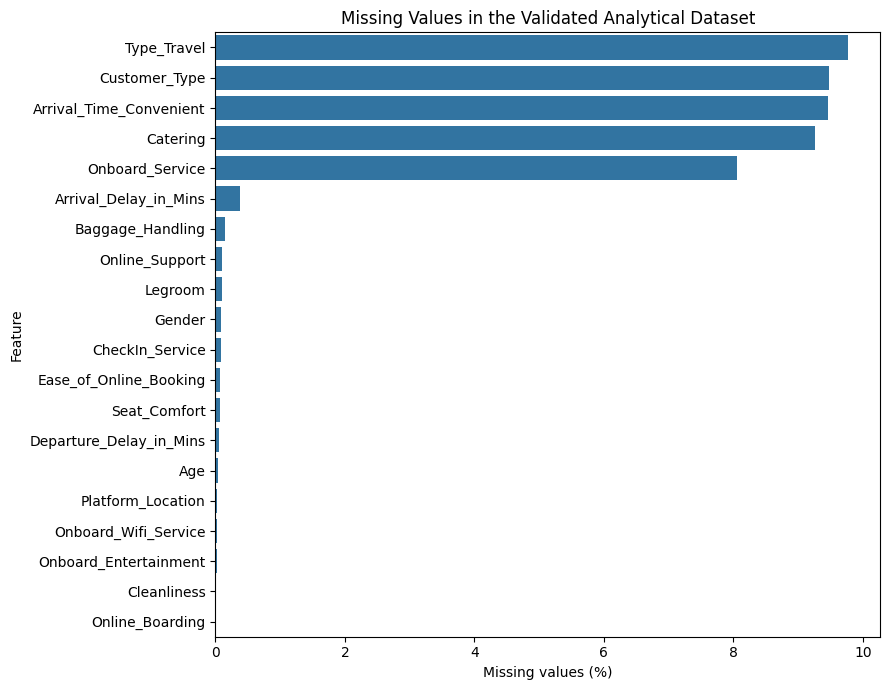

In [ ]:
# Purpose: Summarize missing-value counts and percentages across the merged analytical variables.
missing_overview = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100)
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)
display(missing_overview.round(2))

if len(missing_overview):
    plt.figure(figsize=(9, max(4, .35*len(missing_overview))))
    sns.barplot(data=missing_overview.reset_index(), x='missing_pct', y='index', color='C0')
    plt.xlabel('Missing values (%)'); plt.ylabel('Feature')
    plt.title('Missing Values in the Validated Analytical Dataset')
    plt.tight_layout(); plt.show()

#### **Observation — Missing-Value Overview**

The table and bar plot show that missingness is concentrated in a small subset of variables. `Type_Travel` (9.78%), `Customer_Type` (9.48%), `Arrival_Time_Convenient` (9.46%), `Catering` (9.26%), and `Onboard_Service` (8.05%) contain the largest gaps. Most other incomplete features are below 0.2% missingness.

This pattern argues against a single blanket cleaning rule. The higher-missingness categorical variables deserve explicit missingness analysis, while the sparse gaps in other fields can be handled according to the requirements of each model representation.


### **2.9 Unique Values and Complete Categorical Frequency Tables**


In [ ]:
# Purpose: Display unique values and full categorical frequency tables to understand category coverage.
categorical_cols_overview = df.select_dtypes(include=['object','category']).columns.tolist()

category_summary = pd.DataFrame({
    'column': categorical_cols_overview,
    'unique_non_missing': [df[c].nunique(dropna=True) for c in categorical_cols_overview],
    'missing': [df[c].isna().sum() for c in categorical_cols_overview],
    'most_common': [df[c].value_counts(dropna=False).index[0] for c in categorical_cols_overview],
    'most_common_count': [df[c].value_counts(dropna=False).iloc[0] for c in categorical_cols_overview]
})
display(category_summary)

for col in categorical_cols_overview:
    print(f"\n--- {col} ---")
    counts = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(dropna=False, normalize=True).mul(100).round(2)
    display(pd.DataFrame({'count': counts, 'percent': pct}))

,column,unique_non_missing,missing,most_common,most_common_count
0,Gender,2,77,Female,47815
1,Customer_Type,2,8951,Loyal Customer,69823
2,Type_Travel,2,9226,Business Travel,58617
3,Travel_Class,2,0,Eco,49342
4,Seat_Comfort,6,61,Acceptable,21158
5,Seat_Class,2,0,Green Car,47435
6,Arrival_Time_Convenient,6,8930,Good,19574
7,Catering,6,8741,Acceptable,18468
8,Platform_Location,6,30,Manageable,24173
9,Onboard_Wifi_Service,6,30,Good,22835



--- Gender ---


,count,percent
Gender,,
Female,47815,50.66
Male,46487,49.26
NaN,77,0.08



--- Customer_Type ---


,count,percent
Customer_Type,,
Loyal Customer,69823,73.98
Disloyal Customer,15605,16.53
NaN,8951,9.48


...

,count,percent
CheckIn_Service,,
Good,26502,28.08
Acceptable,25803,27.34
Excellent,19641,20.81
Needs Improvement,11218,11.89
Poor,11137,11.80
NaN,77,0.08
Extremely Poor,1,0.00



--- Cleanliness ---


,count,percent
Cleanliness,,
Good,35427,37.54
Excellent,26053,27.60
Acceptable,17449,18.49
Needs Improvement,9806,10.39
Poor,5633,5.97
NaN,6,0.01
Extremely Poor,5,0.01



--- Online_Boarding ---


,count,percent
Online_Boarding,,
Good,25533,27.05
Acceptable,22475,23.81
Excellent,21742,23.04
Needs Improvement,13451,14.25
Poor,11160,11.82
Extremely Poor,12,0.01
NaN,6,0.01


#### **Observation — Categorical Variables**

The frequency tables show that the nominal and service-feedback variables have manageable category counts, but their prevalence is not uniform.

**Nominal variables**
- **Gender:** Female 50.66%, Male 49.26%, missing 0.08%.
- **Customer_Type:** Loyal Customer 73.98%, Disloyal Customer 16.53%, missing 9.48%.
- **Type_Travel:** Business Travel 62.11%, Personal Travel 28.12%, missing 9.78%.
- **Travel_Class:** Eco 52.28%, Business 47.72%, with no missing values.
- **Seat_Class:** Green Car 50.26%, Ordinary 49.74%, with no missing values.

**Service-feedback variables**
Most rating fields contain six ordered labels from `Extremely Poor` through `Excellent`, although `Baggage_Handling` has five observed non-missing levels in the stored data. Their category frequencies vary considerably: some are concentrated in `Good`/`Excellent`, while others are more evenly distributed. Several service fields also have material missingness, particularly `Arrival_Time_Convenient`, `Catering`, and `Onboard_Service`.

**Modeling implication:** nominal variables should not be given arbitrary numerical order, while the ordered service scales can be represented ordinally when the model or analysis benefits from that structure.


### **2.10 Descriptive Statistics Before Cleaning**
The original numerical distributions are documented before capping, imputation, scaling, or feature engineering. This creates a baseline for later comparisons.


In [ ]:
# Purpose: Generate descriptive statistics for numerical variables before cleaning decisions are applied.
numeric_overview = df.select_dtypes(include=np.number).columns.tolist()
descriptive = df[numeric_overview].describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]).T
descriptive['missing'] = df[numeric_overview].isna().sum()
descriptive['missing_pct'] = df[numeric_overview].isna().mean().mul(100)
descriptive['skewness'] = df[numeric_overview].skew(numeric_only=True)
descriptive['kurtosis'] = df[numeric_overview].kurt(numeric_only=True)
display(descriptive.round(3))

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,missing,missing_pct,skewness,kurtosis
Age,94346.0,39.420,15.117,7.0,8.0,15.0,20.0,27.0,40.0,51.0,59.0,64.0,70.00,85.0,33,0.035,-0.002,-0.713
Travel_Distance,94379.0,1978.888,1027.961,50.0,96.0,339.0,539.0,1359.0,1923.0,2538.0,3396.0,3833.0,4822.22,6951.0,0,0.000,0.473,0.387
Departure_Delay_in_Mins,94322.0,14.647,38.139,0.0,0.0,0.0,0.0,0.0,0.0,12.0,44.0,77.0,179.00,1592.0,57,0.060,7.157,114.768
Arrival_Delay_in_Mins,94022.0,15.005,38.439,0.0,0.0,0.0,0.0,0.0,0.0,13.0,44.0,78.0,180.79,1584.0,357,0.378,6.980,108.421
Overall_Experience,94379.0,0.547,0.498,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.00,1.0,0,0.000,-0.187,-1.965


#### **Observation — Descriptive Statistics**

**Age:** The mean age is around 39.4, with a range from 7 to 85. The standard deviation (15.1) indicates a moderate spread. The skewness (-0.002) suggests a nearly symmetric distribution.

**Travel_Distance:** The mean travel distance is ~1979 km, ranging from 50 km to 6951 km. It shows a slight positive skewness (0.473), with a large standard deviation (1028), indicating variability and potentially some longer-distance outliers.

**Departure_Delay_in_Mins & Arrival_Delay_in_Mins:** Both delay variables have a mean around 14-15 minutes, but a median of 0. This indicates a large number of passengers experience no delay, and when delays occur, they can be substantial, leading to very high positive skewness (7.16 and 6.98 respectively) and large maximum values (1592 and 1584 minutes). These variables are highly right-skewed with long tails.

**Overall_Experience:** The target variable has a mean of 0.547, indicating that approximately 54.7% of passengers had a positive experience. Its standard deviation is 0.498, and it has no missing values. The negative skewness (-0.187) is expected for a binary variable with a slight imbalance towards the positive class.

These statistics confirm the skewed nature of delay and distance variables, which will inform outlier treatment and transformation decisions, while age appears well-behaved.

### **2.11 Target Distribution**
The binary target is inspected before modeling because class prevalence determines whether accuracy is informative and whether class-balancing techniques warrant investigation.


,count,percent
Overall_Experience,,
0,42786,45.33
1,51593,54.67


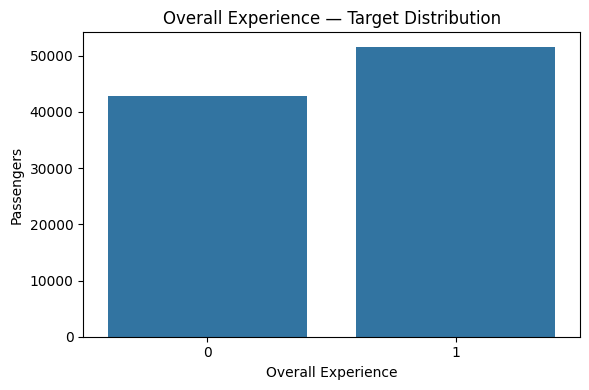

In [ ]:
# Purpose: Quantify and visualize the target-class distribution before modeling.
target_counts = df['Overall_Experience'].value_counts().sort_index()
target_pct = df['Overall_Experience'].value_counts(normalize=True).sort_index().mul(100)
target_summary = pd.DataFrame({'count': target_counts, 'percent': target_pct})
display(target_summary.round(2))

fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x='Overall_Experience', ax=ax, color='C0')
ax.set_title('Overall Experience — Target Distribution')
ax.set_xlabel('Overall Experience'); ax.set_ylabel('Passengers')
plt.tight_layout(); plt.show()

#### **Observation — Target Distribution**

The target variable `Overall_Experience` is binary, with 0 representing a negative experience and 1 representing a positive experience.

**Counts:** There are 42,786 negative experiences and 51,593 positive experiences.
**Proportions:** The positive class (`1`) accounts for approximately 54.67% of the data, and the negative class (`0`) accounts for 45.33%.

**Imbalance:** The ratio of the majority class to the minority class is approximately 1.206:1. This indicates a relatively balanced target distribution, suggesting that aggressive resampling techniques (like SMOTE) may not be necessary, but ROC-AUC remains a suitable evaluation metric to account for any slight imbalance.

### **Summary of Data Import and Validation**
The data have now been inspected twice: once as independent sources and again after integration. This prevents the project from treating the merge as an unexplained preprocessing shortcut.

**What we established**

- the structure and quality of each source table before any transformation;
- the common fields and evidence supporting the selected merge key;
- merge cardinality and ID overlap;
- explicit one-to-one merge validation;
- post-merge row, key, duplicate, missingness, schema, and descriptive checks;
- the complete baseline structure of the analytical dataset.

### **Next Step**
Perform a broad visual EDA. Every substantive statement about skewness, class relationships, service ratings, delays, distance, or associations should be supported by a table, statistic, visualization, or combination of evidence.


## **3. Exploratory Data Analysis (EDA)**

### **Question**
What distributions, relationships, group differences, and dependencies exist in the validated analytical dataset?

### **Why This Matters**
EDA should produce evidence that informs preprocessing and modeling decisions. The goal is not to create graphs for decoration; each visualization should answer a specific analytical question and lead to an observation, interpretation, or decision.


### **3.1 Numerical Distributions: Histograms, KDE, Boxplots, and Skewness**

#### **Question**
Which numerical variables are approximately symmetric, which are skewed, and where do extreme observations occur?

#### **Method**
For every numerical predictor we combine descriptive statistics with histograms/KDE and boxplots. This directly tests claims such as "delay variables have long right tails" rather than asserting them without evidence.


,mean,median,std,min,q1,q3,p95,p99,max,skewness
Departure_Delay_in_Mins,14.647,0.0,38.139,0.0,0.0,12.0,77.0,179.00,1592.0,7.157
Arrival_Delay_in_Mins,15.005,0.0,38.439,0.0,0.0,13.0,78.0,180.79,1584.0,6.980
Travel_Distance,1978.888,1923.0,1027.961,50.0,1359.0,2538.0,3833.0,4822.22,6951.0,0.473
Age,39.420,40.0,15.117,7.0,27.0,51.0,64.0,70.00,85.0,-0.002


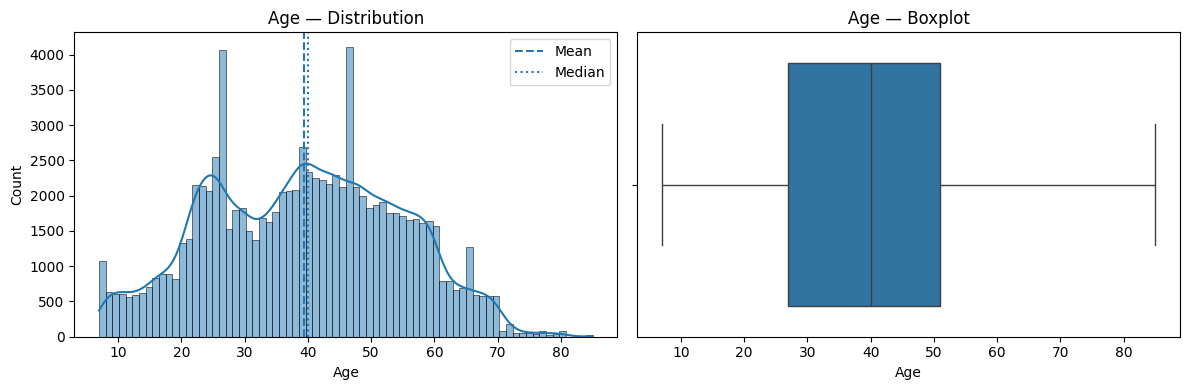

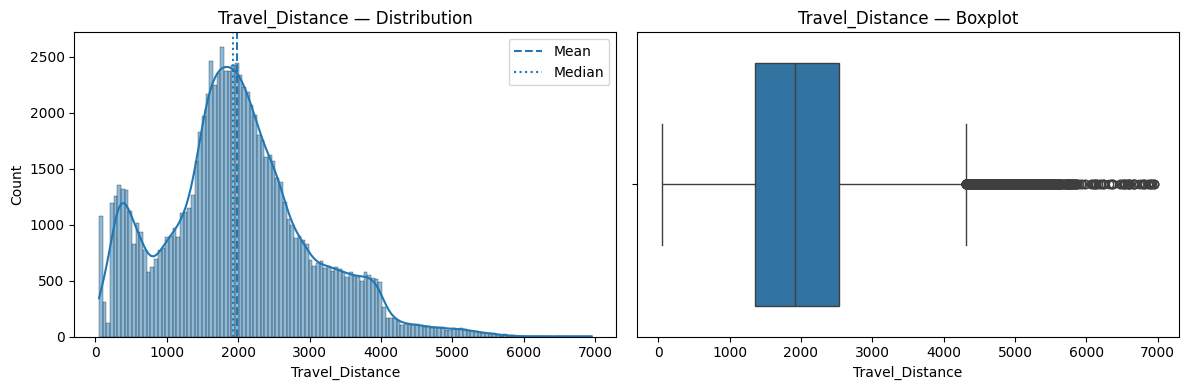

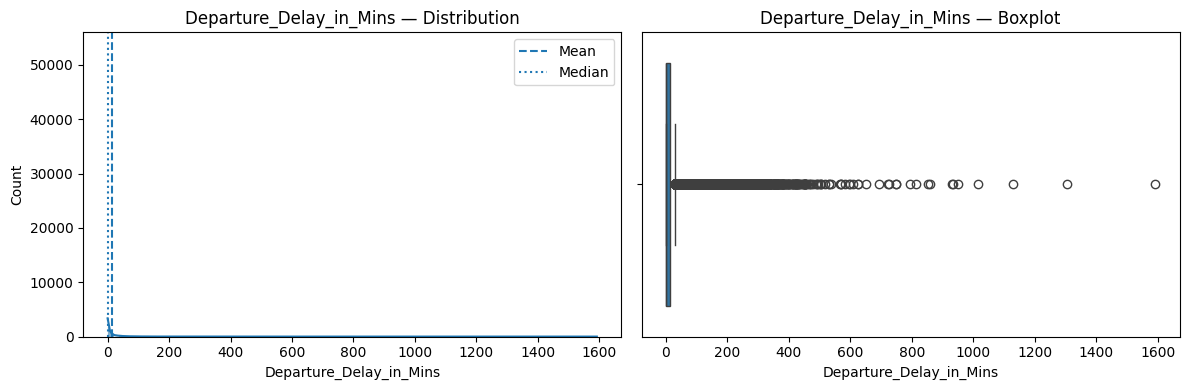

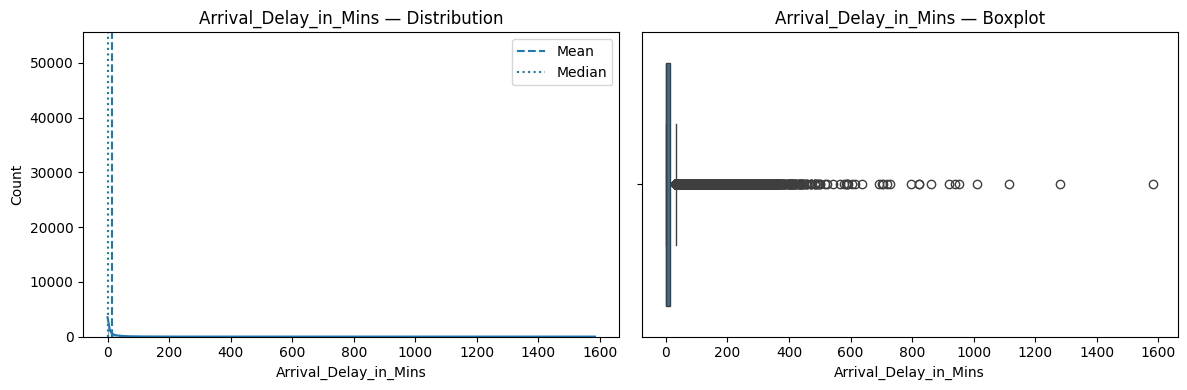

In [ ]:
# Purpose: Quantify distribution shape and visualize numerical predictors with histograms/KDEs and boxplots.
num_cols_eda = [c for c in df.select_dtypes(include=np.number).columns if c != 'Overall_Experience']

shape_stats = pd.DataFrame({
    'mean': df[num_cols_eda].mean(),
    'median': df[num_cols_eda].median(),
    'std': df[num_cols_eda].std(),
    'min': df[num_cols_eda].min(),
    'q1': df[num_cols_eda].quantile(.25),
    'q3': df[num_cols_eda].quantile(.75),
    'p95': df[num_cols_eda].quantile(.95),
    'p99': df[num_cols_eda].quantile(.99),
    'max': df[num_cols_eda].max(),
    'skewness': df[num_cols_eda].skew()
}).sort_values('skewness', ascending=False)
display(shape_stats.round(3))

for col in num_cols_eda:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(df[col], kde=True, ax=axes[0], color='C0')
    axes[0].axvline(df[col].mean(), linestyle='--', label='Mean')
    axes[0].axvline(df[col].median(), linestyle=':', label='Median')
    axes[0].set_title(f'{col} — Distribution')
    axes[0].legend()
    sns.boxplot(x=df[col], ax=axes[1], color='C0')
    axes[1].set_title(f'{col} — Boxplot')
    plt.tight_layout(); plt.show()

#### **Observation — Numerical Distributions**

**Age:** Appears to be a roughly symmetric distribution, centered around the mean (39.4) and median (40.0), with a low skewness value (-0.002).

**Travel_Distance:** Shows a slight positive skew (0.473), with the mean (1978.89) slightly higher than the median (1923.0). The long right tail is evident in the histogram and boxplot, indicating some longer-distance trips.

**Departure_Delay_in_Mins & Arrival_Delay_in_Mins:** Both delay variables are highly right-skewed (7.157 and 6.980 respectively). Their means (14.65 and 15.01) are significantly higher than their medians (0.0), indicating a large number of zero delays and a long tail of positive delays with extreme values. This suggests that while most passengers experience no delay, some experience substantial delays.

#### **Observation and Interpretation — Numerical Distributions**
Use the numerical table and visualizations together. A long right tail is supported when the mean exceeds the median, upper percentiles are far below the maximum, skewness is strongly positive, and the histogram/boxplot visibly shows a stretched upper tail.

**Decision rule:** do not transform or cap a variable merely because a boxplot displays points beyond the whiskers. These points may be legitimate observations. The dedicated outlier section will quantify candidate rules and evaluate the impact before treatment.

#### **Next Step**
Visualize the target-conditioned numerical distributions to determine whether the classes differ in location, spread, or shape.

### **3.2 Numerical Variables by Overall Experience**


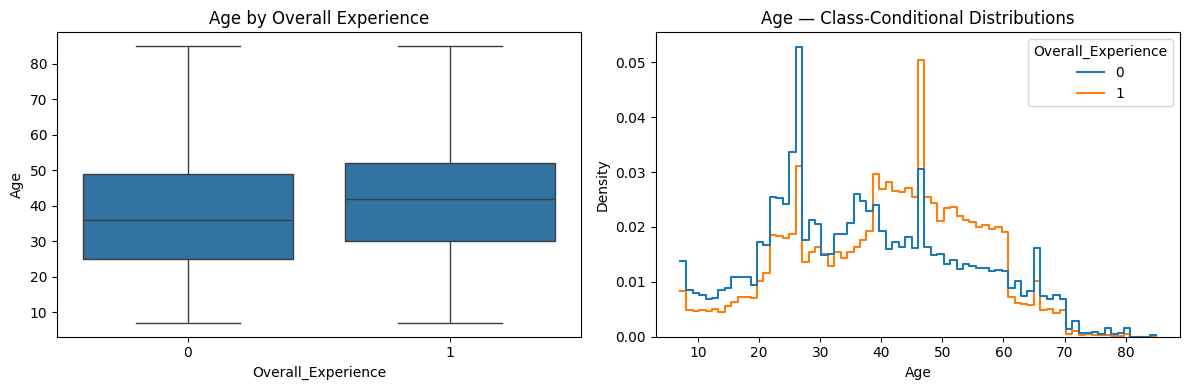

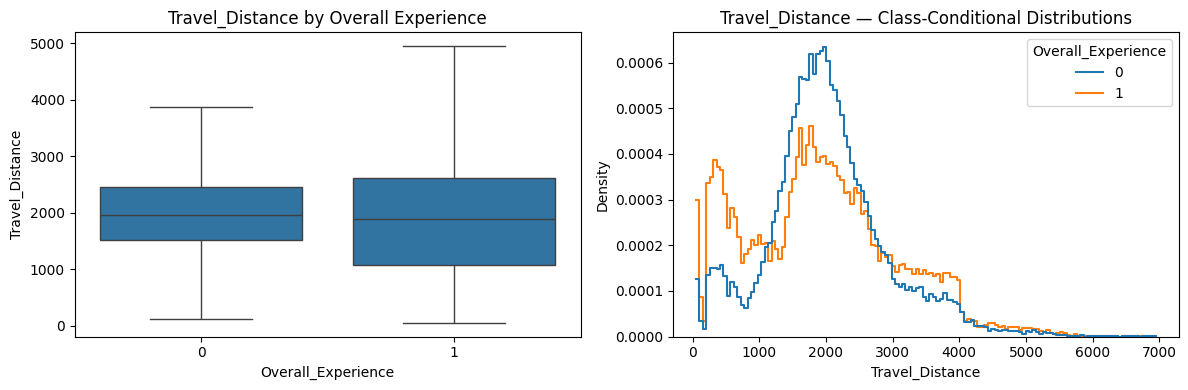

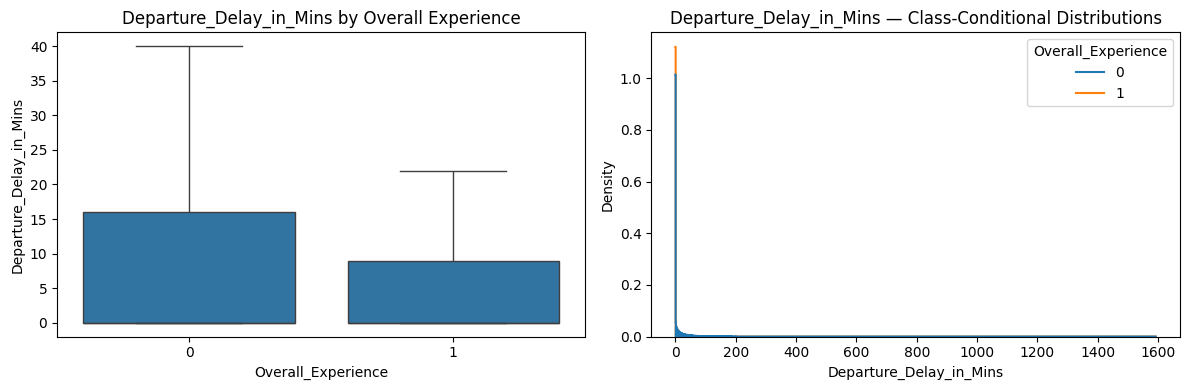

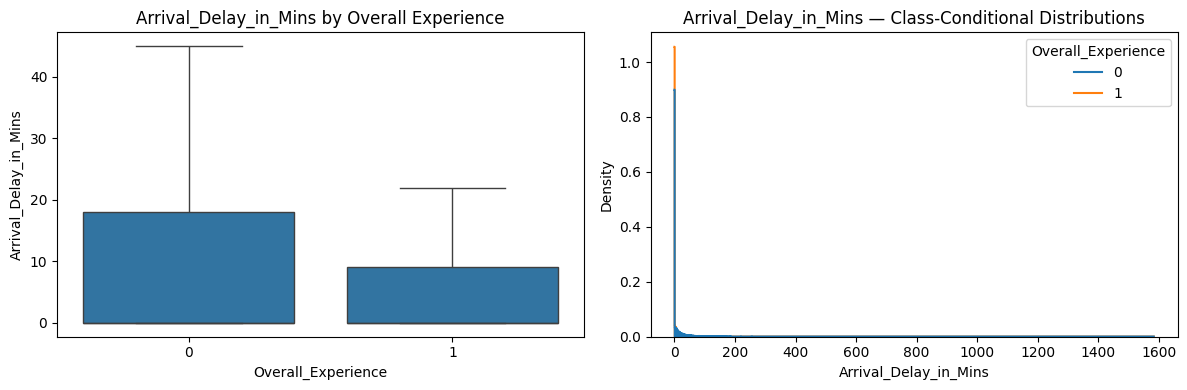

Age               Travel_Distance                   \
                     mean median    std            mean  median      std   
Overall_Experience                                                         
0                   37.49   36.0  15.90         2025.83  1953.5   890.51   
1                   41.02   42.0  14.24         1939.96  1882.0  1127.86   

                   Departure_Delay_in_Mins                \
                                      mean median    std   
Overall_Experience                                         
0                                    17.74    0.0  43.31   
1                                    12.08    0.0  33.03   

                   Arrival_Delay_in_Mins                
                                    mean median    std  
Overall_Experience                                      
0                                  18.39    0.0  43.53  
1                                  12.20    0.0  33.38

In [ ]:
# Purpose: Compare numerical feature distributions across the two target classes.
for col in num_cols_eda:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.boxplot(data=df, x='Overall_Experience', y=col, showfliers=False, ax=axes[0], color='C0')
    axes[0].set_title(f'{col} by Overall Experience')
    sns.histplot(data=df, x=col, hue='Overall_Experience', stat='density', common_norm=False,
                 element='step', fill=False, ax=axes[1])
    axes[1].set_title(f'{col} — Class-Conditional Distributions')
    plt.tight_layout(); plt.show()

group_summary = df.groupby('Overall_Experience')[num_cols_eda].agg(['mean','median','std']).round(2)
display(group_summary)

#### **Observation — Numerical Variables by Overall Experience**

The target-conditioned summary shows several measurable differences, but the distributions still overlap.

- **Age:** passengers with a positive experience have a higher mean age (**41.02**) than passengers with a negative experience (**37.49**).
- **Travel_Distance:** the positive class has a slightly lower mean travel distance (**1939.96**) than the negative class (**2025.83**).
- **Departure delay:** the negative class averages **17.74 minutes**, compared with **12.08 minutes** for the positive class.
- **Arrival delay:** the negative class averages **18.39 minutes**, compared with **12.20 minutes** for the positive class.

The delay variables therefore show a clear class-level shift in mean values, but their shared median of zero and broad overlap indicate that delay alone does not determine the target.


### **3.3 Categorical Distributions**
Raw counts reveal prevalence and sparse categories. Percentage labels make plots easier to compare when category sizes differ substantially.


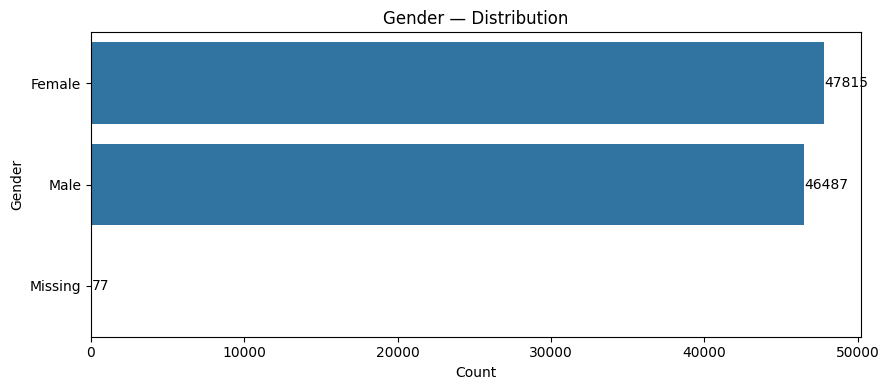

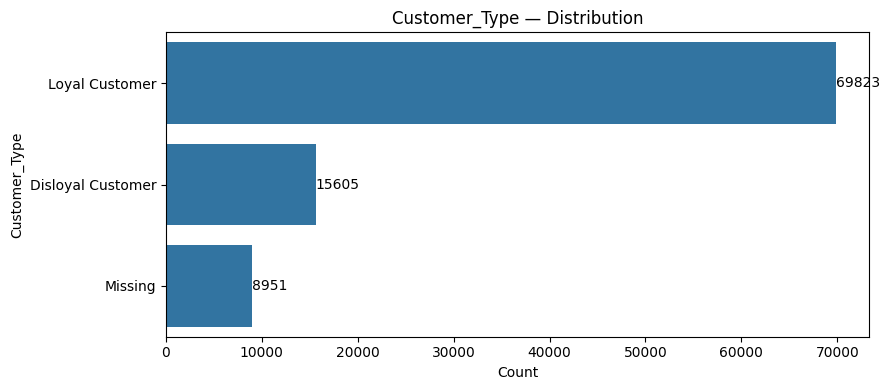

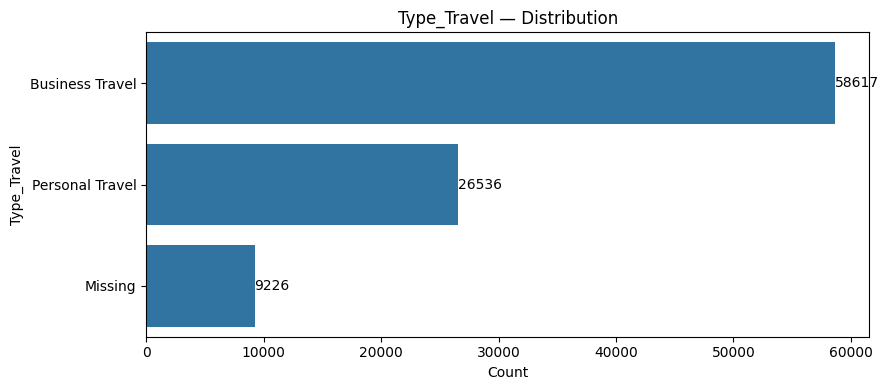

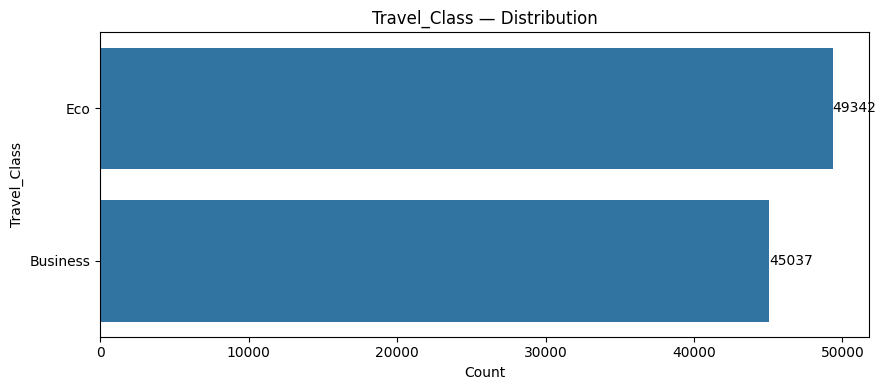

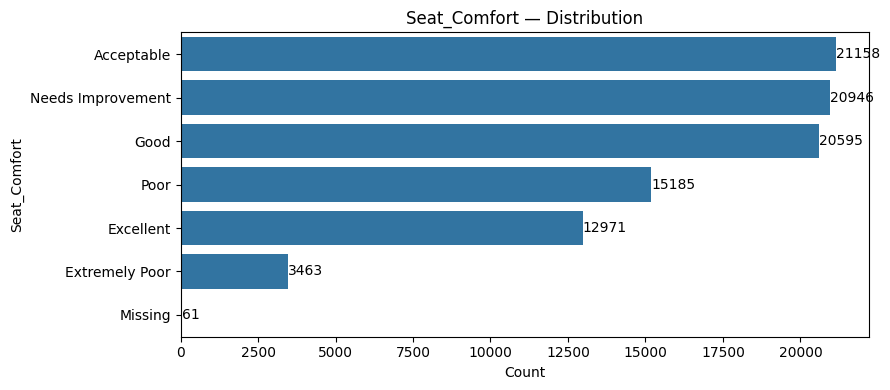

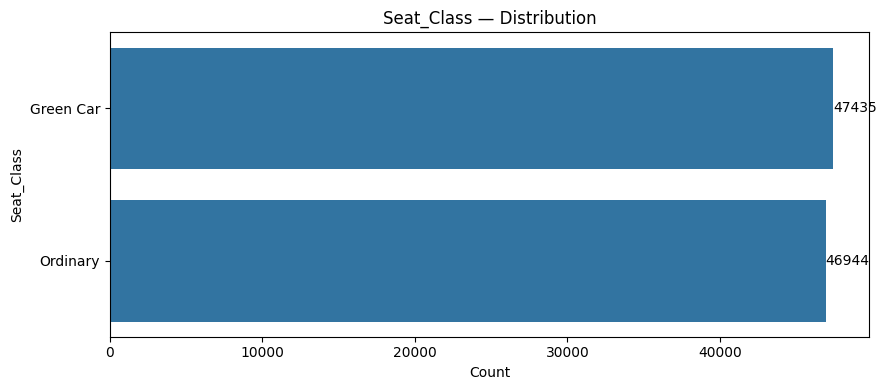

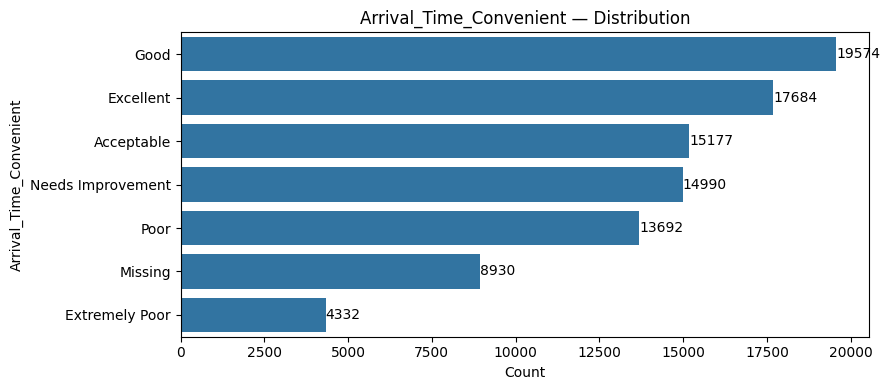

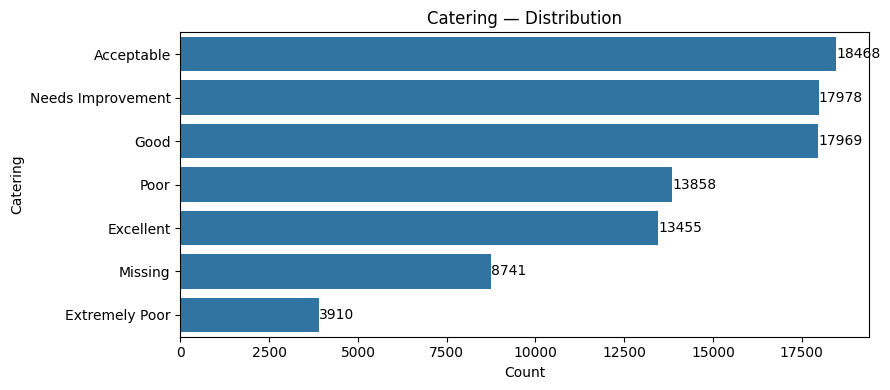

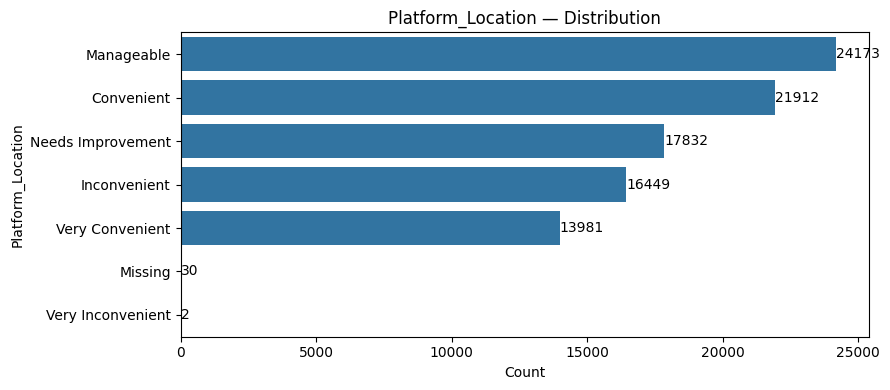

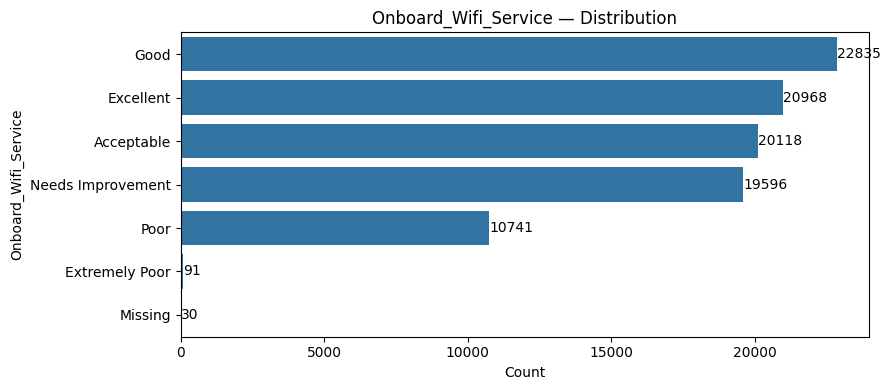

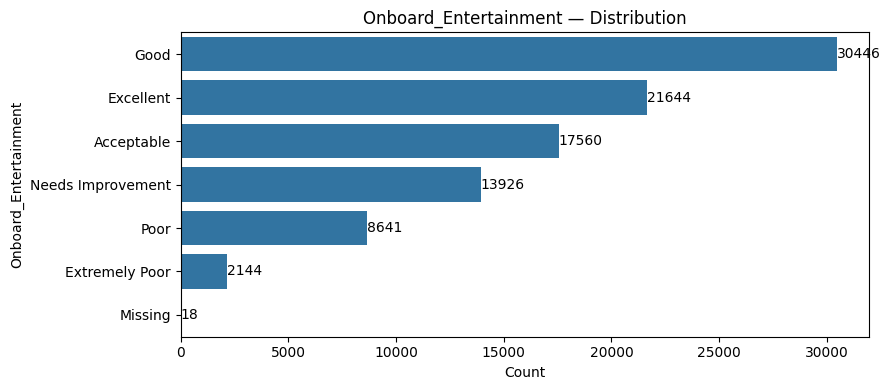

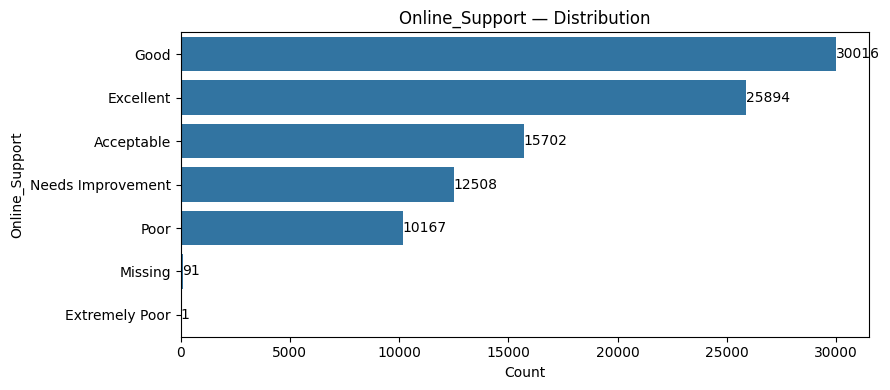

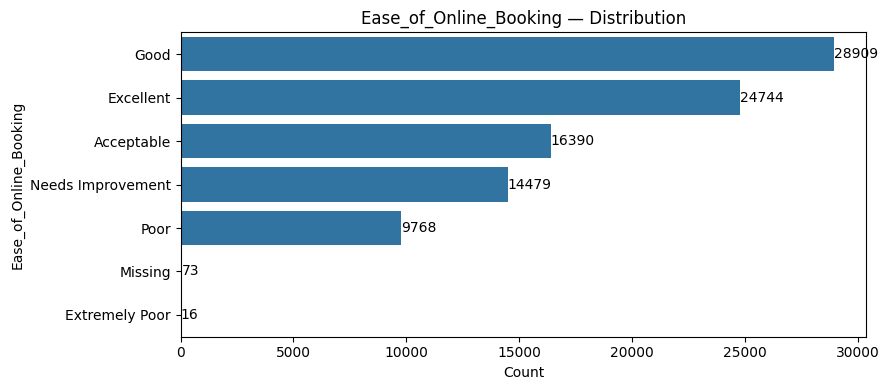

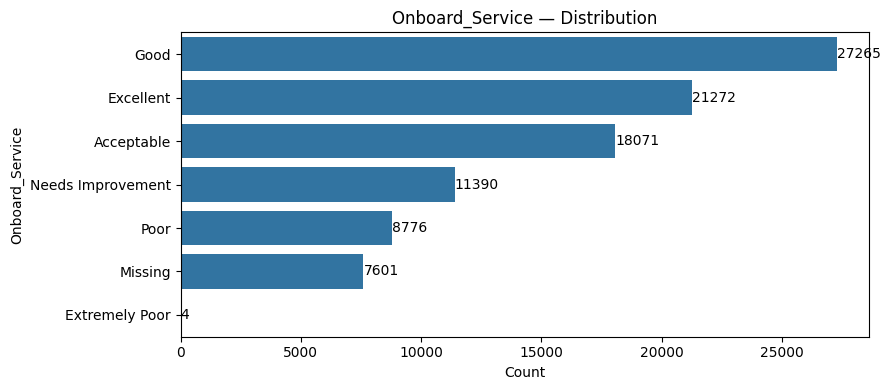

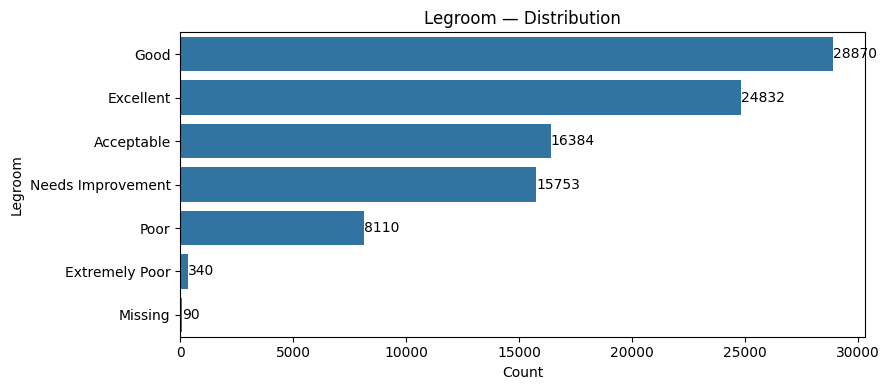

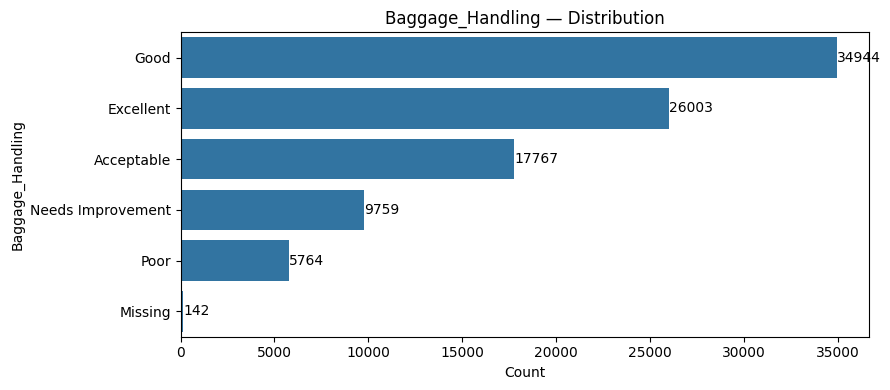

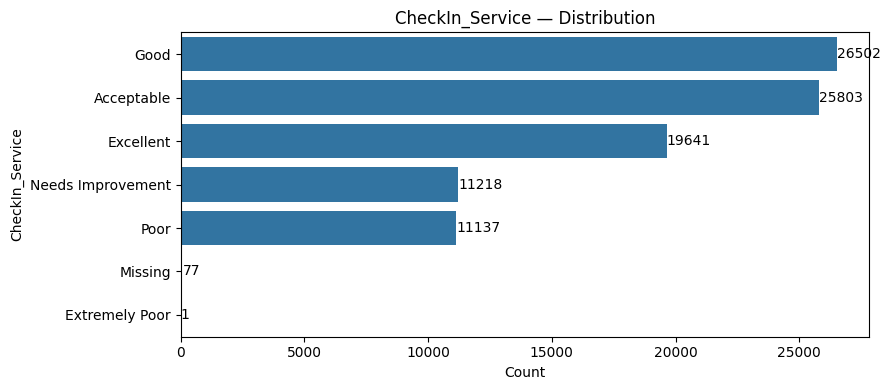

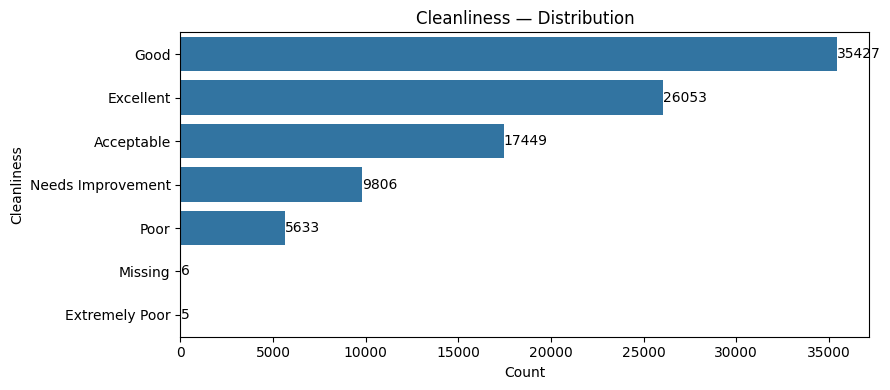

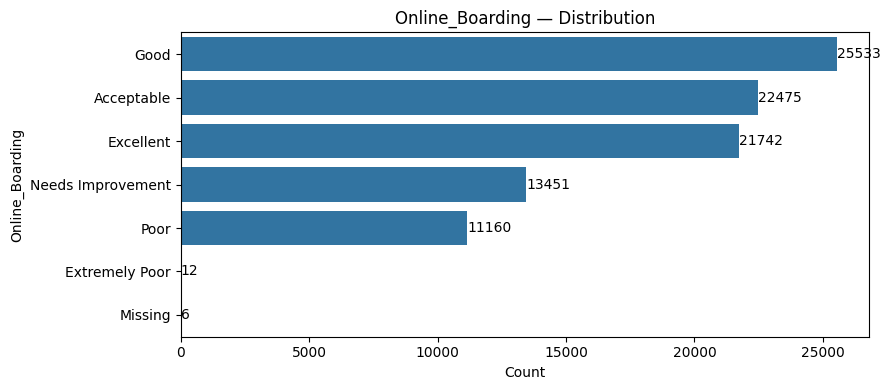

In [ ]:
# Purpose: Visualize prevalence for categorical predictors to identify dominant, rare, or missing categories.
cat_cols_eda = df.select_dtypes(include=['object','category']).columns.tolist()
for col in cat_cols_eda:
    counts = df[col].fillna('Missing').value_counts(dropna=False)
    pct = counts / counts.sum() * 100
    plot_df = pd.DataFrame({'category': counts.index.astype(str), 'count': counts.values, 'percent': pct.values})
    plt.figure(figsize=(9, max(4, .35*len(plot_df))))
    ax = sns.barplot(data=plot_df, x='count', y='category', color='C0')
    ax.set_title(f'{col} — Distribution')
    ax.set_xlabel('Count'); ax.set_ylabel(col)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f')
    plt.tight_layout(); plt.show()

#### **Observation — Categorical Distributions**

The categorical prevalence plots reinforce the frequency-table findings:

- **Gender** is almost evenly split between Female and Male, with only 0.08% missingness.
- **Customer_Type** is dominated by Loyal Customers (73.98%), while Disloyal Customers represent 16.53% and 9.48% is missing.
- **Type_Travel** is dominated by Business Travel (62.11%), followed by Personal Travel (28.12%), with 9.78% missing.
- **Travel_Class** is relatively balanced between Eco (52.28%) and Business (47.72%).
- **Seat_Class** is almost perfectly balanced between Green Car (50.26%) and Ordinary (49.74%).
- **Service-feedback ratings** differ by variable rather than following one universal shape. Several are concentrated in `Good`/`Excellent`, whereas `Seat_Comfort`, `Catering`, and `Arrival_Time_Convenient` are more broadly distributed.

These plots describe prevalence only; target relationships are examined separately in the next section.


### **3.4 Passenger and Travel Segments vs. Overall Experience**
For nominal groups, the most useful comparison is often the **positive-experience rate**, not just the number of passengers in each category.


,_segment,count,mean,positive_rate
0,Female,47815,0.65,65.21
2,Missing,77,0.49,49.35
1,Male,46487,0.44,43.83


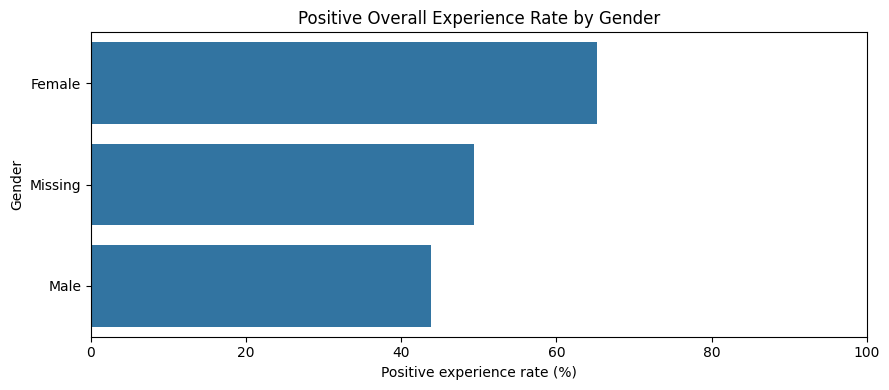

,_segment,count,mean,positive_rate
1,Loyal Customer,69823,0.62,61.63
2,Missing,8951,0.54,53.94
0,Disloyal Customer,15605,0.24,23.94


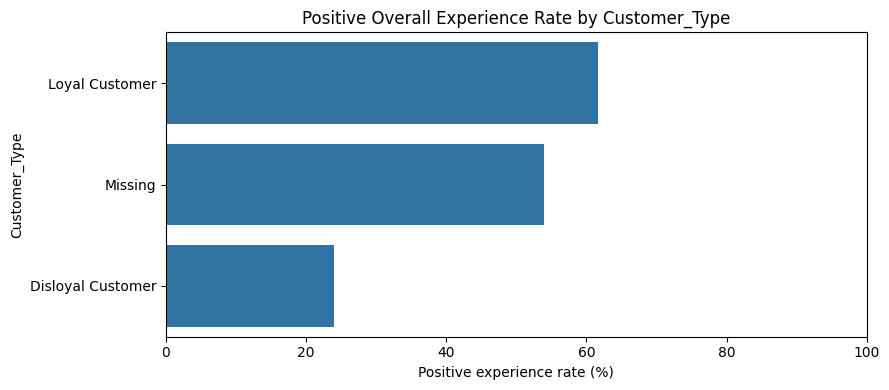

,_segment,count,mean,positive_rate
0,Business Travel,58617,0.58,58.30
1,Missing,9226,0.55,54.63
2,Personal Travel,26536,0.47,46.64


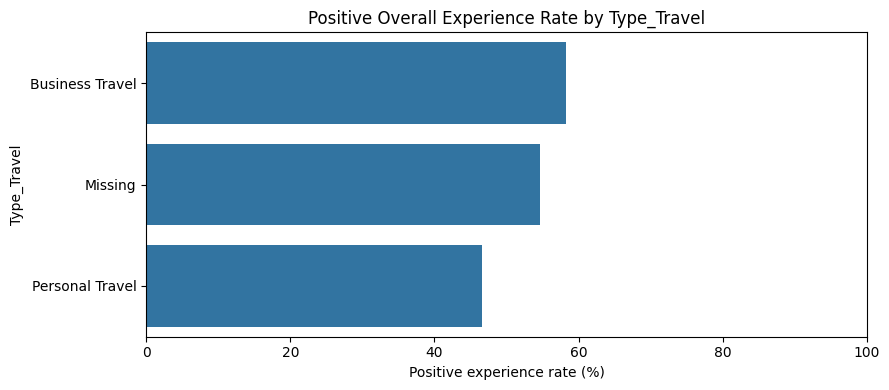

,_segment,count,mean,positive_rate
0,Business,45037,0.71,70.82
1,Eco,49342,0.40,39.92


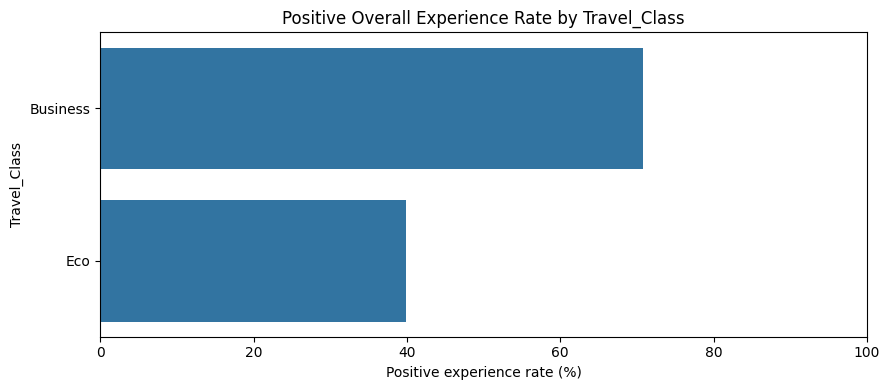

,_segment,count,mean,positive_rate
0,Green Car,47435,0.55,54.81
1,Ordinary,46944,0.55,54.52


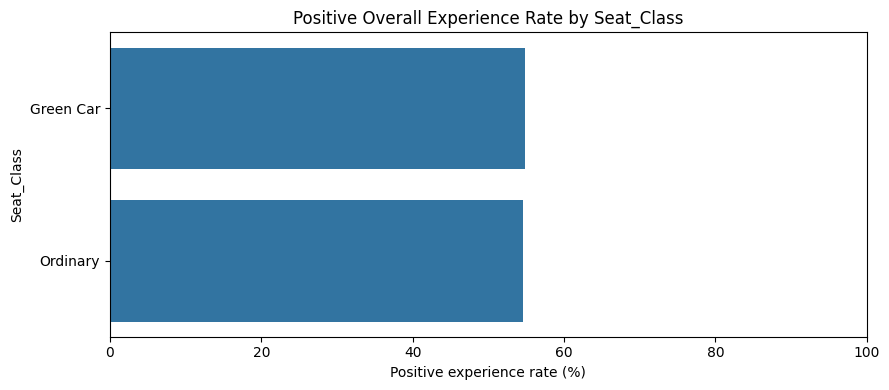

In [ ]:
# Purpose: Compare passenger and travel segments with target rates using grouped visual summaries.
segment_cols = [c for c in ['Gender','Customer_Type','Type_Travel','Travel_Class','Seat_Class'] if c in df.columns]
for col in segment_cols:
    tmp = df.assign(_segment=df[col].fillna('Missing')).groupby('_segment')['Overall_Experience'].agg(['count','mean']).reset_index()
    tmp['positive_rate'] = tmp['mean'] * 100
    display(tmp.sort_values('positive_rate', ascending=False).round(2))
    plt.figure(figsize=(9, max(4, .45*len(tmp))))
    sns.barplot(data=tmp.sort_values('positive_rate', ascending=False), x='positive_rate', y='_segment', color='C0')
    plt.xlabel('Positive experience rate (%)'); plt.ylabel(col)
    plt.title(f'Positive Overall Experience Rate by {col}')
    plt.xlim(0,100); plt.tight_layout(); plt.show()

#### **Observation — Passenger and Travel Segments vs. Overall Experience**

The positive-experience rate differs substantially for several passenger and travel segments in the stored output:

- **Gender:** Female passengers have a positive-experience rate of **65.21%**, versus **43.83%** for Male passengers. The small missing-gender group is 49.35%.
- **Customer_Type:** Loyal Customers show **61.63%** positive experience, compared with **23.94%** for Disloyal Customers; missing `Customer_Type` records are at 53.94%.
- **Type_Travel:** Business Travel is associated with **58.30%** positive experience, versus **46.64%** for Personal Travel; missing values are at 54.63%.
- **Travel_Class:** Business class shows **70.82%** positive experience, versus **39.92%** for Eco.
- **Seat_Class:** Green Car (**54.81%**) and Ordinary (**54.52%**) are nearly identical.

**Interpretation:** `Gender`, `Customer_Type`, and `Travel_Class` show strong univariate target separation in this dataset, while `Seat_Class` shows essentially none. These are predictive associations, not causal effects.


### **3.5 Age and Travel Distance Segmentation**
Continuous variables can hide nonlinear patterns. Binning is used here only for descriptive visualization; the original continuous variables remain available for modeling.


,bin,count,mean,positive_rate
0,"(6.999, 20.0]",10170,0.43,43.11
1,"(20.0, 25.0]",10291,0.45,45.14
2,"(25.0, 30.0]",9221,0.45,45.11
3,"(30.0, 36.0]",10012,0.49,48.54
4,"(36.0, 40.0]",9162,0.55,55.38
5,"(40.0, 44.0]",8925,0.66,65.88
6,"(44.0, 48.0]",8354,0.66,65.94
7,"(48.0, 53.0]",9353,0.67,66.55
8,"(53.0, 59.0]",10037,0.66,66.21
9,"(59.0, 85.0]",8821,0.48,47.56


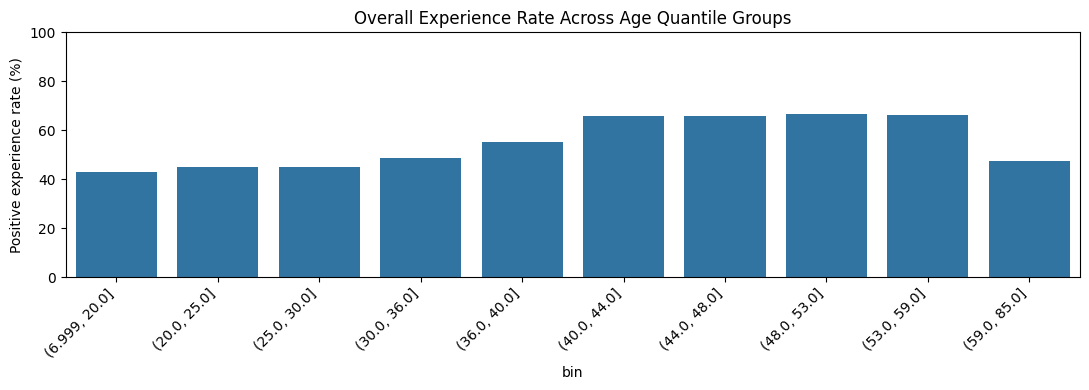

,bin,count,mean,positive_rate
0,"(49.999, 539.0]",9442,0.75,74.54
1,"(539.0, 1133.0]",9436,0.70,69.78
2,"(1133.0, 1508.0]",9466,0.45,44.91
3,"(1508.0, 1724.0]",9423,0.47,46.93
4,"(1724.0, 1923.0]",9454,0.46,45.97
5,"(1923.0, 2131.0]",9441,0.44,43.85
6,"(2131.0, 2384.0]",9441,0.46,46.13
7,"(2384.0, 2733.0]",9413,0.52,51.84
8,"(2733.0, 3396.0]",9436,0.58,58.22
9,"(3396.0, 6951.0]",9427,0.65,64.53


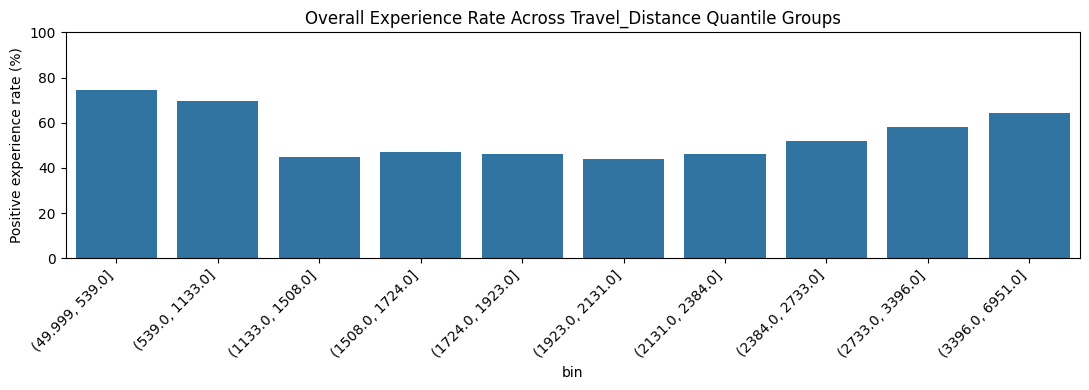

In [ ]:
# Purpose: Bin age and travel distance to reveal nonlinear target-rate patterns across interpretable ranges.
for col, bins in [('Age', 10), ('Travel_Distance', 10)]:
    if col not in df.columns: continue
    temp = df[[col,'Overall_Experience']].dropna().copy()
    temp['bin'] = pd.qcut(temp[col], q=min(bins, temp[col].nunique()), duplicates='drop')
    rates = temp.groupby('bin', observed=True)['Overall_Experience'].agg(['count','mean']).reset_index()
    rates['positive_rate'] = rates['mean']*100
    display(rates.round(2))
    plt.figure(figsize=(11,4))
    sns.barplot(data=rates, x='bin', y='positive_rate', color='C0')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0,100); plt.ylabel('Positive experience rate (%)')
    plt.title(f'Overall Experience Rate Across {col} Quantile Groups')
    plt.tight_layout(); plt.show()

#### **Observation — Age and Travel Distance Segmentation**

**Age:** the positive-experience rate rises across the middle age bins rather than following the previously described U-shape. It is about **43–45%** through age 30, increases to roughly **66%** across the 40–59 range, and then falls to **47.56%** in the 59–85 bin. The pattern is therefore nonlinear and non-monotonic.

**Travel_Distance:** the relationship is also nonlinear. The shortest-distance bin (50–539) has the highest positive rate at **74.54%**, rates fall below 50% across much of the middle-distance range, reach a low of **43.85%** around 1923–2131, and then rise again to **64.53%** in the longest-distance bin (3396–6951).

**Interpretation:** both variables contain structure that a single linear effect would summarize poorly. The bins are descriptive only; modeling retains the continuous information.


### **3.6 Delay Analysis**

#### **Question**
How are departure and arrival delays distributed, how strongly are they related, and how do delays differ by passenger experience?

#### **Why This Matters**
Operational delays are expected to be related to each other and may contain extreme but legitimate values. They therefore deserve a focused analysis before any outlier treatment or feature engineering.


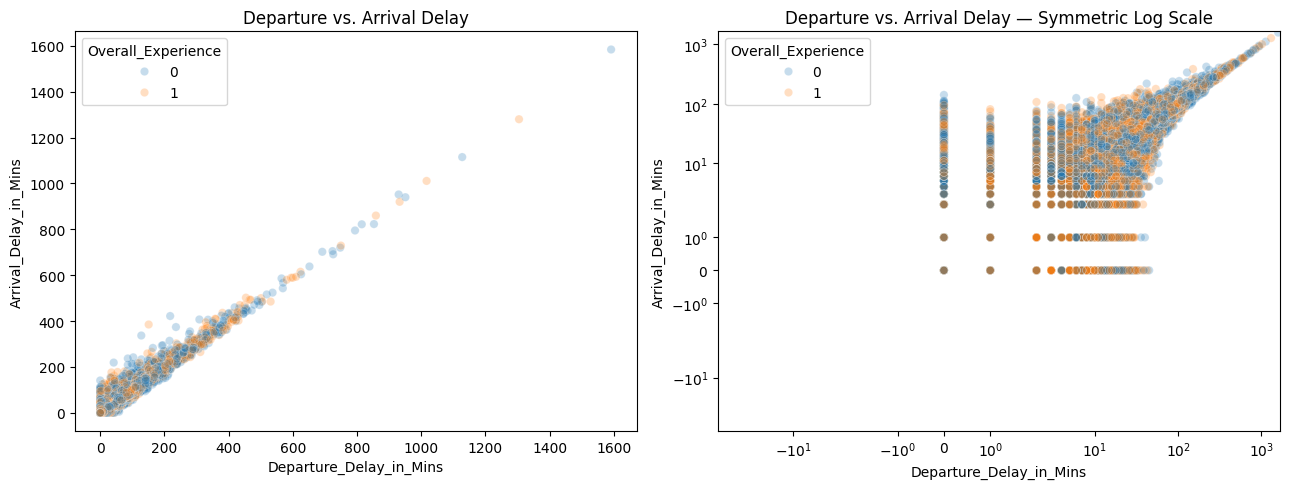

Pearson correlation: 0.9655
Spearman correlation: 0.7377


In [ ]:
# Purpose: Visualize and quantify departure/arrival delay behavior and their relationship with passenger experience.
delay_cols = [c for c in ['Departure_Delay_in_Mins','Arrival_Delay_in_Mins'] if c in df.columns]
if len(delay_cols) == 2:
    dep, arr = delay_cols
    fig, axes = plt.subplots(1,2,figsize=(13,5))
    sns.scatterplot(data=df, x=dep, y=arr, hue='Overall_Experience', alpha=.25, ax=axes[0])
    axes[0].set_title('Departure vs. Arrival Delay')
    sns.scatterplot(data=df, x=dep, y=arr, hue='Overall_Experience', alpha=.25, ax=axes[1])
    axes[1].set_xscale('symlog'); axes[1].set_yscale('symlog')
    axes[1].set_title('Departure vs. Arrival Delay — Symmetric Log Scale')
    plt.tight_layout(); plt.show()

    delay_corr = df[[dep,arr]].corr(method='pearson').iloc[0,1]
    delay_spearman = df[[dep,arr]].corr(method='spearman').iloc[0,1]
    print(f'Pearson correlation: {delay_corr:.4f}')
    print(f'Spearman correlation: {delay_spearman:.4f}')

#### **Observation — Delay Analysis**

The scatter plots show a strong positive correlation between `Departure_Delay_in_Mins` and `Arrival_Delay_in_Mins`. When delays occur, they are generally reflected in both departure and arrival, forming a diagonal pattern.

*   **Correlation:** Pearson correlation is very high at **0.9655**, indicating a strong linear relationship. Spearman correlation is also strong at **0.7377**, reflecting a strong monotonic relationship even with the skewed distributions.
*   **Impact on Experience:** The hue for `Overall_Experience` in the scatter plots suggests that passengers with longer delays (both departure and arrival) are more likely to have a negative overall experience (blue points).
*   **Scale:** The symmetric log-scale plot helps to visualize the spread of delays for both short and long durations, showing that most points cluster near zero delays but extend significantly outwards.

### **3.7 Service Feedback Distributions and Target Relationships**
Ordinal feedback variables are visualized both as category distributions and as positive-experience rates across their ordered response levels.


,Extremely Poor,Poor,Needs Improvement,Acceptable,Good,Excellent
Seat_Comfort,99.8,45.1,35.7,35.4,65.1,99.3
Arrival_Time_Convenient,54.3,58.8,53.6,53.5,52.5,55.5
Catering,77.5,50.8,43.1,42.7,58.8,78.1
Onboard_Wifi_Service,38.5,26.4,50.2,51.0,63.9,66.9
Onboard_Entertainment,65.5,21.2,16.8,19.8,71.9,95.3
Online_Support,0.0,29.1,29.7,28.0,68.1,77.3
Ease_of_Online_Booking,0.0,19.2,28.5,35.6,71.9,76.4
Onboard_Service,0.0,26.8,33.7,40.7,64.7,76.3
Legroom,68.8,28.8,37.7,37.0,67.1,70.8
Baggage_Handling,NaN,42.6,39.8,31.3,58.8,73.3


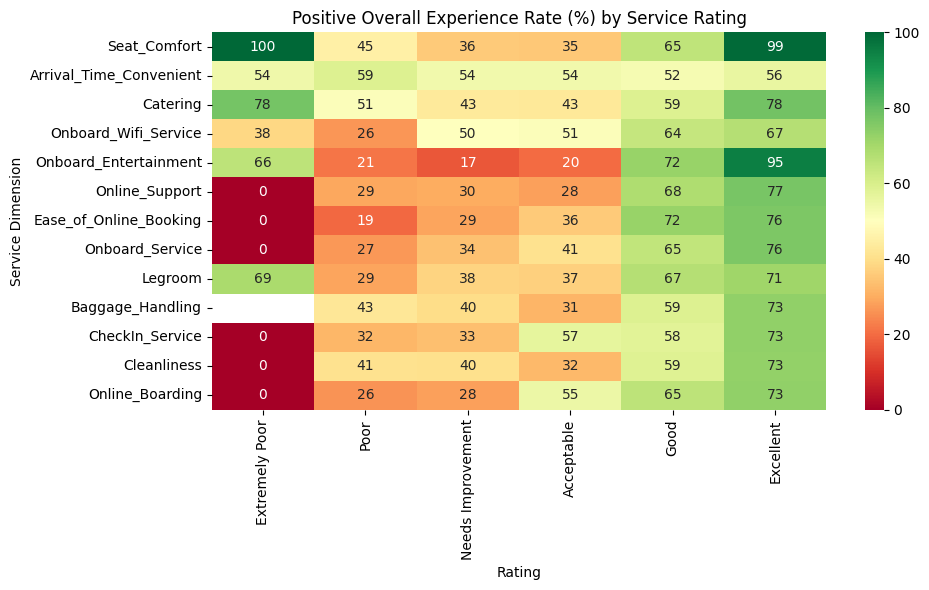

In [ ]:
# Purpose: Visualize ordered service-feedback distributions and their relationship with the target.
likert_order_eda = ['Extremely Poor','Poor','Needs Improvement','Acceptable','Good','Excellent']
feedback_cols_eda = [c for c in ['Seat_Comfort','Arrival_Time_Convenient','Catering','Onboard_Wifi_Service',
    'Onboard_Entertainment','Online_Support','Ease_of_Online_Booking','Onboard_Service','Legroom',
    'Baggage_Handling','CheckIn_Service','Cleanliness','Online_Boarding'] if c in df.columns]

feedback_rate_table = {}
for col in feedback_cols_eda:
    s = df.groupby(col, dropna=False)['Overall_Experience'].mean().reindex(likert_order_eda)
    feedback_rate_table[col] = s
feedback_rate_df = pd.DataFrame(feedback_rate_table).T * 100
display(feedback_rate_df.round(1))

plt.figure(figsize=(10, max(6, .45*len(feedback_rate_df))))
sns.heatmap(feedback_rate_df, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100)
plt.title('Positive Overall Experience Rate (%) by Service Rating')
plt.xlabel('Rating'); plt.ylabel('Service Dimension')
plt.tight_layout(); plt.show()

#### **Observation — Service Feedback Distributions and Target Relationships**

The target-rate heatmap shows that service ratings are strongly associated with `Overall_Experience`, but the relationship is **not uniformly monotonic across every feature and every label**.

For many variables—such as `Onboard_Entertainment`, `Online_Support`, `Ease_of_Online_Booking`, `Onboard_Service`, `Online_Boarding`, and `Baggage_Handling`—the `Good` and `Excellent` categories have substantially higher positive-experience rates than lower middle categories. `Arrival_Time_Convenient`, by contrast, shows comparatively little separation across its rating levels.

Several extreme categories behave non-monotonically in the stored data. For example, `Seat_Comfort = Extremely Poor` and some other lowest-rating categories have unexpectedly high positive-target rates. These observations should be reported rather than smoothed away; they may reflect dataset-specific structure, category semantics, interactions with other variables, or unusual subgroup composition.

**Decision:** preserve the ordered ratings for modeling, but do not claim that every individual service variable has a simple monotonic causal relationship with overall experience.


### **3.8 Correlation and Association Analysis**

A single correlation matrix is not sufficient for mixed data. This section uses methods suited to different variable types:

- **Pearson correlation** for linear relationships among numerical/ordinal representations;
- **Spearman correlation** for monotonic relationships and ordered ratings;
- **Cramér's V** for association among nominal categorical variables.

Nominal categories are **not** assigned arbitrary integers for Pearson/Spearman analysis.


#### **3.8.1 Pearson Correlation Matrix**


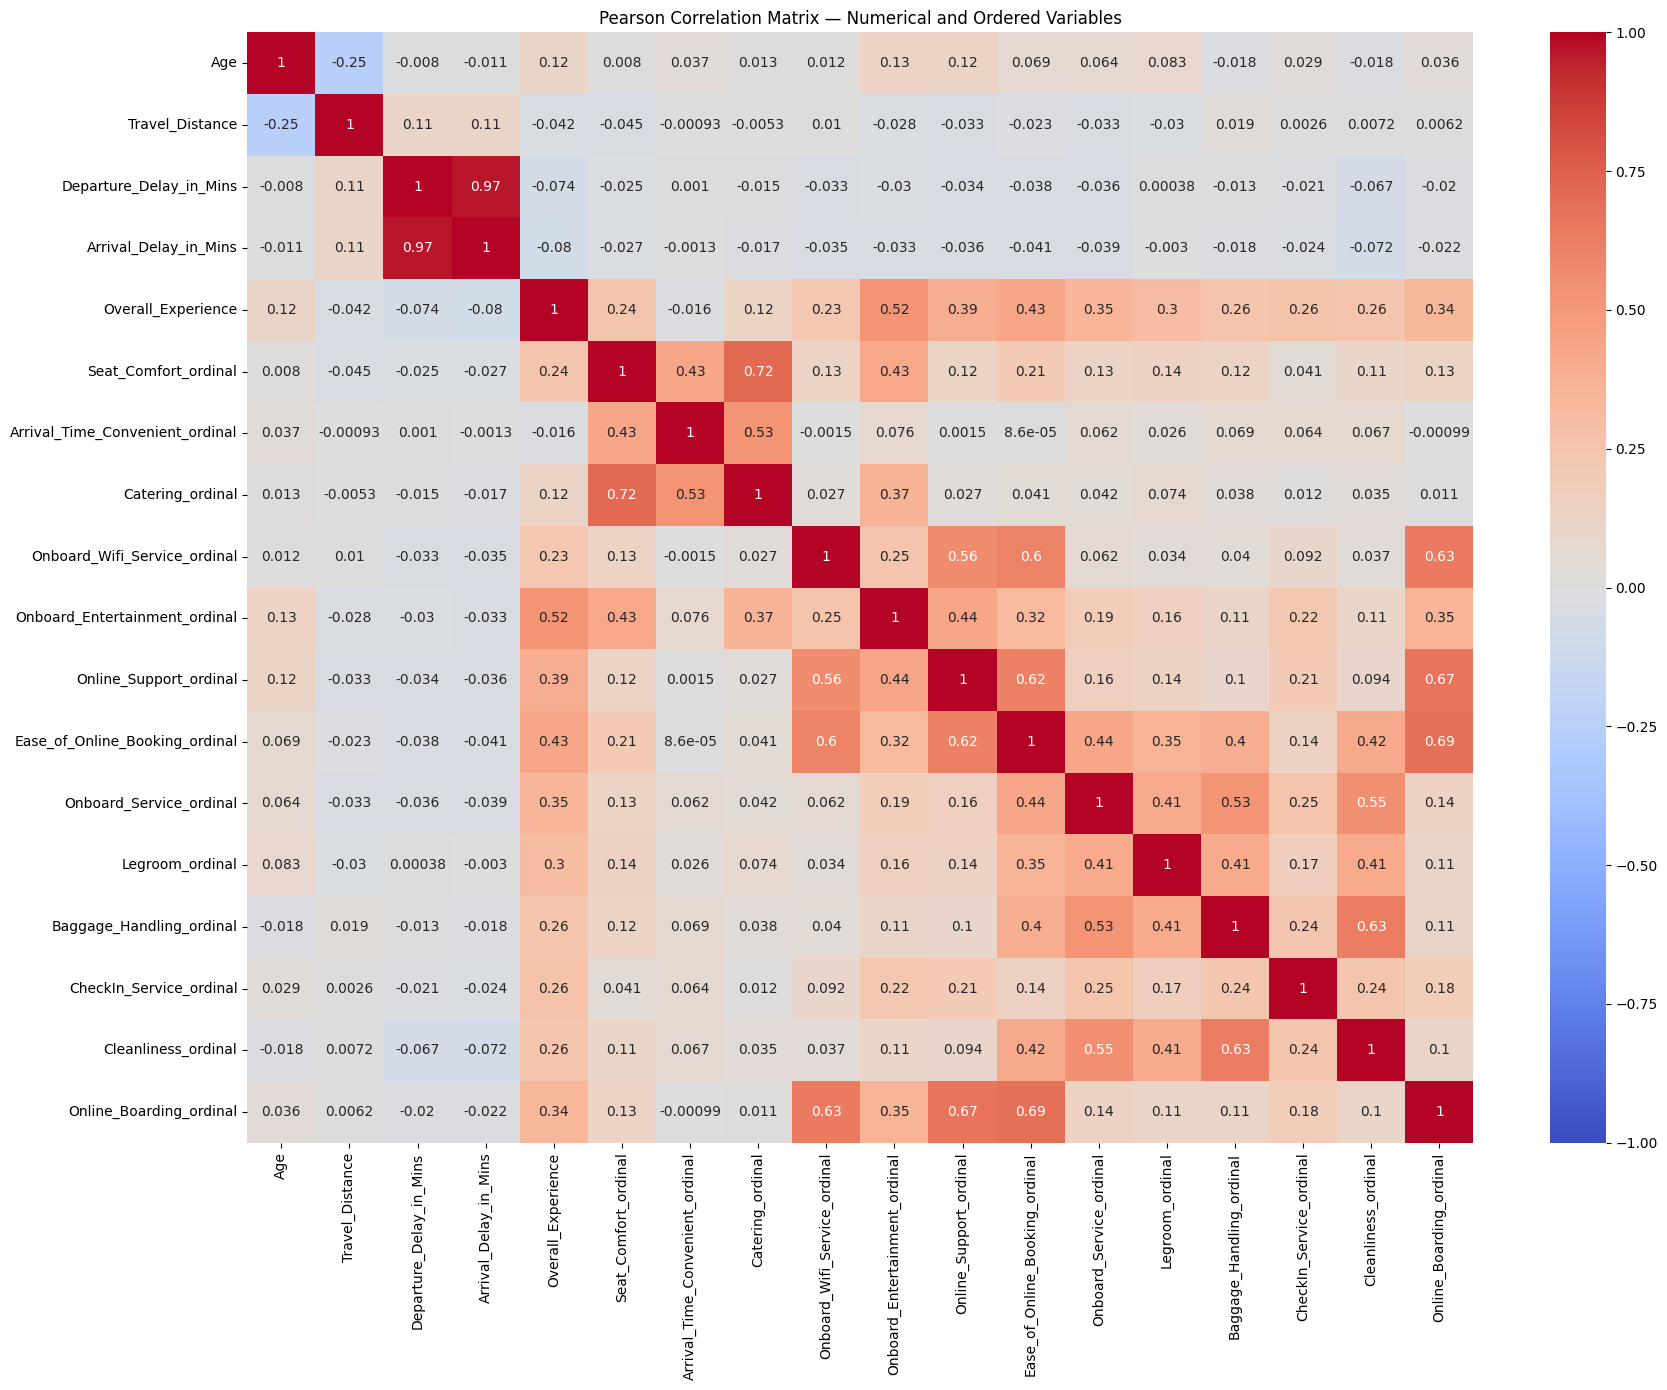

,pearson_r
Onboard_Entertainment_ordinal,0.525
Ease_of_Online_Booking_ordinal,0.432
Online_Support_ordinal,0.392
Onboard_Service_ordinal,0.351
Online_Boarding_ordinal,0.339
Legroom_ordinal,0.303
CheckIn_Service_ordinal,0.263
Baggage_Handling_ordinal,0.258
Cleanliness_ordinal,0.256
Seat_Comfort_ordinal,0.243


In [ ]:
# Purpose: Calculate and plot Pearson correlations for linear relationships among appropriate numerical/ordinal variables.
corr_numeric = df.select_dtypes(include=np.number).copy()
likert_map_eda = {v:i for i,v in enumerate(likert_order_eda)}
for col in feedback_cols_eda:
    corr_numeric[col + '_ordinal'] = df[col].map(likert_map_eda)

pearson_corr = corr_numeric.corr(method='pearson')
plt.figure(figsize=(18,14))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix — Numerical and Ordered Variables')
plt.tight_layout(); plt.show()

if 'Overall_Experience' in pearson_corr:
    display(pearson_corr['Overall_Experience'].drop('Overall_Experience')
            .sort_values(key=lambda x: x.abs(), ascending=False)
            .to_frame('pearson_r').head(20).round(3))

#### **3.8.2 Spearman Correlation Matrix**
Spearman correlation is added because ordered survey ratings and skewed numerical variables may have meaningful monotonic relationships that are not well summarized by a strictly linear coefficient.


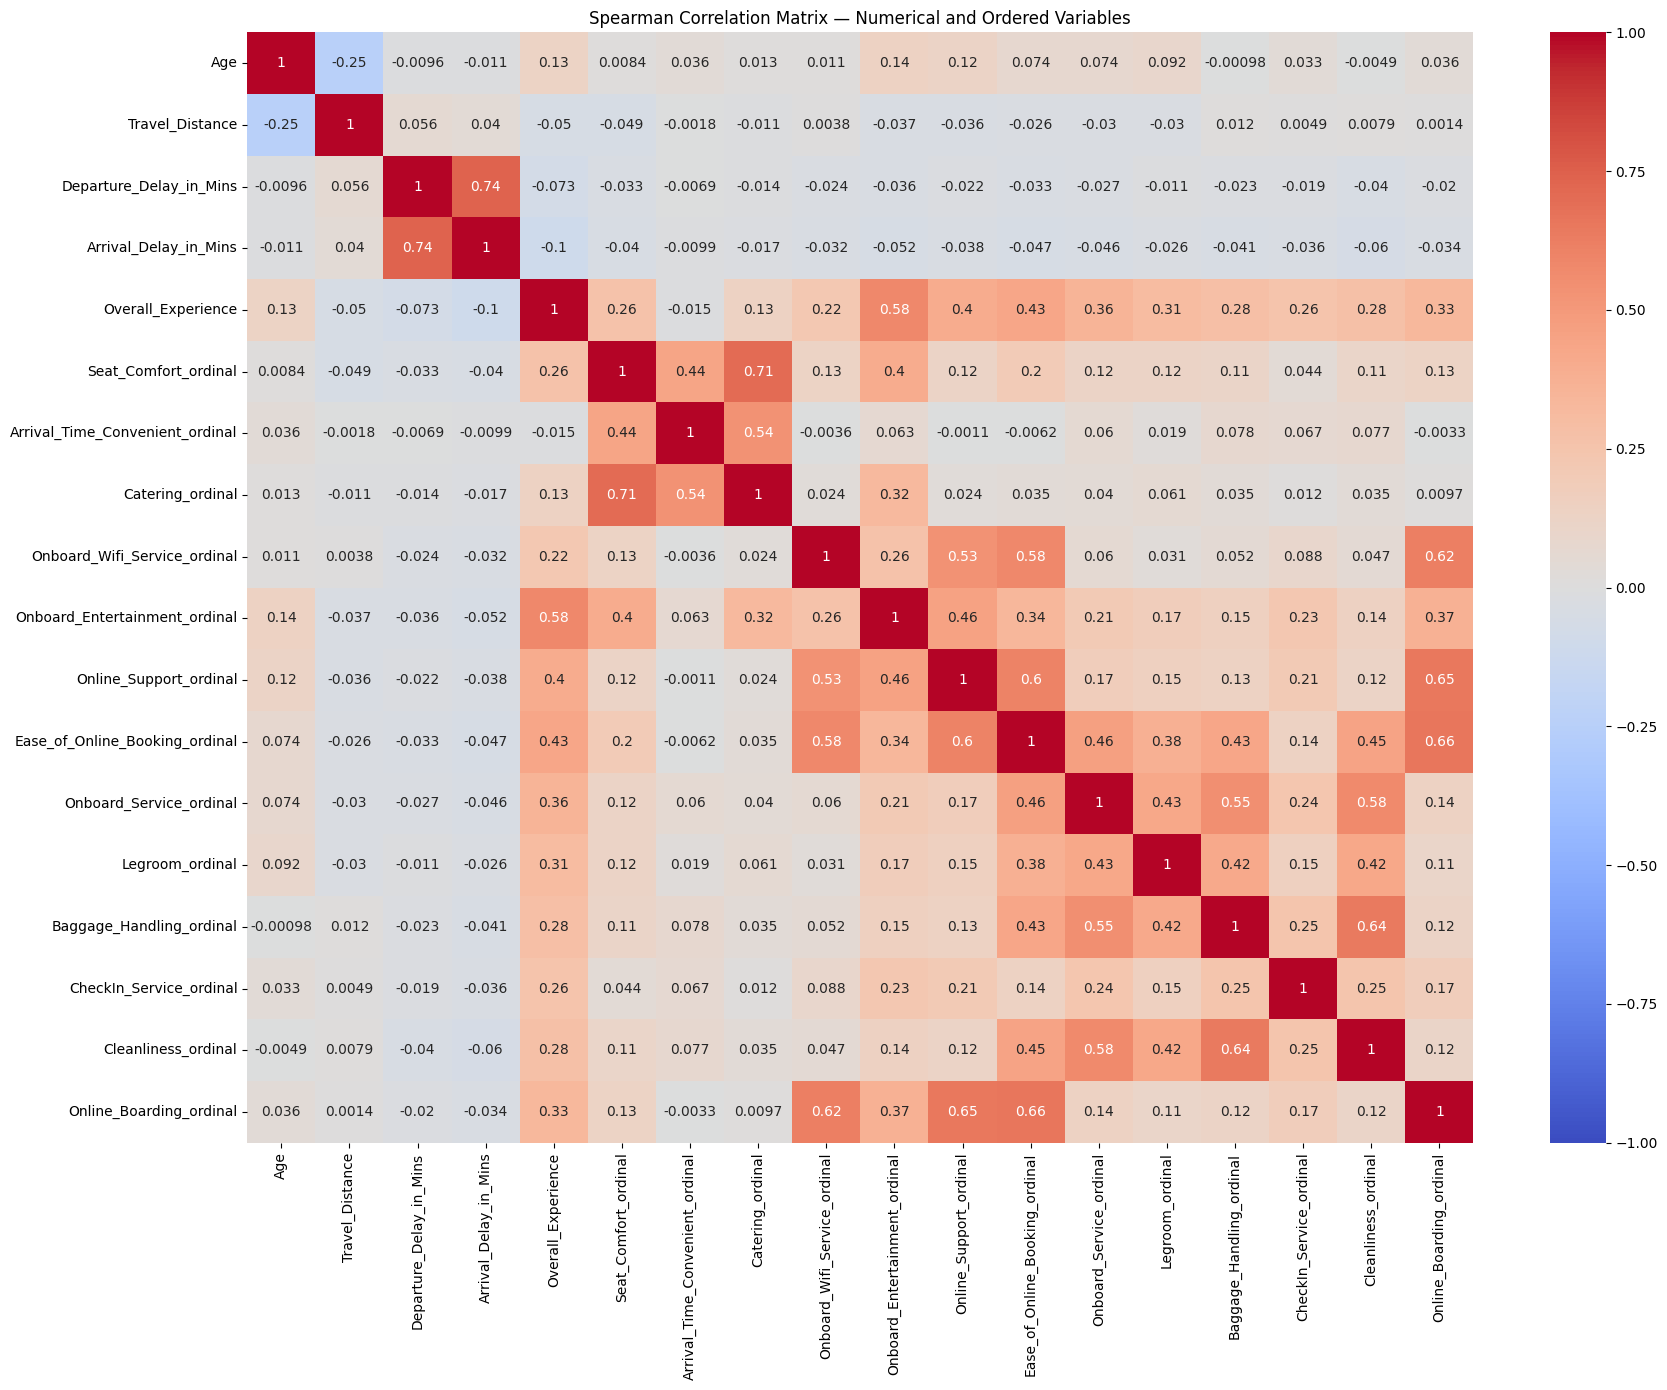

,spearman_rho
Onboard_Entertainment_ordinal,0.579
Ease_of_Online_Booking_ordinal,0.430
Online_Support_ordinal,0.404
Onboard_Service_ordinal,0.356
Online_Boarding_ordinal,0.334
Legroom_ordinal,0.307
Baggage_Handling_ordinal,0.285
Cleanliness_ordinal,0.280
Seat_Comfort_ordinal,0.261
CheckIn_Service_ordinal,0.257


In [ ]:
# Purpose: Calculate and plot Spearman correlations to capture monotonic relationships and reduce sensitivity to skew.
spearman_corr = corr_numeric.corr(method='spearman')
plt.figure(figsize=(18,14))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix — Numerical and Ordered Variables')
plt.tight_layout(); plt.show()

if 'Overall_Experience' in spearman_corr:
    display(spearman_corr['Overall_Experience'].drop('Overall_Experience')
            .sort_values(key=lambda x: x.abs(), ascending=False)
            .to_frame('spearman_rho').head(20).round(3))

#### **3.8.3 Strongest Predictor–Predictor Relationships**
Highly correlated predictors are documented rather than automatically removed. Their importance depends on model family and interpretability goals.


In [ ]:
# Purpose: Rank the strongest predictor-predictor associations so the heatmaps are easier to interpret.
pairs=[]
cols=pearson_corr.columns
for i in range(len(cols)):
    for j in range(i+1,len(cols)):
        if 'Overall_Experience' in (cols[i],cols[j]): continue
        r=pearson_corr.iloc[i,j]
        if pd.notna(r): pairs.append((cols[i],cols[j],r,abs(r)))
strong_pairs=(pd.DataFrame(pairs,columns=['feature_1','feature_2','pearson_r','abs_r'])
              .sort_values('abs_r',ascending=False))
display(strong_pairs.head(25).drop(columns='abs_r').round(3))

,feature_1,feature_2,pearson_r
31,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,0.965
59,Seat_Comfort_ordinal,Catering_ordinal,0.718
120,Ease_of_Online_Booking_ordinal,Online_Boarding_ordinal,0.685
114,Online_Support_ordinal,Online_Boarding_ordinal,0.670
99,Onboard_Wifi_Service_ordinal,Online_Boarding_ordinal,0.634
131,Baggage_Handling_ordinal,Cleanliness_ordinal,0.632
108,Online_Support_ordinal,Ease_of_Online_Booking_ordinal,0.617
93,Onboard_Wifi_Service_ordinal,Ease_of_Online_Booking_ordinal,0.603
92,Onboard_Wifi_Service_ordinal,Online_Support_ordinal,0.558
124,Onboard_Service_ordinal,Cleanliness_ordinal,0.548


#### **3.8.4 Cramér's V Matrix for Nominal Categorical Variables**
Cramér's V measures association between categorical variables without inventing numerical distances between labels.


,Gender,Customer_Type,Type_Travel,Travel_Class,Seat_Class,Overall_Experience
Gender,1.000,0.065,0.008,0.008,0.004,0.215
Customer_Type,0.065,1.000,0.209,0.080,0.000,0.278
Type_Travel,0.008,0.209,1.000,0.524,0.000,0.103
Travel_Class,0.008,0.080,0.524,1.000,0.000,0.310
Seat_Class,0.004,0.000,0.000,0.000,1.000,0.000
Overall_Experience,0.215,0.278,0.103,0.310,0.000,1.000


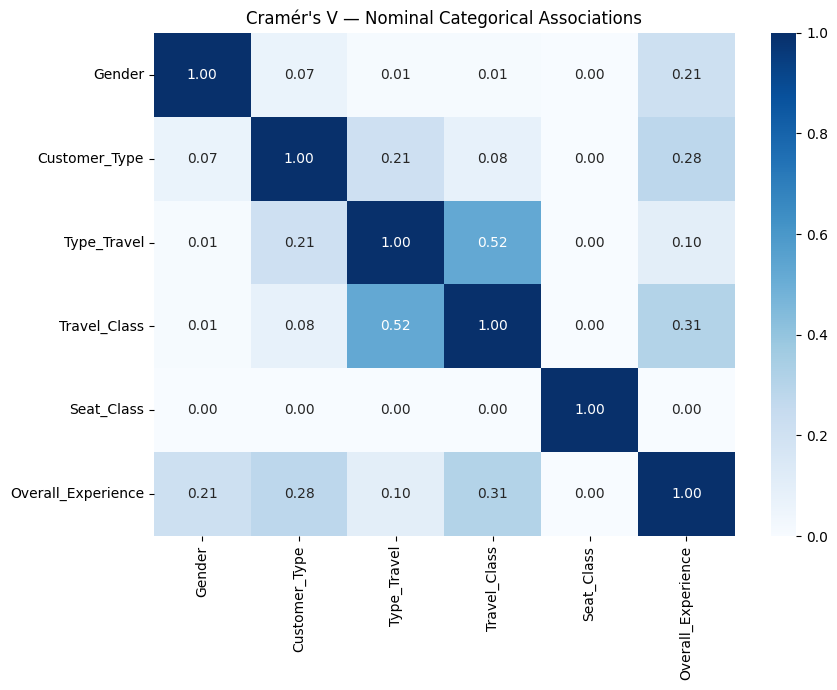

In [ ]:
# Purpose: Calculate Cramér's V for nominal categorical variables and display the categorical association matrix.
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x.fillna('Missing'), y.fillna('Missing'))
    if table.size == 0: return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    if n <= 1: return np.nan
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min(kcorr-1, rcorr-1)
    return np.sqrt(phi2corr/denom) if denom > 0 else np.nan

nominal_cols = [c for c in ['Gender','Customer_Type','Type_Travel','Travel_Class','Seat_Class'] if c in df.columns]
if 'Overall_Experience' in df.columns:
    # Target is binary categorical for association purposes.
    cramers_cols = nominal_cols + ['Overall_Experience']
else:
    cramers_cols = nominal_cols

cv = pd.DataFrame(index=cramers_cols, columns=cramers_cols, dtype=float)
for a in cramers_cols:
    for b in cramers_cols:
        cv.loc[a,b] = 1.0 if a == b else cramers_v(df[a],df[b])

display(cv.round(3))
plt.figure(figsize=(9,7))
sns.heatmap(cv, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title("Cramér's V — Nominal Categorical Associations")
plt.tight_layout(); plt.show()

#### **Observation — Correlation and Association Analysis**

**Pearson target associations**
The strongest displayed Pearson associations with `Overall_Experience` among the numerical/ordinal variables are:
- `Onboard_Entertainment_ordinal`: **0.525**
- `Ease_of_Online_Booking_ordinal`: **0.432**
- `Online_Support_ordinal`: **0.392**
- `Onboard_Service_ordinal`: **0.351**
- `Online_Boarding_ordinal`: **0.339**

`Age` has a weaker positive Pearson association (**0.116**), while departure and arrival delays are weakly negative (**-0.074** and **-0.080**). `Travel_Distance` is also weakly negative (**-0.042**).

**Spearman target associations**
The rank-based results are similar in direction. `Onboard_Entertainment_ordinal` is strongest at **0.579**, followed by `Ease_of_Online_Booking_ordinal` (**0.430**) and `Online_Support_ordinal` (**0.404**). The delay associations remain modestly negative.

**Predictor–predictor relationships**
The clearest redundancy is between `Departure_Delay_in_Mins` and `Arrival_Delay_in_Mins` (**Pearson 0.965**). Several service-rating pairs are also moderately to strongly associated, including `Seat_Comfort_ordinal` with `Catering_ordinal` (**0.718**) and `Ease_of_Online_Booking_ordinal` with `Online_Boarding_ordinal` (**0.685**).

**Cramér's V**
Among nominal variables, `Type_Travel` and `Travel_Class` have the strongest pairwise association (**0.524**). With the target, `Travel_Class` has Cramér's V **0.310**, `Customer_Type` **0.278**, `Gender` **0.215**, and `Type_Travel` **0.103**; `Seat_Class` is effectively zero in the displayed matrix.

#### **Interpretation and Decision**

These statistics measure association, not causation. Strong predictor–predictor association may indicate redundant information, but it does not justify automatic deletion for every model family.

Retain potentially useful correlated predictors during broad model comparison. Revisit redundancy during feature interpretation and controlled ablation rather than deleting variables solely because a heatmap contains large coefficients.


#### **Observation and Interpretation — Correlation and Association**
Interpret these matrices according to what they measure:

- Pearson captures linear association.
- Spearman captures monotonic rank association and is often more informative for ordered ratings or skewed variables.
- Cramér's V captures categorical association but does not provide direction.

A large coefficient is evidence of association, **not causation**. Strong predictor-predictor association may indicate redundant information, but automatic deletion is not justified for every model family. Linear coefficients may become unstable under multicollinearity, whereas tree-based boosting models are generally more tolerant of correlated inputs.

#### **Decision**
Retain potentially useful correlated predictors during broad model comparison. Revisit redundancy when interpreting linear coefficients, feature importance, and ablation results rather than deleting features solely because a heatmap looks dense.


### **3.9 EDA Findings Register**

The following register condenses the executed EDA into downstream modeling implications. It is a decision log, not a replacement for the supporting tables and visualizations above.


#### **EDA Findings Register**

The EDA findings are summarized here as a decision register so that each observation has a clear downstream modeling implication.

| Finding area | Evidence | Modeling implication | Action |
|---|---|---|---|
| Numerical distribution shape | Skewness statistics, histograms/KDE plots, and boxplots | Strong skew and extreme values may affect distance-based, linear, and gradient-based models differently | Carry the evidence into the outlier-treatment decision rather than transforming automatically |
| Missing data | Pre/post-merge missingness audit and missing-value visualizations | Missingness may require model-specific handling and may itself carry information | Test missingness indicators and compare treatment strategies |
| Delay relationship | Delay histograms, scatterplots, and Pearson/Spearman associations | Departure and arrival delays may contain overlapping information and may support engineered delay features | Evaluate redundancy and engineered delay features |
| Service ratings | Ordered rating distributions and target-rate visualizations | The ordered structure contains potentially strong predictive signal | Preserve ordinal meaning where appropriate and test aggregate feedback features |
| Passenger/travel segments | Segment counts and target-rate plots | Nominal categories may contain predictive signal without having numerical order | Retain and encode with model-appropriate methods |
| Mixed-variable associations | Pearson, Spearman, and Cramér's V matrices | Redundancy and association patterns differ by variable type and model family | Use the appropriate association measure; avoid arbitrary numerical coding of nominal fields |

**Interpretation:** this register is not a substitute for the preceding analysis. It is a compact map from EDA evidence to the preprocessing and modeling decisions that follow.

**Next step:** investigate missing values and outliers directly, using these findings as evidence rather than applying generic preprocessing rules.


### **Summary of Exploratory Data Analysis**
EDA now supports its claims with both numerical and visual evidence. The project no longer states that a variable is skewed, associated with the target, or redundant without showing how that conclusion was reached.

#### **What We Did**

- visualized every numerical predictor with histograms/KDE and boxplots;
- compared numerical distributions by target class;
- visualized categorical prevalence and passenger/travel target rates;
- examined age and distance patterns across quantile groups;
- analyzed departure and arrival delays directly;
- visualized ordered service-feedback relationships;
- produced Pearson and Spearman correlation matrices;
- produced a Cramér's V association matrix for nominal categories;
- created an EDA findings register linking evidence to later decisions.

### **Next Step**
Turn the descriptive findings into explicit preprocessing decisions. Missing values and outliers are investigated separately so that treatment follows evidence rather than convention.


## **4. Data Quality, Missing Values, and Outlier Decisions**

This section converts the descriptive findings from the overview and EDA into explicit preprocessing decisions. The workflow follows the principle:

**Question → Evidence → Interpretation → Decision.**

No treatment is applied merely because it is common practice.

### **4.1 Missing-Value Analysis**

#### **Question**
How much information is missing, do missing values occur together, and is the *fact that a value is missing* associated with passenger experience?

#### **Why This Matters**
Blind imputation can erase information if missingness is systematic. Conversely, adding missingness indicators for every variable can create noise when missingness carries no useful signal.

#### **Method**
We examine missing counts and percentages, compare target rates for missing versus observed records, and inspect correlations among missingness indicators.

In [ ]:
# Purpose: Quantify missing-value magnitude, target association, and co-missingness before choosing a treatment strategy.
missing_cols = [c for c in df.columns if df[c].isna().any()]

missing_analysis = pd.DataFrame({
    'missing_count': df[missing_cols].isna().sum(),
    'missing_pct': df[missing_cols].isna().mean().mul(100)
}).sort_values('missing_pct', ascending=False)
display(missing_analysis.round(2))

rows = []
for col in missing_cols:
    flag = df[col].isna()
    observed_rate = df.loc[~flag, 'Overall_Experience'].mean()
    missing_rate = df.loc[flag, 'Overall_Experience'].mean() if flag.any() else np.nan
    rows.append({
        'feature': col,
        'n_missing': flag.sum(),
        'missing_pct': flag.mean()*100,
        'positive_rate_observed': observed_rate*100,
        'positive_rate_missing': missing_rate*100,
        'difference_pp': (missing_rate-observed_rate)*100 if flag.any() else np.nan
    })
missing_target = pd.DataFrame(rows).sort_values('difference_pp', key=lambda s: s.abs(), ascending=False)
display(missing_target.round(2))

,missing_count,missing_pct
Type_Travel,9226,9.78
Customer_Type,8951,9.48
Arrival_Time_Convenient,8930,9.46
Catering,8741,9.26
Onboard_Service,7601,8.05
Arrival_Delay_in_Mins,357,0.38
Baggage_Handling,142,0.15
Online_Support,91,0.10
Legroom,90,0.10
Gender,77,0.08


,feature,n_missing,missing_pct,positive_rate_observed,positive_rate_missing,difference_pp
18,Cleanliness,6,0.01,54.66,100.00,45.34
19,Online_Boarding,6,0.01,54.66,100.00,45.34
13,Ease_of_Online_Booking,73,0.08,54.66,68.49,13.84
12,Online_Support,91,0.10,54.65,65.93,11.28
15,Legroom,90,0.10,54.66,60.00,5.34
0,Gender,77,0.08,54.67,49.35,-5.32
4,Departure_Delay_in_Mins,57,0.06,54.66,57.89,3.23
2,Age,33,0.03,54.67,51.52,-3.15
6,Seat_Comfort,61,0.06,54.67,52.46,-2.21
10,Onboard_Wifi_Service,30,0.03,54.67,56.67,2.00


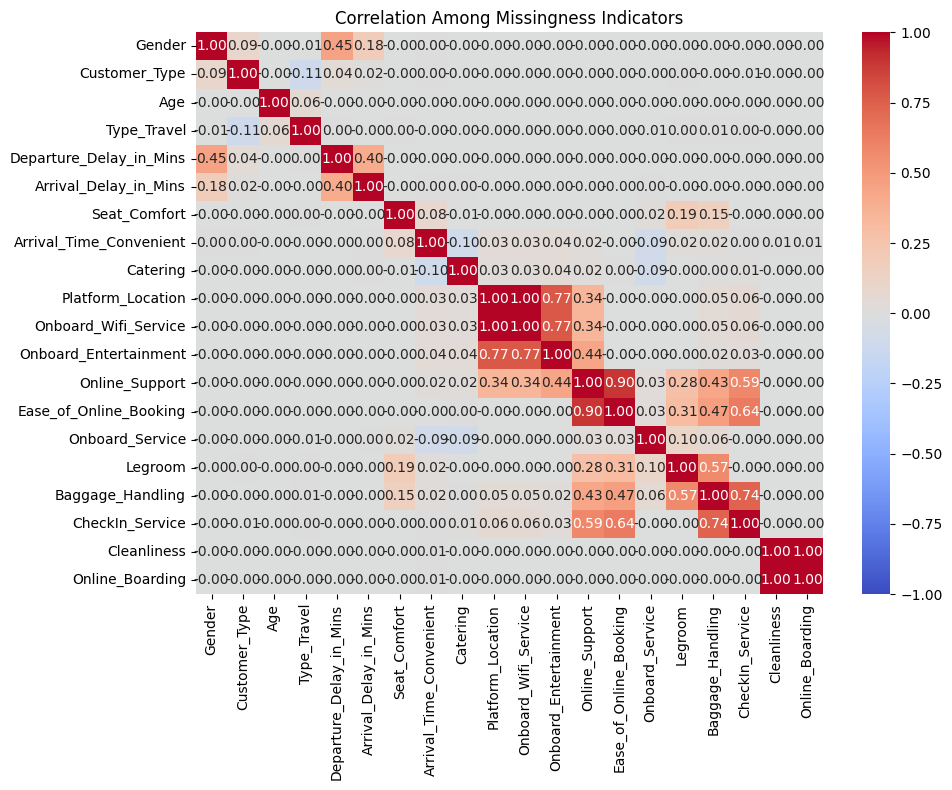

,Gender,Customer_Type,Age,Type_Travel,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Seat_Comfort,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding,count,percent
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,55503,58.81
1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,7118,7.54
2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,7013,7.43
3,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6793,7.20
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6486,6.87
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,6108,6.47
6,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,838,0.89
7,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,838,0.89
8,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,830,0.88
9,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,810,0.86


In [ ]:
# Purpose: Visualize missingness patterns and inspect row-level co-missingness structure.
if len(missing_cols) > 1:
    missing_indicator_df = df[missing_cols].isna().astype(int)
    plt.figure(figsize=(10,8))
    sns.heatmap(missing_indicator_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title('Correlation Among Missingness Indicators')
    plt.tight_layout(); plt.show()

# Most common combined missingness patterns.
if missing_cols:
    patterns = (df[missing_cols].isna().astype(int)
                  .value_counts()
                  .rename('count')
                  .reset_index())
    patterns['percent'] = patterns['count'] / len(df) * 100
    display(patterns.head(15).round(2))

#### **Observation and Interpretation — Missing Values**

Three questions should drive the decision:

1. **Magnitude:** are only a few records missing, or is missingness substantial?
2. **Target association:** does the positive-experience rate differ materially between missing and observed cases?
3. **Co-missingness:** do variables tend to be missing together, suggesting a shared collection process?

#### **Decision — Missing-Value Strategy**

This project does **not** use one global imputation rule for every model.

- Models with reliable native missing-value/categorical handling are allowed to use that capability where appropriate.
- Models requiring complete numeric matrices receive imputed values inside the encoded representation.
- Missingness indicators are treated as hypotheses to test rather than automatically adding one flag for every incomplete column.
- The later feature-engineering section explicitly tests key missingness indicators and retains the negative result if they do not improve or meaningfully separate the target.

#### **Methods Considered but Not Selected Here**

- **Dropping all incomplete rows:** rejected because it discards potentially useful observations and can introduce selection bias when missingness is systematic.
- **Dropping every incomplete feature:** rejected because missingness alone does not establish that a feature lacks predictive value.
- **Mean/mode imputation for all columns:** not adopted as a universal strategy because it ignores model-specific capabilities and can distort distributions or category frequencies.
- **Missingness indicators for every incomplete column:** not adopted automatically because unnecessary indicators can add noise and dimensionality.

#### **Next Step**
Quantify the suspected outliers and compare the original distributions with the proposed capped distributions.

### **4.2 Outlier Analysis**

#### **Question**
How extreme are the upper tails of delay and distance variables, how many observations would common outlier rules flag, and should these observations be removed, transformed, capped, or retained?

#### **Why This Matters**
Extreme values can strongly influence distance-based and linear models, but an unusual value is not necessarily an error. Long travel distances and severe delays may be genuine passenger experiences. Removing them without evidence would discard real information.

#### **Method**
For the main right-tailed variables we calculate IQR bounds, high percentiles, skewness, and the proportion of observations beyond common thresholds. We then visualize the original distributions before applying any treatment.

,mean,median,skewness,q1,q3,IQR,IQR_upper_bound,pct_above_IQR_bound,p95,p99,max,pct_above_p95,pct_above_p99
feature,,,,,,,,,,,,,
Departure_Delay_in_Mins,14.647,0.0,7.157,0.0,12.0,12.0,30.0,13.916,77.0,179.00,1592.0,4.934,0.996
Arrival_Delay_in_Mins,15.005,0.0,6.980,0.0,13.0,13.0,32.5,13.444,78.0,180.79,1584.0,4.957,1.001
Travel_Distance,1978.888,1923.0,0.473,1359.0,2538.0,1179.0,4306.5,2.042,3833.0,4822.22,6951.0,4.994,1.000


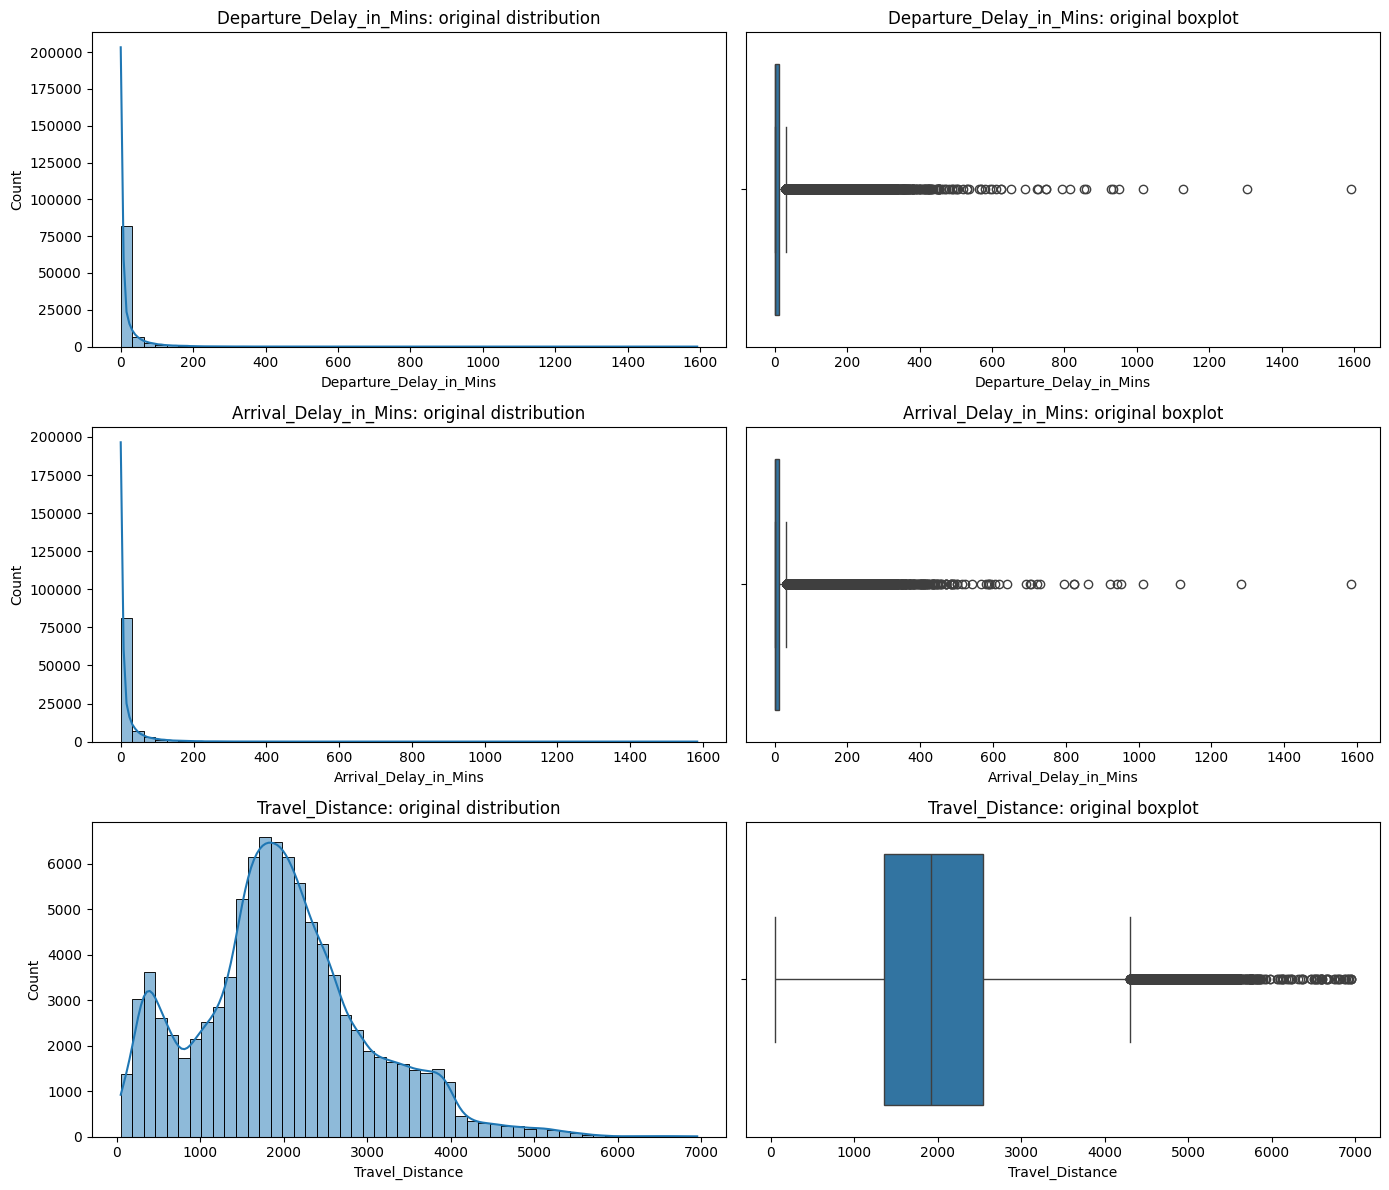

In [ ]:
# Purpose: Quantify suspected upper-tail outliers using skewness, IQR diagnostics, percentiles, and maxima, then visualize them.
outlier_cols = [c for c in ['Departure_Delay_in_Mins','Arrival_Delay_in_Mins','Travel_Distance'] if c in df.columns]
rows = []
for col in outlier_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile([.25,.75])
    iqr = q3-q1
    upper_iqr = q3 + 1.5*iqr
    rows.append({
        'feature': col,
        'mean': s.mean(), 'median': s.median(), 'skewness': s.skew(),
        'q1': q1, 'q3': q3, 'IQR': iqr, 'IQR_upper_bound': upper_iqr,
        'pct_above_IQR_bound': (s>upper_iqr).mean()*100,
        'p95': s.quantile(.95), 'p99': s.quantile(.99), 'max': s.max(),
        'pct_above_p95': (s>s.quantile(.95)).mean()*100,
        'pct_above_p99': (s>s.quantile(.99)).mean()*100
    })
outlier_evidence = pd.DataFrame(rows).set_index('feature')
display(outlier_evidence.round(3))

fig, axes = plt.subplots(len(outlier_cols), 2, figsize=(14, 4*len(outlier_cols)))
if len(outlier_cols) == 1:
    axes = np.array([axes])
for i,col in enumerate(outlier_cols):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=axes[i,0], color='C0')
    axes[i,0].set_title(f'{col}: original distribution')
    sns.boxplot(x=df[col], ax=axes[i,1], color='C0')
    axes[i,1].set_title(f'{col}: original boxplot')
plt.tight_layout(); plt.show()

#### **Observation and Interpretation — Outliers**

The table and plots establish whether the upper tails are genuinely extreme and how much of the dataset would be affected by a treatment rule. The IQR rule is a **diagnostic**, not an automatic deletion rule: heavily skewed legitimate variables can naturally place many observations beyond `Q3 + 1.5 × IQR`.

#### **Decision — Conservative Record Retention with Tail Capping**

The project retains **all passenger records** and caps the three selected variables at the **95th percentile**, matching the modeling pipeline whose downstream results are reported in this notebook. The objective is to reduce the leverage of the most extreme tail while avoiding row deletion.

This is a modeling choice rather than a claim that values above the 95th percentile are invalid.

#### **Methods Considered but Not Selected**

- **Delete outlier rows:** rejected because large distances and delays may be legitimate and deletion would reduce coverage of rare but real experiences.
- **IQR-based deletion:** rejected because the IQR rule can over-flag observations in strongly skewed distributions.
- **Z-score deletion:** rejected because z-scores assume a distributional shape that is poorly suited to strongly skewed variables.
- **Log transform only:** useful for positive skew and used later for travel distance as an engineered representation, but a log transform does not by itself address every model's sensitivity to extreme raw values.
- **No treatment at all:** viable for robust tree-based models, but less suitable for the broad model comparison that also includes distance-based and linear algorithms.

#### **Next Step**
Apply the chosen cap and quantify how the distributions change.

In [ ]:
# Purpose: Apply the selected percentile capping rule while retaining every passenger record.
for col in ['Departure_Delay_in_Mins', 'Arrival_Delay_in_Mins', 'Travel_Distance']:
    p95 = df[col].quantile(0.95)
    df[col] = np.where(df[col] > p95, p95, df[col])
    print(f"Capped '{col}' at {p95:.2f}")

Capped 'Departure_Delay_in_Mins' at 77.00
Capped 'Arrival_Delay_in_Mins' at 78.00
Capped 'Travel_Distance' at 3833.00


,mean,median,skewness,max,p95,mean_after,median_after,skewness_after,max_after
feature,,,,,,,,,
Departure_Delay_in_Mins,14.647,0.0,7.157,1592.0,77.0,11.337,0.0,2.093,77.0
Arrival_Delay_in_Mins,15.005,0.0,6.980,1584.0,78.0,11.655,0.0,2.074,78.0
Travel_Distance,1978.888,1923.0,0.473,6951.0,3833.0,1952.255,1923.0,0.123,3833.0


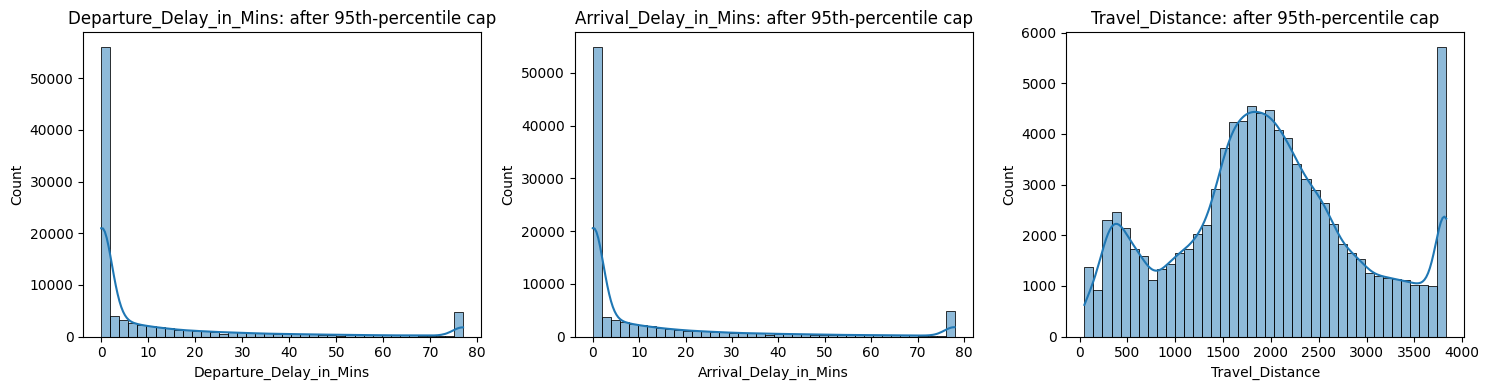

In [ ]:
# Purpose: Compare numerical distributions before and after capping to measure how much the treatment changes the data.
post_cap_rows = []
for col in outlier_cols:
    s = df[col].dropna()
    post_cap_rows.append({
        'feature': col,
        'mean_after': s.mean(),
        'median_after': s.median(),
        'skewness_after': s.skew(),
        'max_after': s.max()
    })
post_cap = pd.DataFrame(post_cap_rows).set_index('feature')
comparison = outlier_evidence[['mean','median','skewness','max','p95']].join(post_cap)
display(comparison.round(3))

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(5*len(outlier_cols),4))
if len(outlier_cols)==1: axes=[axes]
for ax,col in zip(axes,outlier_cols):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=ax, color='C0')
    ax.set_title(f'{col}: after 95th-percentile cap')
plt.tight_layout(); plt.show()

### **Summary of Data Quality and Preprocessing Decisions**

Missingness and outliers have now been treated as analytical questions rather than automatic cleaning steps. Missing-value handling is model-specific, and outlier treatment retains rows while limiting the influence of the most extreme upper-tail values.

### **Next Step**
Engineer features that encode plausible domain relationships, then test whether those representations add predictive information rather than assuming they are beneficial.

## **5. Feature Engineering**

Feature engineering is used to test whether additional representations of passenger behavior improve prediction beyond the original variables. Each engineered feature has a specific analytical rationale, and unsuccessful experiments are retained because they help establish which transformations do and do not add information.

### **5.1 Missingness Indicators**

`Customer_Type` and `Type_Travel` each contain substantial missingness. Binary indicators are therefore created to test whether the *presence of missingness itself* is associated with `Overall_Experience`.


In [ ]:
# Purpose: Create explicit missingness indicators for selected high-missingness categorical fields and inspect their target relationship.
for col in ['Customer_Type', 'Type_Travel']:
    df[col + '_was_missing'] = df[col].isnull().astype(int)

print("Customer_Type missingness vs. target:")
print(pd.crosstab(df['Customer_Type_was_missing'], df['Overall_Experience'], normalize='index').round(3))
print("\nType_Travel missingness vs. target:")
print(pd.crosstab(df['Type_Travel_was_missing'], df['Overall_Experience'], normalize='index').round(3))
print("\nAre the two missingness patterns related?")
print(pd.crosstab(df['Customer_Type_was_missing'], df['Type_Travel_was_missing']))

Customer_Type missingness vs. target:
Overall_Experience             0      1
Customer_Type_was_missing              
0                          0.453  0.547
1                          0.461  0.539

Type_Travel missingness vs. target:
Overall_Experience           0      1
Type_Travel_was_missing              
0                        0.453  0.547
1                        0.454  0.546

Are the two missingness patterns related?
Type_Travel_was_missing        0     1
Customer_Type_was_missing             
0                          76208  9220
1                           8945     6


#### **Observation on Missingness Indicators**

The displayed target-rate tables show that the missingness flags have only a weak marginal relationship with `Overall_Experience`. The co-missingness table also shows that simultaneous missingness in `Customer_Type` and `Type_Travel` is rare.

**Interpretation:** the two missingness patterns appear to reflect largely separate data-collection gaps rather than a strong shared passenger-experience signal. The indicators are retained temporarily so their incremental value can be assessed empirically later rather than being discarded solely from the univariate view.


### **5.2 Delay Features**

Raw departure and arrival delays describe related but not identical aspects of a journey. To capture their combined magnitude and distribution, the project creates:

- `Total_Delay`: combined departure and arrival delay.
- `Has_Delay`: whether any delay occurred.
- `Delay_Ratio`: the proportion of total delay represented by arrival delay.
- `Travel_Distance_Log`: a log transformation of travel distance to reduce right-skew.

These features allow models to distinguish trips with similar total delay but different delay patterns.


In [ ]:
# Purpose: Engineer delay and travel-distance features that represent total delay, delay composition, and nonlinear distance scale.
df['Total_Delay'] = df['Departure_Delay_in_Mins'].fillna(0) + df['Arrival_Delay_in_Mins'].fillna(0)
df['Has_Delay'] = (df['Total_Delay'] > 0).astype(int)
df['Delay_Ratio'] = df['Arrival_Delay_in_Mins'].fillna(0) / (df['Total_Delay'] + 1)

df['Age_Squared'] = df['Age'] ** 2
df['Travel_Distance_Log'] = np.log1p(df['Travel_Distance'])  # right-skewed, log helps linear-ish models

print(df[['Total_Delay','Delay_Ratio','Travel_Distance','Travel_Distance_Log']].describe().round(2))

       Total_Delay  Delay_Ratio  Travel_Distance  Travel_Distance_Log
count     94379.00     94379.00         94379.00             94379.00
mean         22.94         0.24          1952.26                 7.39
std          41.49         0.31           963.49                 0.73
min           0.00         0.00            50.00                 3.93
25%           0.00         0.00          1359.00                 7.22
50%           2.00         0.00          1923.00                 7.56
75%          24.00         0.50          2538.00                 7.84
max         155.00         0.99          3833.00                 8.25


#### **Observation on Delay Features**

`Delay_Ratio` is zero for many passengers because they experienced no delay or because the recorded delay is concentrated at departure. Values closer to one identify journeys where delay is concentrated at arrival.

This provides information that `Total_Delay` alone cannot represent, while the log-transformed distance offers a less skewed alternative to the raw travel-distance measure.


### **5.3 Ordinal Encoding and Feedback Aggregates**

The service-feedback variables are ordered rating scales. Treating them as unordered one-hot categories discards that ordering, so the ratings are mapped to ordinal numeric values.

Two aggregate feedback features are then created:

- `Avg_Feedback_Score`: the passenger's average service rating.
- `Feedback_Score_Std`: the variability of that passenger's ratings across service dimensions.

The second feature tests whether *consistency* of the passenger's experience contains information beyond the average rating alone.


In [ ]:
# Purpose: Convert ordered service ratings into ordinal numeric features and summarize feedback level and consistency.
likert_order = ['Extremely Poor', 'Poor', 'Needs Improvement', 'Acceptable', 'Good', 'Excellent']
likert_map = {v: i for i, v in enumerate(likert_order)}
likert_cols = ['Seat_Comfort','Arrival_Time_Convenient','Catering',
               'Onboard_Wifi_Service','Onboard_Entertainment','Online_Support',
               'Ease_of_Online_Booking','Onboard_Service','Legroom','Baggage_Handling',
               'CheckIn_Service','Cleanliness','Online_Boarding']
for col in likert_cols:
    df[col + '_ord'] = df[col].map(likert_map)

platform_order = ['Very Inconvenient', 'Inconvenient', 'Needs Improvement', 'Manageable', 'Convenient', 'Very Convenient']
platform_map = {v: i for i, v in enumerate(platform_order)}
df['Platform_Location_ord'] = df['Platform_Location'].map(platform_map)
likert_cols_all = likert_cols + ['Platform_Location']
ord_cols = [c + '_ord' for c in likert_cols_all]

df['Avg_Feedback_Score'] = df[ord_cols].mean(axis=1)
df['Feedback_Score_Std'] = df[ord_cols].std(axis=1)

print(df[['Avg_Feedback_Score','Feedback_Score_Std']].describe().round(2))

       Avg_Feedback_Score  Feedback_Score_Std
count            94379.00            94379.00
mean                 3.32                1.15
std                  0.67                0.36
min                  1.07                0.00
25%                  2.86                0.88
50%                  3.36                1.14
75%                  3.79                1.41
max                  5.00                2.39


#### **Observation on Ordinal Encoding and Feedback Aggregates**

**Ordinal encoding:** the 13 Likert-style service variables and `Platform_Location` are mapped to ordered integer scales from **0 to 5**. The mapping preserves the stated category order while making the variables usable in numerical summaries and model representations.

**Aggregate feedback scores**
- `Avg_Feedback_Score` has a mean of **3.32** and a standard deviation of **0.67** in the stored output.
- `Feedback_Score_Std` has a mean of **1.15** and a standard deviation of **0.36**.

`Avg_Feedback_Score` summarizes the overall level of a passenger's service ratings. `Feedback_Score_Std` measures within-passenger variation across those ratings: lower values indicate more consistent ratings, while higher values indicate a more mixed service profile.

These aggregates are candidate predictors; their usefulness must be assessed by validation and feature analysis rather than inferred from their construction alone.


### **5.4 Feedback-Pattern Clustering**

K-Means clustering is applied to the standardized ordinal feedback ratings to identify recurring patterns of passenger experience. The objective is to capture combinations of service ratings that may not be summarized fully by a single average score.

The resulting `Feedback_Cluster` feature represents the passenger's broader feedback profile rather than a demographic segment.


In [ ]:
# Purpose: Cluster service-feedback patterns to test whether latent passenger-rating profiles exist.
feedback_matrix = df[ord_cols].copy()
imputer = SimpleImputer(strategy='median')
feedback_imputed = imputer.fit_transform(feedback_matrix)
feedback_scaled = StandardScaler().fit_transform(feedback_imputed)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Feedback_Cluster'] = km.fit_predict(feedback_scaled).astype(str)

print("Cluster sizes:")
print(df['Feedback_Cluster'].value_counts())

Cluster sizes:
Feedback_Cluster
0    30116
3    21667
1    21498
2    21098
Name: count, dtype: int64


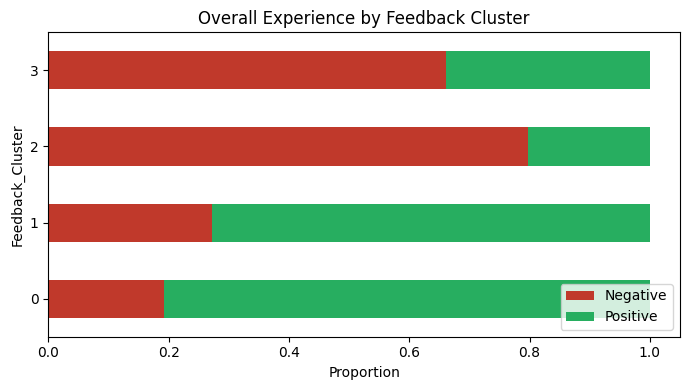

                  Negative  Positive
Feedback_Cluster                    
0                    0.193     0.807
1                    0.271     0.729
2                    0.797     0.203
3                    0.661     0.339


In [ ]:
# Purpose: Visualize cluster sizes and target rates to evaluate the cluster feature descriptively.
ct = pd.crosstab(df['Feedback_Cluster'], df['Overall_Experience'], normalize='index')
ct.columns = ['Negative','Positive']
fig, ax = plt.subplots(figsize=(7,4))
ct.plot(kind='barh', stacked=True, color=['#c0392b','#27ae60'], ax=ax)
ax.set_xlabel('Proportion'); ax.set_title('Overall Experience by Feedback Cluster')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
print(ct.round(3))

#### **Observation on Feedback Clusters**

The displayed cluster-by-target table shows substantial differences in positive-experience rates across the four feedback clusters.

**Interpretation:** clustering captures meaningful structure in the service-rating patterns and is therefore a plausible candidate feature. However, strong standalone separation does not prove incremental predictive value once the model also receives the underlying service ratings and aggregate feedback features. The cluster label is retained for later importance and model-level assessment.


### **5.5 Final Feature Set**

The final modeling feature set combines raw passenger/travel variables, engineered delay measures, ordinal service ratings, aggregate feedback measures, missingness indicators, and the feedback-cluster feature. The target variable itself is excluded from the predictors.


In [ ]:
# Purpose: Assemble the final native feature list and verify feature-group counts.
# Define the original nominal categorical predictors explicitly before adding engineered categories.
nominal_cols_base = [
    'Gender',
    'Customer_Type',
    'Type_Travel',
    'Travel_Class',
    'Seat_Class'
]

# Add the engineered feedback cluster to the original nominal feature group.
nominal_cols = nominal_cols_base + ['Feedback_Cluster']

# Define the numerical predictors used by the final model representations.
numeric_cols_model = [
    'Age',
    'Travel_Distance',
    'Travel_Distance_Log',
    'Departure_Delay_in_Mins',
    'Arrival_Delay_in_Mins',
    'Total_Delay',
    'Has_Delay',
    'Delay_Ratio',
    'Age_Squared',
    'Avg_Feedback_Score',
    'Feedback_Score_Std',
    'Customer_Type_was_missing',
    'Type_Travel_was_missing'
]

# Verify that the expected feature groups have been assembled successfully.
print(
    f"numeric: {len(numeric_cols_model)}  "
    f"ordinal: {len(ord_cols)}  "
    f"nominal: {len(nominal_cols)}"
)
print(
    f"Total: {len(numeric_cols_model) + len(ord_cols) + len(nominal_cols)} columns"
)

numeric: 13  ordinal: 14  nominal: 6
Total: 33 columns


### **5.6 Model-Specific Feature Representations**

Two representations are created so that each algorithm receives data in a form appropriate to its assumptions:

1. **Native representation:** categorical dtypes and missing values are preserved for CatBoost, XGBoost, and LightGBM.
2. **Encoded representation:** categorical variables are one-hot encoded, missing numeric values are imputed, and scaling is available for algorithms that require or benefit from numeric standardized inputs.

This avoids forcing all model families through one preprocessing scheme when their capabilities differ.


In [ ]:
# Purpose: Create model-specific native and fully numeric feature representations for algorithms with different input requirements.
y = df['Overall_Experience']

X_native = df[numeric_cols_model + ord_cols + nominal_cols].copy()
for c in nominal_cols:
    X_native[c] = X_native[c].astype('category')

X_native_str = df[numeric_cols_model + ord_cols + nominal_cols].copy()
for c in nominal_cols:
    X_native_str[c] = X_native_str[c].fillna('Missing').astype(str)
cat_feature_idx = [X_native_str.columns.get_loc(c) for c in nominal_cols]

X_enc = df[numeric_cols_model + ord_cols].copy()
for c in numeric_cols_model + ord_cols:
    X_enc[c] = X_enc[c].fillna(X_enc[c].median())
X_enc = pd.concat([X_enc, pd.get_dummies(df[nominal_cols], drop_first=True)], axis=1)

print("X_native:", X_native.shape, " X_enc:", X_enc.shape)

X_native: (94379, 33)  X_enc: (94379, 35)


### **Summary of Feature Engineering**

The native modeling representation contains original numerical variables, ordinal service ratings, nominal passenger/travel variables, and engineered hypotheses such as delay aggregates, feedback aggregates, missingness indicators, and the feedback-cluster feature. A second fully numeric representation is prepared for algorithms that cannot consume native categorical variables.

At this stage, engineered features are treated as **candidates**, not assumed improvements. Their predictive value is tested only after a train/validation/test split exists. Target encoding is also deferred until after the split because it depends on the target and therefore requires explicit leakage controls.

### **Next Step**

Create independent training, validation, and test subsets before any target-dependent encoding or predictive feature-ablation experiment.


## **6. Train, Validation, and Test Split**

The modeling stage uses a stratified **70% / 15% / 15%** split:

- **Training set:** model fitting and training-derived transformations.
- **Validation set:** model comparison, hyperparameter selection, representation tests, and ensemble selection.
- **Test set:** final performance evaluation after supervised model-selection decisions are frozen.

Stratification preserves target-class proportions across the three subsets.

### **Leakage-Scope Note**

The split occurs before target encoding, feature-ablation testing, model fitting, tuning, and ensemble selection, so **test performance is not used to choose models, representations, hyperparameters, or ensembles**.

The notebook does, however, have two important scope limitations:

1. percentile capping and unsupervised feature construction were developed on the merged dataset before the split;
2. the target-encoding code creates test-row encodings using mappings learned exclusively from the training subset, although those encoded test features are not scored until final evaluation.

Accordingly, the correct description is that the test subset is **held out from supervised model selection**, not untouched by every preprocessing operation. A stricter production pipeline would split immediately after merge validation and fit every data-derived transformation—including capping and clustering—on training data only before applying it to validation and test rows.

### **Why This Differs from `shinkansen_hackaton.ipynb`****

**`shinkansen_hackaton.ipynb`** uses an 80/20 train-test workflow and reports tuning outcomes during model development. Here, a separate validation subset is introduced so that model and hyperparameter selection do not depend on final test performance. This provides a more independent final evaluation while keeping the remaining preprocessing-scope limitation explicit.


### **6.1 Class-Imbalance Assessment**

#### **Question**
Is the target sufficiently imbalanced to justify resampling techniques such as SMOTE, random oversampling, or undersampling?

#### **Why This Matters**
Resampling can help when one class is rare, but it can also distort the training distribution, discard useful observations, or create synthetic points that are unnecessary when the classes are already reasonably balanced.

#### **Method and Evidence**
The target distribution measured in the Data Overview is reused here. We compare the minority and majority shares and retain ROC-AUC, F1, precision, and recall alongside accuracy during model evaluation.

In [ ]:
# Purpose: Measure class balance numerically before deciding whether resampling or class weighting is justified.
class_counts = y.value_counts().sort_index() if 'y' in globals() else df['Overall_Experience'].value_counts().sort_index()
class_pct = class_counts / class_counts.sum() * 100
display(pd.DataFrame({'count': class_counts, 'percent': class_pct.round(2)}))
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Majority/minority ratio: {imbalance_ratio:.3f}:1")

,count,percent
Overall_Experience,,
0,42786,45.33
1,51593,54.67


Majority/minority ratio: 1.206:1


#### **Decision — No Resampling**

If the displayed class proportions confirm the reasonably balanced target seen earlier, SMOTE, random oversampling, and undersampling are **not selected**.

- **SMOTE / oversampling:** unnecessary when the minority class is already well represented; synthetic or duplicated observations could add complexity without solving a meaningful imbalance problem.
- **Undersampling:** rejected because it would discard valid training data.
- **Class weighting:** not used as a default because there is no severe imbalance requiring correction.

The project still evaluates ROC-AUC, F1, precision, and recall so that model quality is not judged by accuracy alone.

#### **Next Step**
Create the train/validation/test split with stratification so the observed class proportions are preserved across all subsets.

In [ ]:
# Purpose: Create stratified train, validation, and test indices so model selection is separated from final evaluation.
idx = np.arange(len(df))
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=42, stratify=y)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42, stratify=y.iloc[idx_temp])

y_train, y_val, y_test = y.iloc[idx_train], y.iloc[idx_val], y.iloc[idx_test]
print(f"Train: {len(idx_train)}  Val: {len(idx_val)}  Test: {len(idx_test)}")

Train: 66065  Val: 14157  Test: 14157


### **6.2 Alternative Categorical Encoding: Leakage-Controlled K-Fold Target Encoding**

#### **Question**
Does replacing nominal categories with training-derived target-rate estimates improve validation performance over native categorical handling?

#### **Why This Is Tested After the Split**
Target encoding uses the target itself to construct features. Performing it before the train/validation/test split would create leakage. The experiment is therefore delayed until split indices exist, and training rows receive **out-of-fold** encodings so that no row uses its own target value.

#### **Method**
The experiment compares two untuned LightGBM models under the same train/validation split and model configuration:

1. native categorical handling;
2. leakage-controlled K-fold target encoding.

The comparison is intentionally performed before hyperparameter tuning so that the representation—not tuning effort—is the main variable being tested.


In [ ]:
# Purpose: Compare leakage-controlled target encoding with native categorical handling using only training-derived target statistics.
te_cols = list(nominal_cols)

# Start with the same numerical and ordinal predictors used by the native representation.
X_te = df[numeric_cols_model + ord_cols].copy()

# Build out-of-fold encodings for training rows so no training row sees its own target.
te_cv = KFold(n_splits=5, shuffle=True, random_state=42)
global_target_mean = y_train.mean()

for col in te_cols:
    encoded = pd.Series(index=df.index, dtype=float)

    # OOF encodings for training observations.
    train_positions = np.arange(len(idx_train))
    for fit_pos, hold_pos in te_cv.split(train_positions):
        fit_idx = idx_train[fit_pos]
        hold_idx = idx_train[hold_pos]

        mapping = (
            pd.DataFrame({'category': df.loc[fit_idx, col], 'target': y.loc[fit_idx]})
            .groupby('category', dropna=False)['target']
            .mean()
        )
        encoded.loc[hold_idx] = df.loc[hold_idx, col].map(mapping).fillna(global_target_mean)

    # Validation/test encodings use a mapping learned from the entire training subset only.
    full_train_mapping = (
        pd.DataFrame({'category': df.loc[idx_train, col], 'target': y_train.to_numpy()})
        .groupby('category', dropna=False)['target']
        .mean()
    )
    non_train_idx = np.concatenate([idx_val, idx_test])
    encoded.loc[non_train_idx] = df.loc[non_train_idx, col].map(full_train_mapping).fillna(global_target_mean)

    X_te[f'{col}_target_encoded'] = encoded

# Use the same untuned LightGBM configuration for both representations.
te_params = dict(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

m_te = lgb.LGBMClassifier(**te_params)
m_te.fit(X_te.iloc[idx_train], y_train)
te_prob = m_te.predict_proba(X_te.iloc[idx_val])[:, 1]

m_native_te_compare = lgb.LGBMClassifier(**te_params)
m_native_te_compare.fit(
    X_native.iloc[idx_train],
    y_train,
    categorical_feature=nominal_cols,
)
native_prob_te_compare = m_native_te_compare.predict_proba(X_native.iloc[idx_val])[:, 1]

target_encoding_results = pd.DataFrame([
    {
        'Representation': 'K-fold target encoding',
        'Validation ROC-AUC': roc_auc_score(y_val, te_prob),
    },
    {
        'Representation': 'Native categorical handling',
        'Validation ROC-AUC': roc_auc_score(y_val, native_prob_te_compare),
    },
]).sort_values('Validation ROC-AUC', ascending=False).reset_index(drop=True)

target_encoding_results['Difference vs native'] = (
    target_encoding_results['Validation ROC-AUC']
    - target_encoding_results.loc[
        target_encoding_results['Representation'].eq('Native categorical handling'),
        'Validation ROC-AUC'
    ].iloc[0]
)

display(target_encoding_results.style.format({
    'Validation ROC-AUC': '{:.6f}',
    'Difference vs native': '{:+.6f}',
}))

,Representation,Validation ROC-AUC,Difference vs native
0,K-fold target encoding,0.992841,+0.000059
1,Native categorical handling,0.992782,+0.000000


#### **Observation and Decision on Target Encoding**

The comparison table is generated from the two models fitted in this section. In the stored execution, K-fold target encoding reaches **0.992841 validation ROC-AUC**, compared with **0.992782** for native categorical handling—a difference of only **+0.000059**.

**Decision rule:** adopt target encoding only when its validation benefit is large enough to justify additional preprocessing complexity and leakage controls.

**Decision:** the observed gain is negligible, so **native categorical handling is retained**. This follows the principle of preferring the simpler representation when predictive performance is effectively equivalent.

#### **Next Step**
Compare the broader engineered representation with a simpler original-variable benchmark under the same validation design.


### **6.3 Feature Engineering and Representation Ablation Test**

#### **Question**
Does the expanded engineered representation actually improve predictive performance relative to a simpler representation built from the original variables?

#### **Why This Matters**
Feature engineering should not be retained because it sounds plausible. Engineered features can duplicate existing information, increase dimensionality, and encourage overfitting. A reference-quality workflow therefore tests whether the additional representation produces measurable validation value.

#### **Method**
We build two LightGBM models with the **same fixed hyperparameters** and the **same training/validation rows**:

1. **Original-feature baseline:** original numerical variables plus one-hot encoded original categorical and service-feedback variables.
2. **Engineered representation:** the model matrix created in Section 5, including ordinal service ratings, delay features, nonlinear age/distance representations, feedback aggregates, missingness indicators, and feedback clustering.

This is an **ablation-style comparison**. Because the representation and encoding both differ, it should be interpreted as evidence about the complete engineered representation rather than the isolated causal effect of one feature.

In [ ]:
# Purpose: Run a controlled ablation comparing original variables with the engineered representation under the same LightGBM setup.
# Build a simple representation from original variables only.
base_numeric_cols = [c for c in ['Age','Travel_Distance','Departure_Delay_in_Mins','Arrival_Delay_in_Mins'] if c in df.columns]
base_categorical_cols = [c for c in [
    'Gender','Customer_Type','Type_Travel','Travel_Class','Seat_Class','Platform_Location',
    'Seat_Comfort','Arrival_Time_Convenient','Catering','Onboard_Wifi_Service',
    'Onboard_Entertainment','Online_Support','Ease_of_Online_Booking','Onboard_Service',
    'Legroom','Baggage_Handling','CheckIn_Service','Cleanliness','Online_Boarding'
] if c in df.columns]

X_original_encoded = df[base_numeric_cols].copy()
for c in base_numeric_cols:
    X_original_encoded[c] = X_original_encoded[c].fillna(X_original_encoded[c].median())
X_original_encoded = pd.concat([
    X_original_encoded,
    pd.get_dummies(df[base_categorical_cols], dummy_na=True, drop_first=False)
], axis=1)

ablation_model_original = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    random_state=42, verbosity=-1
)
ablation_model_engineered = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    random_state=42, verbosity=-1
)

ablation_model_original.fit(X_original_encoded.iloc[idx_train], y_train)
p_original = ablation_model_original.predict_proba(X_original_encoded.iloc[idx_val])[:,1]
pred_original = (p_original >= 0.5).astype(int)

ablation_model_engineered.fit(X_enc.iloc[idx_train], y_train)
p_engineered = ablation_model_engineered.predict_proba(X_enc.iloc[idx_val])[:,1]
pred_engineered = (p_engineered >= 0.5).astype(int)

ablation_results = pd.DataFrame([
    {
        'Representation':'Original variables',
        'Features_after_encoding':X_original_encoded.shape[1],
        'Accuracy':accuracy_score(y_val, pred_original),
        'ROC_AUC':roc_auc_score(y_val, p_original),
        'F1':f1_score(y_val, pred_original)
    },
    {
        'Representation':'Engineered representation',
        'Features_after_encoding':X_enc.shape[1],
        'Accuracy':accuracy_score(y_val, pred_engineered),
        'ROC_AUC':roc_auc_score(y_val, p_engineered),
        'F1':f1_score(y_val, pred_engineered)
    }
]).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
ablation_results.index = ablation_results.index + 1
ablation_results.index.name = 'Rank'
display(ablation_results.round(5))

roc_gain = ablation_results.loc[ablation_results['Representation']=='Engineered representation','ROC_AUC'].iloc[0] - \
           ablation_results.loc[ablation_results['Representation']=='Original variables','ROC_AUC'].iloc[0]
print(f"Engineered minus original ROC-AUC: {roc_gain:+.6f}")

,Representation,Features_after_encoding,Accuracy,ROC_AUC,F1
Rank,,,,,
1,Original variables,116,0.95500,0.99325,0.95856
2,Engineered representation,35,0.95225,0.99238,0.95601


Engineered minus original ROC-AUC: -0.000867


#### **Observation, Interpretation, and Decision — Feature Engineering**

The controlled ablation table compares an original-variable representation with the expanded engineered representation under the same LightGBM configuration and validation split.

**Observation:** in the current run, the **original-variable representation performs better on validation ROC-AUC** than the full engineered representation. The expanded feature set therefore does **not** earn a claim of overall predictive improvement from this ablation.

**Interpretation:** this does not mean every engineered feature is useless. Later feature-importance analysis can still show that individual engineered variables are used by the fitted model. It means that, as a package, the engineered representation does not outperform the simpler representation in this controlled benchmark.

**Decision:** retain selected engineered variables for the broad multi-model experiment because they provide interpretable hypotheses and may interact differently with other model families, but do not describe feature engineering as an overall performance gain unless later evidence demonstrates that directly.

#### **Next Step**
Proceed to the full baseline model comparison while keeping the ablation result as an explicit negative finding.


### **Summary of Split and Representation Tests**

The stratified split creates separate training, validation, and test subsets. Their exact sizes and class proportions are generated by the code above rather than repeated manually.

The post-split experiments then test two representation questions without using the final test labels for model selection:

- whether leakage-controlled target encoding improves on native categorical handling;
- whether the expanded engineered representation improves on a simpler original-variable benchmark.

These results determine which representations deserve to proceed into the broader model comparison.

### **Next Step**

Check the computational feasibility of algorithms whose scaling behavior may prevent a fair full-dataset benchmark.


## **7. Computational Feasibility of SVM and KNN**

Before including every candidate in the baseline comparison, computational feasibility is measured rather than assumed. SVM can scale poorly with sample size, while KNN shifts much of its computational cost from training to prediction.

Timing experiments are therefore used to determine whether these algorithms can reasonably be evaluated at the available dataset size.


In [ ]:
# Purpose: Empirically time SVM fits on increasing sample sizes and fit a scaling curve for full-data feasibility estimation.
num_cols_for_timing = X_enc.columns.tolist()  # already numeric/encoded

timing_results = []
for n in [2000, 5000, 10000]:
    Xs = StandardScaler().fit_transform(X_enc.iloc[:n])
    ys = y.iloc[:n]
    t0 = time.time()
    SVC(probability=True, random_state=42).fit(Xs, ys)
    t_svc = time.time() - t0
    timing_results.append({'n': n, 'svc_fit_s': t_svc})
    print(f"n={n}: SVC fit = {t_svc:.2f}s")

# fit a power law to extrapolate to the full training set
ns = np.array([r['n'] for r in timing_results])
ts = np.array([r['svc_fit_s'] for r in timing_results])
b, log_a = np.polyfit(np.log(ns), np.log(ts), 1)
a = np.exp(log_a)
est_full = a * len(idx_train) ** b
print(f"\nFitted power law: time ~ n^{b:.2f}")
print(f"Extrapolated single-fit time at full train size ({len(idx_train)} rows): {est_full/60:.1f} minutes")

n=2000: SVC fit = 0.55s
n=5000: SVC fit = 3.33s
n=10000: SVC fit = 14.87s

Fitted power law: time ~ n^2.05
Extrapolated single-fit time at full train size (66065 rows): 11.5 minutes


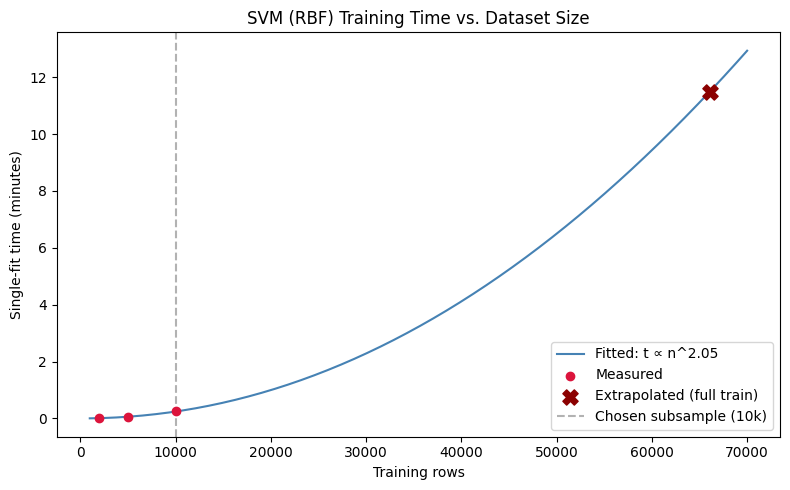

In [ ]:
# Purpose: Visualize measured SVM scaling and the extrapolated full-training-set estimate.
fig, ax = plt.subplots(figsize=(8,5))
xs = np.linspace(1000, 70000, 200)
ys_fit = a * xs**b
ax.plot(xs, ys_fit/60, '-', color='steelblue', label=f'Fitted: t ∝ n^{b:.2f}')
ax.scatter(ns, ts/60, color='crimson', zorder=5, label='Measured')
ax.scatter([len(idx_train)], [est_full/60], color='darkred', marker='X', s=120, zorder=6, label='Extrapolated (full train)')
ax.axvline(10000, color='gray', linestyle='--', alpha=0.6, label='Chosen subsample (10k)')
ax.set_xlabel('Training rows'); ax.set_ylabel('Single-fit time (minutes)')
ax.set_title('SVM (RBF) Training Time vs. Dataset Size')
ax.legend()
plt.tight_layout(); plt.show()

### **Observations and Modeling Decision**

The timing experiment above estimates how SVM training time scales as the training sample grows and extrapolates that trend to the full training set.

**Observation:** the fitted scaling relationship indicates substantially super-linear growth, making repeated full-scale SVM fitting considerably more expensive than the other baseline candidates. The exact exponent and extrapolated time are generated by the code above rather than repeated here.

**Decision:** evaluate SVM on a **stratified 10,000-row training subsample** so that it remains represented in the benchmark while its computational limitation is documented transparently. KNN remains feasible at full scale because its fitting stage is inexpensive, although prediction cost is also measured.

This means the SVM baseline is informative but not perfectly equivalent to models trained on the complete training subset.


In [ ]:
# Purpose: Benchmark KNN fit and prediction time at full scale to confirm its computational feasibility.
scaler_full = StandardScaler()
Xtr_full_s = scaler_full.fit_transform(X_enc.iloc[idx_train])
Xval_full_s = scaler_full.transform(X_enc.iloc[idx_val])

t0 = time.time()
knn_timing = KNeighborsClassifier(n_neighbors=15, n_jobs=-1).fit(Xtr_full_s, y_train)
t_fit = time.time() - t0
t0 = time.time()
_ = knn_timing.predict(Xval_full_s)
t_pred = time.time() - t0
print(f"KNN at FULL scale (train={len(idx_train)}): fit={t_fit:.2f}s, predict on {len(idx_val)} val rows={t_pred:.2f}s")
print("-> KNN is fully feasible at full scale. No subsampling needed.")

KNN at FULL scale (train=66065): fit=0.01s, predict on 14157 val rows=7.67s
-> KNN is fully feasible at full scale. No subsampling needed.


### **Summary of Computational Feasibility**

KNN is practical at full scale, whereas full-scale repeated SVM fitting would be disproportionately expensive. SVM is therefore retained as a benchmark using a documented 10,000-row stratified training subsample.

### **Next Step**

Train the full baseline model set and rank the algorithms using validation ROC-AUC, with accuracy and F1-score as supporting metrics.


## **8. Baseline Machine Learning Models**

The baseline stage compares **15 classification models** before hyperparameter tuning. The reader-facing structure is organized by **model family**, because this makes the methodological relationships between algorithms explicit rather than grouping models merely by execution batch.

Each model is evaluated on the validation set using **ROC-AUC as the primary ranking metric**, with Accuracy and F1-score as complementary measures.

### **Section 8 Roadmap**

```text
SECTION 8 — BASELINE MACHINE LEARNING MODELS
│
├── Model-Family Selection
│   ├── Yes/No Model-Family Decision Tree
│   ├── Model-Family Overview Table
│   └── Detailed 15-Model Overview Table
│
├── 8.1 Linear Models
│   ├── 8.1.1 Logistic Regression
│   └── 8.1.2 SGD Classifier
├── 8.2 Probabilistic Models
│   └── 8.2.1 Gaussian Naive Bayes
├── 8.3 Instance-Based Models
│   └── 8.3.1 K-Nearest Neighbors
├── 8.4 Single-Tree Models
│   └── 8.4.1 Decision Tree
├── 8.5 Bagging and Randomized Tree Ensembles
│   ├── 8.5.1 Bagging Classifier
│   ├── 8.5.2 Random Forest
│   └── 8.5.3 Extra Trees Classifier
├── 8.6 Classical Boosting Models
│   ├── 8.6.1 AdaBoost
│   ├── 8.6.2 Gradient Boosting
│   └── 8.6.3 HistGradientBoosting
├── 8.7 Specialized Gradient-Boosting Models
│   ├── 8.7.1 XGBoost
│   ├── 8.7.2 LightGBM
│   └── 8.7.3 CatBoost
├── 8.8 Kernel Models
│   └── 8.8.1 RBF Support Vector Machine
├── 8.9 Consolidated Baseline Comparison
├── 8.10 Baseline Findings
└── 8.11 Selection of Models for Hyperparameter Tuning
```


### **Choosing an Appropriate Model Family — Yes/No Decision Tree**

This tree identifies a **candidate model family**. Every split is a Yes/No question. Reaching a family means that its models are reasonable candidates to investigate; it does not establish which individual algorithm will perform best.

```text
START
  │
  ▼
Q1. Is very high interpretability a primary requirement?
  ├── YES
  │    ▼
  │  Q2. Is an approximately linear decision boundary acceptable?
  │    ├── YES ──► LINEAR MODELS
  │    └── NO
  │         ▼
  │       Q3. Do you need explicit human-readable decision rules?
  │         ├── YES ──► SINGLE-TREE MODELS
  │         └── NO
  │              ▼
  │            Q4. Are explicit probabilistic assumptions about
  │                feature distributions plausible and useful?
  │              ├── YES ──► PROBABILISTIC MODELS
  │              └── NO ───► Continue to Q5
  └── NO ─────────────► Continue to Q5

Q5. Is incremental learning, sparse data, or very large-scale
    linear training a central requirement?
  ├── YES ──► LINEAR MODELS
  └── NO
       ▼
Q6. Is prediction primarily based on similarity to nearby observations?
  ├── YES ──► INSTANCE-BASED MODELS
  └── NO
       ▼
Q7. Is a nonlinear maximum-margin boundary desirable and computationally
    feasible after feature scaling?
  ├── YES ──► KERNEL MODELS
  └── NO
       ▼
Q8. Is the problem structured/tabular with important nonlinear interactions?
  ├── NO ──► Reassess the earlier families according to the data.
  └── YES
       ▼
Q9. Do you primarily want variance reduction through averaging/randomization
    rather than sequential error correction?
  ├── YES ──► BAGGING / RANDOMIZED TREE ENSEMBLES
  └── NO
       ▼
Q10. Do you want a highly optimized external boosting implementation
     for strong tabular predictive performance?
  ├── YES ──► SPECIALIZED GRADIENT-BOOSTING MODELS
  └── NO ───► CLASSICAL BOOSTING MODELS
```

> The tree narrows the **family search space**. The controlled baseline experiment below determines which individual models actually perform best.


### **Model-Family Overview**

| Model Family | Models in This Benchmark | What Is Particular About This Family? |
|---|---|---|
| **Linear Models** | Logistic Regression; SGD Classifier | Learn a linear decision boundary from weighted combinations of features. Fast and scalable; especially useful as interpretable or computationally efficient baselines. |
| **Probabilistic Models** | Gaussian Naive Bayes | Estimate class probabilities through explicit distributional assumptions. Extremely fast when those assumptions are reasonably compatible with the data. |
| **Instance-Based Models** | K-Nearest Neighbors | Predict from similarity to stored observations rather than a conventional global model. Strongly affected by scaling, dimensionality, and distance structure. |
| **Single-Tree Models** | Decision Tree | Recursively partition the feature space into human-readable nonlinear rules. Flexible and interpretable, but individual trees can be unstable and overfit. |
| **Bagging / Randomized Tree Ensembles** | Bagging Classifier; Random Forest; Extra Trees Classifier | Combine multiple randomized trees primarily to reduce variance. They differ in how observations, candidate features, and split thresholds are randomized. |
| **Classical Boosting Models** | AdaBoost; Gradient Boosting; HistGradientBoosting | Build learners sequentially so later learners improve weaknesses of the current ensemble. They differ in weighting/error correction and computational strategy. |
| **Specialized Gradient-Boosting Models** | XGBoost; LightGBM; CatBoost | Optimized gradient-boosting systems for structured/tabular data, with different approaches to regularization, tree growth, efficiency, and categorical features. |
| **Kernel Models** | RBF Support Vector Machine | Use maximum-margin learning and kernels to construct nonlinear decision boundaries implicitly. Powerful but potentially expensive at large sample sizes. |


### **Baseline Model Overview**

Before fitting the individual baselines, the table below summarizes the **15 classification models across 8 model families** used in this project. It is intended as a practical reference rather than a ranking: a model's suitability depends on dataset size, feature representation, nonlinearity, interpretability requirements, computational budget, and validation performance.

The **General-purpose suitability** column describes how broadly useful each model is for ordinary supervised **tabular classification** problems:

- **Very High** — broadly competitive across many tabular problems and a strong default candidate.
- **High** — broadly useful, but with clearer assumptions or preprocessing requirements.
- **Medium** — valuable in the right setting or as an informative benchmark, but not usually the first universal choice.
- **Specialized** — most appropriate when a particular data structure, computational constraint, or modeling assumption is present.

| Model | Family / Learning Mechanism | Typical Use / General Purpose | Strengths | Weaknesses | General-purpose Suitability |
|---|---|---|---|---|---|
| **Logistic Regression** | Linear discriminative model | Interpretable binary/multiclass classification; strong first baseline | Fast, stable, probabilistic output, coefficients are interpretable, works well when the decision boundary is approximately linear | Cannot capture complex nonlinear interactions without feature engineering; sensitive to scaling and multicollinearity | **High** |
| **SGD Classifier** | Linear model trained by stochastic gradient descent | Large datasets, sparse features, incremental/online-style learning; scalable linear baseline | Very fast on large data, memory efficient, supports incremental updates, flexible loss functions | Sensitive to feature scaling and optimization settings; can be less stable than batch solvers; remains fundamentally linear unless features are transformed | **High** for large/sparse data; **Medium** overall |
| **Gaussian Naive Bayes** | Probabilistic generative model | Fast probabilistic baseline when continuous features are approximately class-conditionally Gaussian | Extremely fast, low memory use, works with small datasets, naturally produces class probabilities | Strong conditional-independence assumption; correlated predictors can reduce performance; Gaussian assumption may be unrealistic | **Medium** |
| **Decision Tree** | Single recursive partitioning tree | Interpretable nonlinear baseline; rule-like decisions and interaction discovery | Handles nonlinear relationships and interactions, little preprocessing, easy to visualize and explain | High variance, prone to overfitting, unstable to small data changes, usually weaker than tree ensembles | **Medium** |
| **K-Nearest Neighbors** | Instance-based / distance-based learning | Small-to-medium datasets where local similarity is meaningful | Simple, nonparametric, can model irregular decision boundaries, almost no training cost | Prediction can be slow, sensitive to scaling and irrelevant features, degrades in high dimensions and large datasets | **Medium** |
| **Bagging Classifier** | Bootstrap aggregation ensemble | Variance reduction for unstable base learners, especially decision trees | Reduces variance and overfitting relative to a single tree; parallelizable; conceptually simple | Less interpretable than one tree; can be computationally heavier; may be outperformed by Random Forest/Extra Trees | **High** |
| **Random Forest** | Bagged randomized decision-tree ensemble | Strong general-purpose nonlinear tabular classifier | Robust, handles interactions and nonlinearities, little scaling required, resistant to overfitting, useful feature importance | Larger models, less interpretable than a single tree, may trail modern boosting on structured tabular data | **Very High** |
| **Extra Trees Classifier** | Extremely randomized tree ensemble | Fast, robust nonlinear tabular classification; comparison with Random Forest | Strong variance reduction, highly randomized trees, little preprocessing, often fast and competitive | Extra randomness can increase bias; less interpretable; performance advantage over Random Forest is data-dependent | **Very High** |
| **AdaBoost** | Sequential boosting of weak learners | Classical boosting baseline; relatively clean datasets with learnable weak rules | Simple boosting concept, focuses progressively on difficult observations, can improve weak learners substantially | Sensitive to noisy observations/outliers; often less competitive than modern gradient boosting | **Medium** |
| **Gradient Boosting** | Sequential additive tree boosting | Strong nonlinear tabular classification on small-to-medium datasets | Captures complex interactions, strong predictive performance, mature and well understood | Sequential training can be slow; requires tuning; less scalable than histogram/specialized implementations | **High** |
| **HistGradientBoosting** | Histogram-based gradient boosting | Larger tabular datasets requiring efficient scikit-learn boosting | Faster and more memory efficient than classical Gradient Boosting on larger data; strong nonlinear learner | Still requires tuning; model behavior is less transparent than simple baselines; fewer ecosystem features than specialized libraries | **Very High** |
| **Support Vector Machine (RBF)** | Maximum-margin kernel method | Small-to-medium nonlinear classification where a scaled feature space is meaningful | Powerful nonlinear decision boundaries, strong margin-based generalization, effective in moderately high-dimensional spaces | Expensive in time/memory at large sample sizes, requires scaling, probability estimation adds cost, kernel/parameter choices matter | **High** for small/medium data; **Specialized** at large scale |
| **XGBoost** | Regularized gradient-boosted trees | High-performance structured/tabular classification | Excellent predictive performance, strong regularization, handles nonlinear interactions, mature tuning ecosystem | Many hyperparameters, tuning and training can be computationally expensive, lower interpretability | **Very High** |
| **LightGBM** | Histogram-based leaf-wise gradient boosting | Large tabular datasets where training speed and predictive performance matter | Fast, memory efficient, scalable, excellent tabular performance, supports complex interactions | Can overfit if leaf growth is poorly controlled; many interacting hyperparameters; categorical handling requires care | **Very High** |
| **CatBoost** | Ordered gradient boosting with native categorical handling | Mixed-type tabular data, especially when categorical variables are important | Strong default performance, native categorical handling, reduces target-leakage risk in categorical statistics, often requires less preprocessing | Training can be slower than LightGBM in some settings; model is complex; tuning still matters | **Very High** |

> **Important:** “General-purpose” does **not** mean “best.” The table identifies broadly useful candidates; the final model must still be selected using leakage-safe validation, task-appropriate metrics, computational constraints, calibration/interpretability requirements, and held-out testing.


In [ ]:
# Purpose: Initialize the common validation-evaluation framework used by all baseline models.
results = []

def evaluate(name, y_true, proba, pred, t_train):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, pred),
        'F1': f1_score(y_true, pred),
        'ROC_AUC': roc_auc_score(y_true, proba),
        'Train_Time_s': t_train
    }

print("Baseline evaluation framework initialized.")

Baseline evaluation framework initialized.


### **8.1 Linear Models**

Linear classifiers learn decision boundaries from weighted combinations of predictors. They establish computationally efficient reference models and reveal how much signal can be captured without tree-based nonlinear interactions.


#### **8.1.1 Logistic Regression**

Logistic Regression is the principal linear probabilistic baseline. It estimates class probability through a logistic link applied to a linear combination of predictors.


In [ ]:
# Purpose: Train and evaluate Logistic Regression as the primary linear probabilistic baseline.
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42).fit(Xtr_full_s, y_train)
results.append(
    evaluate(
        'Logistic Regression',
        y_val,
        lr.predict_proba(Xval_full_s)[:, 1],
        lr.predict(Xval_full_s),
        time.time() - t0
    )
)

#### **8.1.2 SGD Classifier**

SGD Classifier fits a linear model through stochastic gradient updates, providing a scalable alternative that is particularly relevant to large or sparse datasets.


In [ ]:
# Purpose: Train and evaluate a stochastic-gradient linear classifier with probabilistic log-loss.
t0 = time.time()
sgd = SGDClassifier(
    loss='log_loss',
    max_iter=2000,
    tol=1e-3,
    random_state=42
).fit(Xtr_full_s, y_train)

results.append(
    evaluate(
        'SGD Classifier',
        y_val,
        sgd.predict_proba(Xval_full_s)[:, 1],
        sgd.predict(Xval_full_s),
        time.time() - t0
    )
)

### **8.2 Probabilistic Models**

Probabilistic classifiers estimate class membership through explicit probability assumptions, providing a useful methodological contrast to discriminative, distance-based, and tree-based approaches.


#### **8.2.1 Gaussian Naive Bayes**

Gaussian Naive Bayes assumes conditionally independent predictors with Gaussian class-conditional distributions for continuous features. It provides a very fast, assumption-driven probabilistic baseline.


In [ ]:
# Purpose: Train and evaluate Gaussian Naive Bayes as a simple probabilistic reference model.
t0 = time.time()
nb_model = GaussianNB().fit(Xtr_full_s, y_train)
results.append(
    evaluate(
        'Gaussian Naive Bayes',
        y_val,
        nb_model.predict_proba(Xval_full_s)[:, 1],
        nb_model.predict(Xval_full_s),
        time.time() - t0
    )
)

### **8.3 Instance-Based Models**

Instance-based methods make predictions from the local structure of the training data. They are nonparametric but depend strongly on meaningful distances in the transformed feature space.


#### **8.3.1 K-Nearest Neighbors**

K-Nearest Neighbors predicts from nearby observations in feature space. Because distance calculations are scale-sensitive, the standardized representation is used; the full-scale model already fitted in Section 7 is reused.


In [ ]:
# Purpose: Reuse the full-scale KNN timing model from Section 7 as the instance-based baseline.
results.append(
    evaluate(
        'KNN (k=15)',
        y_val,
        knn_timing.predict_proba(Xval_full_s)[:, 1],
        knn_timing.predict(Xval_full_s),
        t_fit
    )
)

### **8.4 Single-Tree Models**

A single Decision Tree provides an interpretable nonlinear baseline and establishes the conceptual foundation for the tree ensembles evaluated in the following families.


#### **8.4.1 Decision Tree**

A Decision Tree recursively partitions the predictor space into rule-based regions. It captures nonlinearities and interactions while remaining comparatively interpretable.


In [ ]:
# Purpose: Train and evaluate a single Decision Tree as the reference for later tree ensembles.
t0 = time.time()
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=12
).fit(X_enc.iloc[idx_train], y_train)

results.append(
    evaluate(
        'Decision Tree',
        y_val,
        dt.predict_proba(X_enc.iloc[idx_val])[:, 1],
        dt.predict(X_enc.iloc[idx_val]),
        time.time() - t0
    )
)

### **8.5 Bagging and Randomized Tree Ensembles**

These methods combine multiple trees primarily to reduce the variance and instability of a single tree. Bagging, Random Forest, and Extra Trees progressively alter where randomness enters the ensemble.


#### **8.5.1 Bagging Classifier**

Bagging fits multiple base learners to bootstrap-resampled data and aggregates their predictions, testing how much variance reduction is obtained from generic bootstrap aggregation.


For computational comparability with the single-tree reference, the Bagging baseline uses Decision Trees capped at `max_depth=12`. This keeps the experiment focused on the effect of bootstrap aggregation rather than allowing 100 unrestricted trees to dominate runtime.

In [ ]:
# Purpose: Train and evaluate bootstrap aggregation of depth-controlled Decision Trees.
t0 = time.time()
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42, max_depth=12),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
).fit(X_enc.iloc[idx_train], y_train)

results.append(
    evaluate(
        'Bagging',
        y_val,
        bag.predict_proba(X_enc.iloc[idx_val])[:, 1],
        bag.predict(X_enc.iloc[idx_val]),
        time.time() - t0
    )
)

#### **8.5.2 Random Forest**

Random Forest extends bagged trees by randomizing candidate features at each split, decorrelating the trees and providing a strong general-purpose nonlinear benchmark.


In [ ]:
# Purpose: Train and evaluate Random Forest as a decorrelated bagged-tree ensemble.
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
).fit(X_enc.iloc[idx_train], y_train)

results.append(
    evaluate(
        'Random Forest',
        y_val,
        rf.predict_proba(X_enc.iloc[idx_val])[:, 1],
        rf.predict(X_enc.iloc[idx_val]),
        time.time() - t0
    )
)

#### **8.5.3 Extra Trees Classifier**

Extra Trees introduces still greater split randomization, providing a direct comparison with Random Forest's bias-variance trade-off.


In [ ]:
# Purpose: Train and evaluate Extra Trees as a highly randomized tree ensemble.
t0 = time.time()
extra = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
).fit(X_enc.iloc[idx_train], y_train)

results.append(
    evaluate(
        'Extra Trees',
        y_val,
        extra.predict_proba(X_enc.iloc[idx_val])[:, 1],
        extra.predict(X_enc.iloc[idx_val]),
        time.time() - t0
    )
)

### **8.6 Classical Boosting Models**

Boosting builds learners sequentially so later learners improve weaknesses left by earlier learners. These scikit-learn implementations illustrate distinct boosting mechanisms and computational strategies.


#### **8.6.1 AdaBoost**

AdaBoost sequentially emphasizes observations that earlier weak learners handled poorly, providing the classical adaptive-boosting reference.


In [ ]:
# Purpose: Train and evaluate AdaBoost as the classical adaptive-boosting baseline.
t0 = time.time()
ada = AdaBoostClassifier(
    n_estimators=150,
    random_state=42
).fit(X_enc.iloc[idx_train], y_train)

results.append(
    evaluate(
        'AdaBoost',
        y_val,
        ada.predict_proba(X_enc.iloc[idx_val])[:, 1],
        ada.predict(X_enc.iloc[idx_val]),
        time.time() - t0
    )
)

#### **8.6.2 Gradient Boosting**

Gradient Boosting sequentially adds trees that reduce the current ensemble loss, providing the classical gradient-boosting reference.


In [ ]:
# Purpose: Train and evaluate scikit-learn Gradient Boosting as the conventional boosting reference.
t0 = time.time()
gb = GradientBoostingClassifier(
    n_estimators=150,
    max_depth=3,
    random_state=42
).fit(X_enc.iloc[idx_train], y_train)

results.append(
    evaluate(
        'Gradient Boosting',
        y_val,
        gb.predict_proba(X_enc.iloc[idx_val])[:, 1],
        gb.predict(X_enc.iloc[idx_val]),
        time.time() - t0
    )
)

#### **8.6.3 HistGradientBoosting**

HistGradientBoosting bins continuous features into histograms to accelerate split finding and improve memory efficiency on larger tabular datasets.


In [ ]:
# Purpose: Train and evaluate scikit-learn's histogram-based gradient boosting implementation.
t0 = time.time()
hist_gb = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,
    random_state=42
).fit(X_enc.iloc[idx_train], y_train)

results.append(
    evaluate(
        'HistGradientBoosting',
        y_val,
        hist_gb.predict_proba(X_enc.iloc[idx_val])[:, 1],
        hist_gb.predict(X_enc.iloc[idx_val]),
        time.time() - t0
    )
)

### **8.7 Specialized Gradient-Boosting Models**

XGBoost, LightGBM, and CatBoost are optimized boosting systems designed for strong structured-data performance, but they differ substantially in regularization, tree construction, efficiency, and categorical handling.


#### **8.7.1 XGBoost**

XGBoost is a regularized, optimized gradient-boosted tree system with extensive control over tree construction and regularization.


In [ ]:
# Purpose: Train and evaluate XGBoost using native categorical support and validation-based early stopping.
t0 = time.time()
xgbc = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    enable_categorical=True,
    tree_method='hist',
    early_stopping_rounds=50,
    eval_metric='auc',
    random_state=42
)
xgbc.fit(
    X_native.iloc[idx_train],
    y_train,
    eval_set=[(X_native.iloc[idx_val], y_val)],
    verbose=False
)

results.append(
    evaluate(
        'XGBoost',
        y_val,
        xgbc.predict_proba(X_native.iloc[idx_val])[:, 1],
        xgbc.predict(X_native.iloc[idx_val]),
        time.time() - t0
    )
)

#### **8.7.2 LightGBM**

LightGBM combines histogram-based learning with leaf-wise tree growth for speed, memory efficiency, and strong tabular performance.


In [ ]:
# Purpose: Train and evaluate LightGBM with native categorical variables and early stopping.
t0 = time.time()
lgbc = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbose=-1
)
lgbc.fit(
    X_native.iloc[idx_train],
    y_train,
    eval_set=[(X_native.iloc[idx_val], y_val)],
    categorical_feature=nominal_cols,
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

results.append(
    evaluate(
        'LightGBM',
        y_val,
        lgbc.predict_proba(X_native.iloc[idx_val])[:, 1],
        lgbc.predict(X_native.iloc[idx_val]),
        time.time() - t0
    )
)

#### **8.7.3 CatBoost**

CatBoost uses ordered boosting and specialized categorical-feature handling, making it particularly relevant to mixed-type structured datasets.


In [ ]:
# Purpose: Train and evaluate CatBoost using its native categorical-feature handling.
t0 = time.time()
cbc = CatBoostClassifier(
    iterations=1200,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_feature_idx,
    random_state=42,
    eval_metric='AUC',
    early_stopping_rounds=50,
    verbose=False
)
cbc.fit(
    X_native_str.iloc[idx_train],
    y_train,
    eval_set=(X_native_str.iloc[idx_val], y_val)
)

results.append(
    evaluate(
        'CatBoost',
        y_val,
        cbc.predict_proba(X_native_str.iloc[idx_val])[:, 1],
        cbc.predict(X_native_str.iloc[idx_val]),
        time.time() - t0
    )
)

### **8.8 Kernel Models**

Kernel methods learn nonlinear boundaries through implicit feature transformations. The RBF SVM provides a powerful nonlinear reference, although its computational cost requires the subsampling strategy justified in Section 7.


#### **8.8.1 RBF Support Vector Machine**

The RBF SVM learns a maximum-margin nonlinear boundary through the radial-basis-function kernel. The documented 10,000-row stratified training subset from Section 7 is retained for computational feasibility.


In [ ]:
# Purpose: Evaluate the RBF-SVM on the justified 10,000-row stratified training subsample.
sub_idx, _ = train_test_split(
    idx_train,
    train_size=10000,
    random_state=42,
    stratify=y_train
)

# Fit the scaler on the full training split, then transform the SVM training subset.
svm_scaler = StandardScaler().fit(X_enc.iloc[idx_train])
Xtr_sub_s = svm_scaler.transform(X_enc.loc[sub_idx])
Xval_svm_s = svm_scaler.transform(X_enc.iloc[idx_val])

t0 = time.time()
svm = SVC(
    probability=True,
    random_state=42,
    kernel='rbf'
).fit(Xtr_sub_s, y.loc[sub_idx])
t_svm = time.time() - t0

results.append(
    evaluate(
        'SVM (RBF, 10k subsample)',
        y_val,
        svm.predict_proba(Xval_svm_s)[:, 1],
        svm.predict(Xval_svm_s),
        t_svm
    )
)

In [ ]:
# Purpose: Confirm that all 15 intended baseline models were evaluated exactly once before ranking.
expected_baseline_models = [
    'Logistic Regression',
    'SGD Classifier',
    'Gaussian Naive Bayes',
    'KNN (k=15)',
    'Decision Tree',
    'Bagging',
    'Random Forest',
    'Extra Trees',
    'AdaBoost',
    'Gradient Boosting',
    'HistGradientBoosting',
    'XGBoost',
    'LightGBM',
    'CatBoost',
    'SVM (RBF, 10k subsample)'
]

executed_models = [r['Model'] for r in results]

missing_models = [m for m in expected_baseline_models if m not in executed_models]
duplicate_models = sorted({
    m for m in executed_models
    if executed_models.count(m) > 1
})

if missing_models:
    raise RuntimeError(
        "Baseline comparison is incomplete. Missing models: "
        + ", ".join(missing_models)
    )

if duplicate_models:
    raise RuntimeError(
        "Some baseline models were evaluated more than once: "
        + ", ".join(duplicate_models)
        + ". Re-run Section 8 from the Common Baseline Evaluation Framework cell."
    )

if len(results) != len(expected_baseline_models):
    raise RuntimeError(
        f"Expected {len(expected_baseline_models)} baseline results, "
        f"but found {len(results)}."
    )

print("Baseline sanity check passed: 15 unique models evaluated.")


Baseline sanity check passed: 15 unique models evaluated.


### **8.9 Consolidated Baseline Comparison**

The completed baseline experiment consolidates all **15 models across 8 model families** under the same validation framework. Models are ranked primarily by validation ROC-AUC, while Accuracy, F1-score, and training time provide complementary information about classification performance and computational cost.

The expanded comparison produces the following hierarchy:

| Rank | Model | Family | Validation ROC-AUC |
|---:|---|---|---:|
| 1 | CatBoost | Specialized Gradient Boosting | **0.993861** |
| 2 | XGBoost | Specialized Gradient Boosting | **0.993661** |
| 3 | LightGBM | Specialized Gradient Boosting | **0.993436** |
| 4 | HistGradientBoosting | Classical Boosting | **0.993176** |
| 5 | Random Forest | Bagging / Randomized Trees | **0.989688** |
| 6 | Extra Trees | Bagging / Randomized Trees | **0.989511** |
| 7 | Bagging | Bagging / Randomized Trees | **0.988784** |
| 8 | Gradient Boosting | Classical Boosting | **0.982915** |
| 9 | RBF SVM | Kernel | **0.972833** |
| 10 | Decision Tree | Single Tree | **0.969001** |
| 11 | K-Nearest Neighbors | Instance-Based | **0.965318** |
| 12 | AdaBoost | Classical Boosting | **0.959324** |
| 13 | Logistic Regression | Linear | **0.923988** |
| 14 | SGD Classifier | Linear | **0.921584** |
| 15 | Gaussian Naive Bayes | Probabilistic | **0.880062** |

The ranking reveals a clear structure rather than a collection of isolated model scores. All three specialized gradient-boosting implementations occupy the top three positions, while HistGradientBoosting ranks fourth and comes within approximately **0.0007 ROC-AUC** of the leading CatBoost baseline.

The tree-ensemble family forms the next performance tier: Random Forest, Extra Trees, and Bagging achieve validation ROC-AUC values between approximately **0.9888 and 0.9897**. Simpler linear, probabilistic, instance-based, and single-tree approaches remain valuable reference baselines but do not match the discrimination achieved by the strongest ensemble methods.

Training time also demonstrates that predictive performance and computational cost are not identical. HistGradientBoosting reaches **0.993176 ROC-AUC in approximately 4.84 seconds**, making it particularly notable as a computationally efficient high-performing baseline.


In [ ]:
# Purpose: Consolidate all 15 baseline models into one validation ranking.
results_df = (
    pd.DataFrame(results)
    .sort_values('ROC_AUC', ascending=False)
    .reset_index(drop=True)
)

results_df.index = results_df.index + 1
results_df.index.name = 'Rank'

display(
    results_df.style.format({
        'Accuracy': '{:.6f}',
        'F1': '{:.6f}',
        'ROC_AUC': '{:.6f}',
        'Train_Time_s': '{:.2f}'
    })
)

,Model,Accuracy,F1,ROC_AUC,Train_Time_s
Rank,,,,,
1,CatBoost,0.956982,0.960437,0.993861,120.88
2,XGBoost,0.956347,0.959766,0.993661,33.13
3,LightGBM,0.956488,0.959932,0.993436,16.46
4,HistGradientBoosting,0.954228,0.957807,0.993176,5.84
5,Random Forest,0.944338,0.948838,0.989688,23.57
6,Extra Trees,0.944197,0.948601,0.989511,19.03
7,Bagging,0.940171,0.944630,0.988784,49.50
8,Gradient Boosting,0.928304,0.934410,0.982915,33.76
9,"SVM (RBF, 10k subsample)",0.916437,0.923643,0.972833,14.40


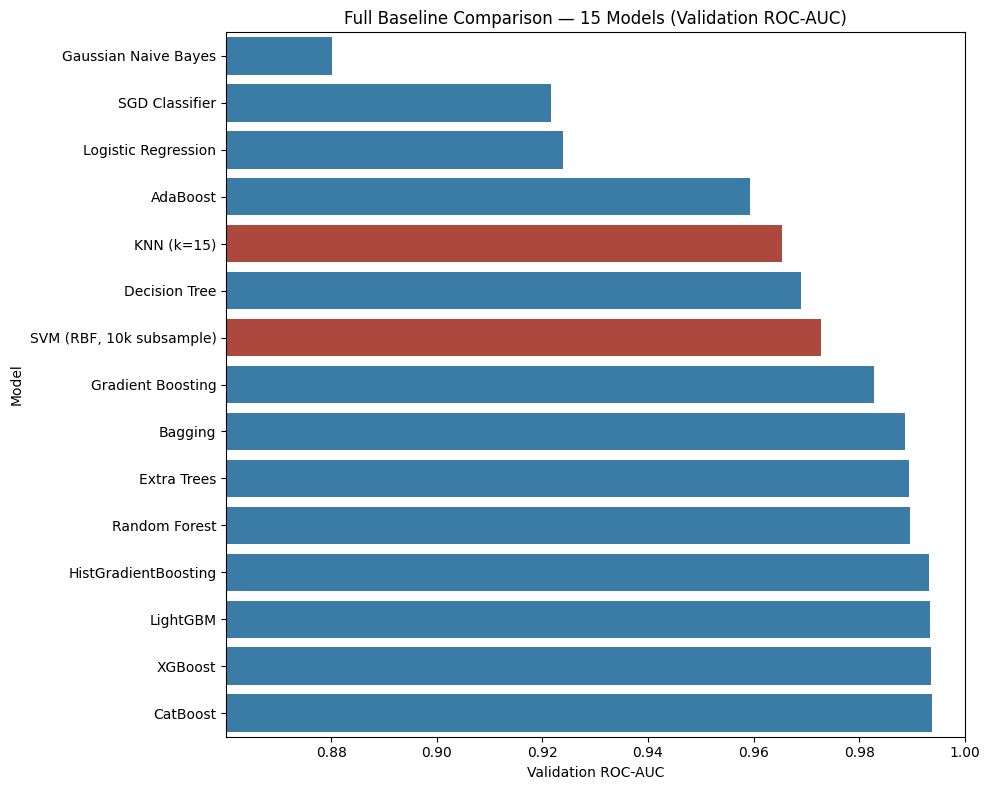

In [ ]:
# Purpose: Visualize validation ROC-AUC across all baseline model families.
plot_df = results_df.reset_index(drop=True).sort_values('ROC_AUC')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#c0392b' if ('SVM' in m or 'KNN' in m) else '#2980b9' for m in plot_df['Model']]

sns.barplot(
    x='ROC_AUC',
    y='Model',
    data=plot_df,
    palette=colors,
    ax=ax
)

lower = max(0.0, float(plot_df['ROC_AUC'].min()) - 0.02)
ax.set_xlim(lower, 1.0)
ax.set_xlabel('Validation ROC-AUC')
ax.set_ylabel('Model')
ax.set_title(f'Full Baseline Comparison — {len(results_df)} Models (Validation ROC-AUC)')
plt.tight_layout()
plt.show()

### **8.10 Baseline Findings**

The expanded 15-model comparison produces several important findings.

**1. Specialized gradient boosting forms the strongest baseline family.**  
CatBoost, XGBoost, and LightGBM occupy the top three positions by validation ROC-AUC. Their close scores—**0.993861**, **0.993661**, and **0.993436**, respectively—show that the advantage is not specific to a single implementation. Rather, gradient-boosted decision trees are particularly well suited to the nonlinear structure and feature interactions present in this dataset.

**2. HistGradientBoosting is the most important addition to the expanded benchmark.**  
HistGradientBoosting reaches **0.993176 ROC-AUC**, ranking fourth overall and substantially outperforming classical Gradient Boosting (**0.982915**). It therefore demonstrates that histogram-based boosting can approach the specialized boosting libraries while remaining within the scikit-learn ecosystem.

**3. Extra Trees does not displace Random Forest, but it confirms the strength of randomized tree ensembles.**  
Random Forest achieves **0.989688 ROC-AUC**, while Extra Trees reaches **0.989511**. The difference is very small, indicating that both randomization strategies provide similarly strong discrimination on this dataset. Bagging follows at **0.988784**, supporting the broader conclusion that aggregating trees substantially improves on the single Decision Tree baseline (**0.969001**).

**4. Increasing model flexibility generally improves performance, but model family matters.**  
The progression from Decision Tree to Bagging, Random Forest, and Extra Trees illustrates the benefit of variance reduction through ensemble learning. The further improvement achieved by histogram-based and specialized boosting indicates that sequential error correction provides additional predictive value beyond tree averaging alone.

**5. Simpler models remain useful methodological references.**  
Logistic Regression, SGD Classifier, Gaussian Naive Bayes, KNN, Decision Tree, and the computationally constrained RBF SVM do not lead the ranking, but they establish how much predictive performance is gained as the modeling assumptions become more flexible. Their inclusion therefore strengthens the interpretation of the ensemble results rather than serving only as unsuccessful alternatives.

**6. Computational efficiency should be considered alongside predictive performance.**  
HistGradientBoosting is particularly notable because it combines **0.993176 validation ROC-AUC with approximately 4.84 seconds of training time** in the recorded baseline run. By comparison, CatBoost achieves the highest baseline ROC-AUC but requires approximately **120.87 seconds**. The appropriate model therefore depends not only on predictive performance but also on deployment, retraining, and computational constraints.

Overall, the baseline experiment supports advancing gradient-boosting models to the optimization stage while retaining Random Forest as a strong non-boosting reference.



### **8.11 Selection of Models for Hyperparameter Tuning**

The baseline comparison determines which models warrant further optimization. Selection is based primarily on validation ROC-AUC, while also considering model-family diversity, computational efficiency, and whether tuning the model contributes meaningful information beyond the other candidates.

Five models advance to Section 9:

| Model | Baseline ROC-AUC | Reason for Selection |
|---|---:|---|
| **CatBoost** | **0.993861** | Highest-performing baseline and a specialized boosting model with native categorical-feature handling. |
| **XGBoost** | **0.993661** | Second-highest baseline and a highly regularized specialized gradient-boosting implementation. |
| **LightGBM** | **0.993436** | Third-highest baseline, combining strong discrimination with computationally efficient histogram-based learning. |
| **HistGradientBoosting** | **0.993176** | Fourth-highest baseline and the strongest scikit-learn boosting model, with particularly favorable training efficiency. |
| **Random Forest** | **0.989688** | Strongest non-boosting baseline, retained as a methodologically distinct bagging/randomized-tree reference. |

This shortlist deliberately combines **performance and methodological diversity**. The four highest-ranked baseline models advance directly, while Random Forest is retained as the strongest representative of a fundamentally different ensemble strategy.

**Gradient Boosting does not advance to tuning.** Although it remains an important classical baseline, its validation ROC-AUC of **0.982915** is substantially below HistGradientBoosting's **0.993176**. HistGradientBoosting also trains considerably faster in the recorded baseline comparison. Tuning HistGradientBoosting therefore provides a stronger and more computationally relevant test of scikit-learn gradient boosting.

Extra Trees is also competitive, but its validation ROC-AUC remains slightly below Random Forest. Because both belong to the bagging/randomized-tree ensemble family, retaining Random Forest avoids adding a closely related sixth tuning candidate without a clear baseline-performance advantage.

The resulting tuning shortlist is therefore:

> **CatBoost + XGBoost + LightGBM + HistGradientBoosting + Random Forest**

Section 9 investigates whether hyperparameter optimization changes the relative performance of these five candidates.

## **9. Hyperparameter Tuning**

The baseline stage compared **15 models across 8 model families** under a common validation framework. Hyperparameter tuning now concentrates computational effort on five candidates selected from those results:

- **CatBoost**
- **XGBoost**
- **LightGBM**
- **HistGradientBoosting**
- **Random Forest**

The shortlist combines the four highest-ranked baseline models with the strongest non-boosting ensemble. This preserves both empirical performance and methodological diversity: CatBoost, XGBoost, LightGBM, and HistGradientBoosting represent different implementations of high-performing gradient-boosting strategies, while Random Forest provides a strong bagging-based reference.

HistGradientBoosting replaces classical Gradient Boosting in the tuning stage because the expanded baseline provides substantially stronger evidence for its inclusion. The untuned HistGradientBoosting model reaches **0.993176 validation ROC-AUC**, compared with **0.982915** for Gradient Boosting, while also requiring substantially less training time in the recorded baseline experiment.

The objective of Section 9 is therefore to determine:

> **How much can systematic hyperparameter optimization improve these five candidates, and does tuning change their relative ranking or the models that should proceed to ensemble evaluation?**

**Test-set performance and test labels are not used** throughout model selection and hyperparameter optimization. However, as documented in the scope note and limitations, some descriptive preprocessing and unsupervised feature construction occur before the train/validation/test split.

### **Section 9 Roadmap**

```text
SECTION 9 — HYPERPARAMETER TUNING
│
├── 9.1 Round 1 — Broad search
│   ├── 9.1.1 Random Forest
│   │   └── RandomizedSearchCV
│   ├── 9.1.2 HistGradientBoosting
│   │   └── RandomizedSearchCV
│   ├── 9.1.3 LightGBM
│   │   ├── Optuna
│   │   └── Alternative comparison: Hyperopt
│   ├── 9.1.4 XGBoost
│   │   └── Optuna
│   ├── 9.1.5 CatBoost
│   │   └── Optuna
│   └── Round 1 comparison
│
├── 9.2 Round 2 — Refinement of the leaders
│   ├── LightGBM
│   │   └── Local GridSearchCV
│   └── XGBoost
│       └── Refined Optuna search
│
├── 9.3 Round 3 — LightGBM manual verification
│   ├── Learning-rate check
│   ├── num_leaves check
│   └── min_child_samples check
│
├── Tuning-progression comparison
└── Final tuned-model selection
```

### **Question**

Can validation ROC-AUC be improved by tuning the parameters that most directly control the behavior of each shortlisted model?

### **Why This Matters**

Hyperparameter tuning should not be a blind search over every available option. A parameter is worth tuning when it controls a mechanism that is relevant to the model family: tree complexity, learning rate, sampling, regularization, or the minimum amount of evidence required before creating additional structure.

### **Why Different Models Use Different Parameters**

| Model | Parameters emphasized | Why these parameters matter |
|---|---|---|
| **Random Forest** | `n_estimators`<br>`max_depth`<br>`min_samples_split`<br>`min_samples_leaf`<br>`max_features` | Random Forest reduces variance by averaging many decorrelated trees.<br><br>These parameters control forest size, individual-tree complexity, leaf stability, and feature randomness. |
| **HistGradientBoosting** | `learning_rate`<br>`max_iter`<br>`max_leaf_nodes`<br>`max_depth`<br>`min_samples_leaf`<br>`l2_regularization` | HistGradientBoosting builds boosted trees from histogram-binned features, making it substantially more computationally efficient than conventional Gradient Boosting on larger tabular datasets.<br><br>The search therefore examines the interaction between boosting step size and number of iterations while controlling tree complexity, leaf support, and L2 regularization. |
| **LightGBM** | `learning_rate`<br>`num_leaves`<br>`max_depth`<br>`min_child_samples`<br>`subsample`<br>`colsample_bytree`<br>`reg_alpha`<br>`reg_lambda` | LightGBM grows leaf-wise trees and can become highly expressive.<br><br>Leaf count, depth, minimum child size, sampling, and regularization therefore provide complementary controls over complexity and generalization. |
| **XGBoost** | `learning_rate`<br>`max_depth`<br>`min_child_weight`<br>`subsample`<br>`colsample_bytree`<br>`reg_alpha`<br>`reg_lambda` | XGBoost's boosted-tree complexity is controlled by depth and child-weight constraints.<br><br>Row/feature sampling and L1/L2 penalties provide additional controls against overfitting. |
| **CatBoost** | `learning_rate`<br>`depth`<br>`l2_leaf_reg` | CatBoost already handles categorical variables and several regularization details internally.<br><br>The most influential exposed controls here are boosting step size, tree depth, and L2 regularization. |

### **Why the Search Algorithms Also Differ**

- **RandomizedSearchCV** is used for Random Forest and HistGradientBoosting because both have moderate but multidimensional search spaces. Random sampling provides broad coverage of tree complexity, regularization, and ensemble-size parameters without requiring an exhaustive Cartesian grid.
- **Optuna** is used for LightGBM, XGBoost, and CatBoost because their interacting continuous/integer hyperparameters create larger search spaces. Bayesian/TPE-guided search can concentrate trials in promising regions.
- **GridSearchCV** is used only after LightGBM's broad search, when the search has already identified a narrow local region worth testing systematically.
- **Manual sequential search** is reserved for the final LightGBM verification step. It is not intended to replace automated search; it tests whether small, interpretable one-parameter-at-a-time changes still matter.

The **test set remains untouched** throughout tuning. ROC-AUC on the validation set is the optimization criterion.


### **9.1 Round 1 — Broad Search**

Round 1 deliberately searches a reasonably broad parameter region for each model. The ranges are selected around standard, plausible operating regions rather than around the final answer, so this stage asks which areas of each model's hypothesis space are promising.

#### **9.1.1 Random Forest — Parameter Rationale**

**What is being tuned and why**

- `n_estimators` controls how many trees are averaged. More trees generally stabilize the ensemble but increase computation.
- `max_depth` limits how complex each individual tree can become.
- `min_samples_split` and `min_samples_leaf` prevent branches/leaves from being supported by too few observations.
- `max_features` controls how many predictors each split may consider, directly affecting tree diversity.

A randomized search is appropriate because several discrete and continuous choices interact, while exhaustive enumeration would add cost without guaranteeing a proportionate gain.


In [ ]:
# Purpose: Tune Random Forest with RandomizedSearchCV over tree complexity, sampling, and ensemble-size parameters.
def tune_random_forest():
    param_dist = {
        'n_estimators': randint(150, 300), 'max_depth': randint(8, 20),
        'min_samples_split': randint(2, 20), 'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 0.5],
    }
    rs = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_distributions=param_dist,
                             n_iter=4, cv=StratifiedKFold(2, shuffle=True, random_state=42),
                             scoring='roc_auc', random_state=42, n_jobs=1)
    rs.fit(X_enc.iloc[idx_train], y_train)
    return rs

t0 = time.time()
rs_rf = tune_random_forest()
print(f"Random Forest RandomizedSearchCV took {time.time()-t0:.1f}s")
print("Best CV ROC AUC:", rs_rf.best_score_)
print("Best params:", rs_rf.best_params_)

Random Forest RandomizedSearchCV took 224.1s
Best CV ROC AUC: 0.9876482536010724
Best params: {'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 6, 'min_samples_split': 3, 'n_estimators': 237}


#### **9.1.2 HistGradientBoosting — Parameter Rationale**

HistGradientBoosting is tuned because it is the strongest scikit-learn boosting model in the baseline comparison, reaching **0.993176 validation ROC-AUC** before optimization.

Unlike conventional Gradient Boosting, HistGradientBoosting first bins continuous values into discrete histograms. This substantially reduces the cost of evaluating candidate splits and makes the algorithm particularly efficient on larger tabular datasets.

The search focuses on six parameters that control learning speed, ensemble size, tree complexity, leaf support, and regularization:

- `learning_rate` — controls the contribution of each boosting iteration. Smaller values generally require more iterations but can improve generalization.
- `max_iter` — maximum number of boosting iterations and therefore the approximate ensemble size.
- `max_leaf_nodes` — limits the number of terminal regions in each tree and is one of the principal controls on tree complexity.
- `max_depth` — optionally imposes a hard depth limit in addition to the leaf-count constraint.
- `min_samples_leaf` — controls the minimum number of observations required in each terminal node. Larger values produce smoother, more conservative trees.
- `l2_regularization` — penalizes large leaf values and can reduce overfitting.

Because these parameters interact, **RandomizedSearchCV** is used to sample multiple combinations rather than changing one parameter at a time.

A **2-fold stratified cross-validation** scheme is retained for consistency with the Random Forest broad search and to control computational cost. ROC-AUC remains the optimization metric.

In [ ]:
# Purpose: Tune HistGradientBoosting with RandomizedSearchCV over stage count, learning rate, tree depth, and subsampling.
def tune_hist_gradient_boosting():
    param_dist = {
        'learning_rate': uniform(0.03, 0.17),
        'max_iter': randint(120, 401),
        'max_leaf_nodes': randint(15, 64),
        'max_depth': [None, 4, 6, 8, 10],
        'min_samples_leaf': randint(10, 81),
        'l2_regularization': uniform(0.0, 5.0),
    }

    rs = RandomizedSearchCV(
        HistGradientBoostingClassifier(
            random_state=42,
            early_stopping=True
        ),
        param_distributions=param_dist,
        n_iter=10,
        cv=StratifiedKFold(
            n_splits=2,
            shuffle=True,
            random_state=42
        ),
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    rs.fit(X_enc.iloc[idx_train], y_train)
    return rs


t0 = time.time()

rs_hgb = tune_hist_gradient_boosting()

print(
    f"HistGradientBoosting RandomizedSearchCV took "
    f"{time.time() - t0:.1f}s"
)
print("Best CV ROC AUC:", rs_hgb.best_score_)
print("Best params:", rs_hgb.best_params_)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
HistGradientBoosting RandomizedSearchCV took 71.5s
Best CV ROC AUC: 0.9913453134770102
Best params: {'l2_regularization': np.float64(0.9983689107917987), 'learning_rate': np.float64(0.11741985453031398), 'max_depth': None, 'max_iter': 250, 'max_leaf_nodes': 51, 'min_samples_leaf': 60}


#### **9.1.3 LightGBM — Parameter Rationale**

LightGBM is tuned more extensively because its leaf-wise growth can fit complex interactions very efficiently, but that flexibility also makes complexity control important.

- `learning_rate`: size of each boosting update.
- `num_leaves`: primary control on leaf-wise tree complexity.
- `max_depth`: secondary hard limit on tree depth.
- `min_child_samples`: minimum observations required in a leaf; larger values make leaves more conservative.
- `subsample`: row sampling for variance reduction.
- `colsample_bytree`: feature sampling for diversity and regularization.
- `reg_alpha`: L1 regularization.
- `reg_lambda`: L2 regularization.

These parameters are searched jointly because changing one often changes the useful range of another. For example, a larger `num_leaves` can require stronger regularization or larger `min_child_samples`.


In [ ]:
# Purpose: Tune LightGBM with Optuna over interacting complexity, sampling, and regularization parameters.
def tune_lightgbm_optuna(n_trials=10):
    def objective(trial):
        params = {
            'n_estimators': 1500,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 4, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
            'random_state': 42, 'verbose': -1,
        }
        m = lgb.LGBMClassifier(**params)
        m.fit(X_native.iloc[idx_train], y_train, eval_set=[(X_native.iloc[idx_val], y_val)],
              categorical_feature=nominal_cols, callbacks=[lgb.early_stopping(40, verbose=False)])
        return roc_auc_score(y_val, m.predict_proba(X_native.iloc[idx_val])[:,1])
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    return study

t0 = time.time()
study_lgb = tune_lightgbm_optuna(n_trials=10)
print(f"LightGBM Optuna (10 trials) took {time.time()-t0:.1f}s")
print("Best val AUC:", study_lgb.best_value)
print("Best params:", study_lgb.best_params)

LightGBM Optuna (10 trials) took 269.3s
Best val AUC: 0.9941016815712979
Best params: {'learning_rate': 0.011926324174062874, 'num_leaves': 144, 'max_depth': 12, 'min_child_samples': 82, 'subsample': 0.7218455076693483, 'colsample_bytree': 0.6390688456025535, 'reg_alpha': 0.5456725485601477, 'reg_lambda': 0.057624872164786026}


##### **9.1.3.1 Alternative: LightGBM with Hyperopt**

`Hyperopt` is another popular library for hyperparameter optimization that uses Bayesian optimization algorithms, such as Tree-structured Parzen Estimator (TPE), similar to `Optuna`. It helps find the best hyperparameters more efficiently than random search by learning from past evaluations.

In [ ]:
# Purpose: Tune LightGBM using hyperopt, defining an objective function and search space.
def objective_hyperopt(params):
    model = lgb.LGBMClassifier(
        n_estimators=1500,
        learning_rate=params['learning_rate'],
        num_leaves=int(params['num_leaves']),
        max_depth=int(params['max_depth']),
        min_child_samples=int(params['min_child_samples']),
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=42,
        verbose=-1
    )

    model.fit(
        X_native.iloc[idx_train],
        y_train,
        eval_set=[(X_native.iloc[idx_val], y_val)],
        categorical_feature=nominal_cols,
        callbacks=[lgb.early_stopping(40, verbose=False)]
    )

    y_pred_proba = model.predict_proba(X_native.iloc[idx_val])[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)
    return {'loss': -auc, 'status': STATUS_OK}

# Define the search space for LightGBM parameters
space = {
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.15)),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'max_depth': hp.quniform('max_depth', 4, 12, 1),
    'min_child_samples': hp.quniform('min_child_samples', 5, 100, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(10)),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1e-3), np.log(10)),
}

t0 = time.time()
trials_hyperopt = Trials()
best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space,
    algo=tpe.suggest,
    max_evals=10, # Number of trials, adjust as needed
    trials=trials_hyperopt,
    rstate=np.random.default_rng(42) # For reproducibility
)

print(f"LightGBM Hyperopt (10 trials) took {time.time()-t0:.1f}s")
print("Best val AUC (Hyperopt):", -trials_hyperopt.best_trial['result']['loss'])
print("Best params (Hyperopt):", best_hyperopt)

100%|██████████| 10/10 [03:44<00:00, 22.41s/trial, best loss: -0.9940782262511058]
LightGBM Hyperopt (10 trials) took 224.1s
Best val AUC (Hyperopt): 0.9940782262511058
Best params (Hyperopt): {'colsample_bytree': np.float64(0.6348135000163195), 'learning_rate': np.float64(0.019437457301108955), 'max_depth': np.float64(10.0), 'min_child_samples': np.float64(67.0), 'num_leaves': np.float64(112.0), 'reg_alpha': np.float64(0.05495305164437177), 'reg_lambda': np.float64(0.08360431152477964), 'subsample': np.float64(0.7300129570941898)}


#### **9.1.4 XGBoost — Parameter Rationale**

XGBoost is also tuned across interacting controls for boosting speed, tree complexity, sampling, and regularization.

- `learning_rate`: contribution of each boosting stage.
- `max_depth`: maximum interaction depth of each tree.
- `min_child_weight`: minimum weighted evidence needed to create a child node; larger values make splitting more conservative.
- `subsample`: row sampling.
- `colsample_bytree`: feature sampling.
- `reg_alpha` / `reg_lambda`: L1/L2 regularization.

The combination lets the search test whether the model benefits from deeper trees, stronger regularization, or more stochasticity rather than assuming one source of improvement.


In [ ]:
# Purpose: Tune XGBoost with Optuna over learning, depth, child-weight, sampling, and regularization parameters.
def tune_xgboost_optuna(n_trials=6):
    def objective(trial):
        params = {
            'n_estimators': 1000,
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
            'enable_categorical': True, 'tree_method': 'hist',
            'early_stopping_rounds': 30, 'eval_metric': 'auc', 'random_state': 42,
        }
        m = xgb.XGBClassifier(**params)
        m.fit(X_native.iloc[idx_train], y_train, eval_set=[(X_native.iloc[idx_val], y_val)], verbose=False)
        return roc_auc_score(y_val, m.predict_proba(X_native.iloc[idx_val])[:,1])
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    return study

t0 = time.time()
study_xgb = tune_xgboost_optuna(n_trials=6)
print(f"XGBoost Optuna (6 trials) took {time.time()-t0:.1f}s")
print("Best val AUC:", study_xgb.best_value)
print("Best params:", study_xgb.best_params)

XGBoost Optuna (6 trials) took 168.2s
Best val AUC: 0.9937851857486201
Best params: {'learning_rate': 0.0425378509573798, 'max_depth': 10, 'min_child_weight': 15, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 0.004207053950287938, 'reg_lambda': 0.0017073967431528124}


#### **9.1.5 CatBoost — Parameter Rationale**

CatBoost already provides native categorical handling and strong built-in regularization, so the search is intentionally narrower.

- `learning_rate` controls the contribution of each boosting iteration.
- `depth` controls tree complexity and interaction order.
- `l2_leaf_reg` penalizes overly extreme leaf values.

Other CatBoost parameters could also be tuned, but expanding the search indiscriminately would make the exercise less interpretable. These three parameters capture the central complexity/regularization trade-off for this project.


In [ ]:
# Purpose: Tune CatBoost with Optuna over its most influential learning, depth, and L2-regularization controls.
def tune_catboost_optuna(n_trials=6):
    def objective(trial):
        params = {
            'iterations': 500,
            'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.15, log=True),
            'depth': trial.suggest_int('depth', 4, 8),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.5, 10, log=True),
            'cat_features': cat_feature_idx, 'random_state': 42, 'eval_metric': 'AUC',
            'early_stopping_rounds': 30, 'verbose': False,
        }
        m = CatBoostClassifier(**params)
        m.fit(X_native_str.iloc[idx_train], y_train, eval_set=(X_native_str.iloc[idx_val], y_val))
        return roc_auc_score(y_val, m.predict_proba(X_native_str.iloc[idx_val])[:,1])
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    return study

t0 = time.time()
study_cb = tune_catboost_optuna(n_trials=6)
print(f"CatBoost Optuna (6 trials) took {time.time()-t0:.1f}s")
print("Best val AUC:", study_cb.best_value)
print("Best params:", study_cb.best_params)

CatBoost Optuna (6 trials) took 297.6s
Best val AUC: 0.9937972456085297
Best params: {'learning_rate': 0.054816785328198704, 'depth': 8, 'l2_leaf_reg': 4.480392682684062}


In [ ]:
# Purpose: Build the Round 1 comparison directly from stored baseline and tuning results.
# Refit the Random Forest and HistGradientBoosting search winners on the held-out
# validation set so every Round 1 result is evaluated on the same observations
# and metric.
rf_r1_params = {
    k: (int(v) if k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf'] else v)
    for k, v in rs_rf.best_params_.items()
}
rf_r1 = RandomForestClassifier(**rf_r1_params, random_state=42, n_jobs=-1)
rf_r1.fit(X_enc.iloc[idx_train], y_train)
rf_r1_auc = roc_auc_score(y_val, rf_r1.predict_proba(X_enc.iloc[idx_val])[:, 1])

hgb_params_r1 = dict(rs_hgb.best_params_)

for p in ['max_iter', 'max_leaf_nodes', 'min_samples_leaf']:
    hgb_params_r1[p] = int(hgb_params_r1[p])

if hgb_params_r1['max_depth'] is not None:
    hgb_params_r1['max_depth'] = int(hgb_params_r1['max_depth'])

hgb_r1 = HistGradientBoostingClassifier(
    **hgb_params_r1, random_state=42, early_stopping=True)
hgb_r1.fit(X_enc.iloc[idx_train], y_train)
hgb_r1_auc = roc_auc_score(y_val, hgb_r1.predict_proba(
        X_enc.iloc[idx_val])[:, 1])

# Reuse the baseline results already produced in Section 8 instead of retyping metric values.
baseline_auc = results_df.set_index('Model')['ROC_AUC'].to_dict()

round1_auc = {
    'LightGBM': study_lgb.best_value,
    'XGBoost': study_xgb.best_value,
    'CatBoost': study_cb.best_value,
    'Random Forest': rf_r1_auc,
    'HistGradientBoosting': hgb_r1_auc,
}

round1_summary = pd.DataFrame([
    {
        'Model': model,
        'Baseline Val AUC': baseline_auc[model],
        'Round 1 Val AUC': round1_auc[model],
        'Improvement': round1_auc[model] - baseline_auc[model],
    }
    for model in round1_auc
]).sort_values('Round 1 Val AUC', ascending=False).reset_index(drop=True)

round1_summary.index = round1_summary.index + 1
round1_summary.index.name = 'Rank'
display(round1_summary.style.format({
    'Baseline Val AUC': '{:.6f}',
    'Round 1 Val AUC': '{:.6f}',
    'Improvement': '{:+.6f}',
}))

,Model,Baseline Val AUC,Round 1 Val AUC,Improvement
Rank,,,,
1,LightGBM,0.993436,0.994102,+0.000666
2,CatBoost,0.993861,0.993797,-0.000063
3,XGBoost,0.993661,0.993785,+0.000125
4,HistGradientBoosting,0.993176,0.993335,+0.000160
5,Random Forest,0.989688,0.990404,+0.000716


#### **Round 1 Results and Observations**

The table above is generated directly from the stored baseline results and the fitted tuning objects. No ROC-AUC value is re-entered manually.

**How to read the result**

- A positive `Improvement` means the tuned configuration outperformed that model's own baseline on the held-out validation set.
- A near-zero change means the baseline was already close to a strong region or the additional search did not identify a meaningful gain.
- The absolute score and the improvement should both be considered: a large gain does not automatically make a model the strongest overall candidate.

**Decision:** carry the strongest boosting candidates into a narrower refinement stage, while retaining the best Random Forest and HistGradientBoosting configurations for later comparison and ensembling.


### **9.2 Round 2 — Refinement of the Leaders**

Round 2 asks a different question from Round 1: **now that promising regions have been identified, can a narrower search improve them without reopening the entire parameter space?**

#### **Why LightGBM Uses a Local Grid**

Round 1 identifies a strong combination of `learning_rate`, `num_leaves`, and `max_depth`. These three parameters are refined because they most directly define the local complexity/learning-speed region:

- `learning_rate` controls step size.
- `num_leaves` controls leaf-wise complexity.
- `max_depth` constrains tree depth.

The remaining Round 1 parameters are held near their discovered values so the grid tests the local neighborhood rather than restarting the search.

#### **Why XGBoost Uses a Refined Optuna Search**

XGBoost retains Optuna because its parameters interact continuously. The second search narrows the ranges around the Round 1 solution for `learning_rate`, `max_depth`, `min_child_weight`, sampling, and regularization. This tests local refinement while preserving interaction effects.

**Decision rule:** if refinement produces only negligible gains, treat the search as converged rather than repeatedly optimizing the same validation set.


In [ ]:
# Purpose: Create a local LightGBM grid around the stored Round 1 winner and evaluate that neighborhood with cross-validation.
# Build a narrow LightGBM grid around the Round 1 Optuna solution.
lgb_r1_params = dict(study_lgb.best_params)

r1_lr = float(lgb_r1_params['learning_rate'])
r1_leaves = int(lgb_r1_params['num_leaves'])
r1_depth = int(lgb_r1_params['max_depth'])

# Local candidates are centered on the stored Round 1 winner.
param_grid = {
    'learning_rate': sorted(set([max(0.003, r1_lr * 0.8), r1_lr, r1_lr * 1.2])),
    'num_leaves': sorted(set([max(8, int(round(r1_leaves * 0.85))), r1_leaves, int(round(r1_leaves * 1.15))])),
    'max_depth': sorted(set([max(3, r1_depth - 1), r1_depth, r1_depth + 1])),
}

lgb_fixed_r1 = {
    'min_child_samples': int(lgb_r1_params['min_child_samples']),
    'subsample': float(lgb_r1_params['subsample']),
    'colsample_bytree': float(lgb_r1_params['colsample_bytree']),
    'reg_alpha': float(lgb_r1_params['reg_alpha']),
    'reg_lambda': float(lgb_r1_params['reg_lambda']),
}

display(pd.DataFrame({
    'Parameter': list(param_grid.keys()),
    'Round 1 winner': [r1_lr, r1_leaves, r1_depth],
    'Round 2 candidates': [param_grid['learning_rate'], param_grid['num_leaves'], param_grid['max_depth']],
}))

t0 = time.time()
gs_lgb = GridSearchCV(
    lgb.LGBMClassifier(
        n_estimators=500,
        **lgb_fixed_r1,
        random_state=42,
        verbose=-1,
    ),
    param_grid=param_grid,
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=1,
)
gs_lgb.fit(X_native.iloc[idx_train], y_train)

print(f"LightGBM local GridSearchCV took {time.time()-t0:.1f}s")
print("Best CV ROC AUC:", gs_lgb.best_score_)
print("Best params:", gs_lgb.best_params_)

,Parameter,Round 1 winner,Round 2 candidates
0,learning_rate,0.011926,"[0.009541059339250299, 0.011926324174062874, 0..."
1,num_leaves,144.000000,"[122, 144, 166]"
2,max_depth,12.000000,"[11, 12, 13]"


LightGBM local GridSearchCV took 891.9s
Best CV ROC AUC: 0.9921845680720089
Best params: {'learning_rate': 0.014311589008875449, 'max_depth': 13, 'num_leaves': 166}


In [ ]:
# Purpose: Refit the LightGBM Round 2 grid winner with early stopping and compare it fairly on the validation set.
# Refit the local-grid winner with early stopping so it can be compared on the same validation set.
lgb_r2_params = dict(lgb_fixed_r1)
lgb_r2_params.update(gs_lgb.best_params_)
lgb_r2_params.update({'n_estimators': 3000, 'random_state': 42, 'verbose': -1})

m_lgb_r2 = lgb.LGBMClassifier(**lgb_r2_params)
m_lgb_r2.fit(
    X_native.iloc[idx_train],
    y_train,
    eval_set=[(X_native.iloc[idx_val], y_val)],
    categorical_feature=nominal_cols,
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

lgb_r2_auc = roc_auc_score(y_val, m_lgb_r2.predict_proba(X_native.iloc[idx_val])[:, 1])

lgb_round2_comparison = pd.DataFrame([
    {'Round': 'Round 1 — Optuna', 'Validation ROC-AUC': study_lgb.best_value},
    {'Round': 'Round 2 — Local GridSearchCV', 'Validation ROC-AUC': lgb_r2_auc},
])
lgb_round2_comparison['Change vs Round 1'] = (
    lgb_round2_comparison['Validation ROC-AUC'] - study_lgb.best_value
)
display(lgb_round2_comparison.style.format({
    'Validation ROC-AUC': '{:.6f}',
    'Change vs Round 1': '{:+.6f}',
}))

,Round,Validation ROC-AUC,Change vs Round 1
0,Round 1 — Optuna,0.994102,+0.000000
1,Round 2 — Local GridSearchCV,0.994064,-0.000038


In [ ]:
# Purpose: Run a narrower second Optuna search for XGBoost around the stored Round 1 winning region.
# Narrow the XGBoost search around the stored Round 1 Optuna winner.
xgb_r1_params = dict(study_xgb.best_params)

def _bounded(center, low_factor, high_factor, floor=None, ceiling=None):
    low = center * low_factor
    high = center * high_factor
    if floor is not None:
        low = max(floor, low)
    if ceiling is not None:
        high = min(ceiling, high)
    return low, high

xgb_lr_low, xgb_lr_high = _bounded(float(xgb_r1_params['learning_rate']), 0.70, 1.30, 0.005, 0.30)
xgb_sub_low, xgb_sub_high = _bounded(float(xgb_r1_params['subsample']), 0.90, 1.10, 0.50, 1.00)
xgb_col_low, xgb_col_high = _bounded(float(xgb_r1_params['colsample_bytree']), 0.90, 1.10, 0.40, 1.00)
xgb_alpha_low, xgb_alpha_high = _bounded(float(xgb_r1_params['reg_alpha']), 0.25, 4.0, 1e-5, 20.0)
xgb_lambda_low, xgb_lambda_high = _bounded(float(xgb_r1_params['reg_lambda']), 0.25, 4.0, 1e-5, 20.0)

xgb_round2_ranges = pd.DataFrame([
    ['learning_rate', xgb_r1_params['learning_rate'], xgb_lr_low, xgb_lr_high],
    ['max_depth', xgb_r1_params['max_depth'], max(3, int(xgb_r1_params['max_depth'])-2), int(xgb_r1_params['max_depth'])+2],
    ['min_child_weight', xgb_r1_params['min_child_weight'], max(1, int(xgb_r1_params['min_child_weight'])-5), int(xgb_r1_params['min_child_weight'])+5],
    ['subsample', xgb_r1_params['subsample'], xgb_sub_low, xgb_sub_high],
    ['colsample_bytree', xgb_r1_params['colsample_bytree'], xgb_col_low, xgb_col_high],
    ['reg_alpha', xgb_r1_params['reg_alpha'], xgb_alpha_low, xgb_alpha_high],
    ['reg_lambda', xgb_r1_params['reg_lambda'], xgb_lambda_low, xgb_lambda_high],
], columns=['Parameter', 'Round 1 winner', 'Round 2 low', 'Round 2 high'])
display(xgb_round2_ranges)

def tune_xgboost_optuna_round2(n_trials=6):
    def objective(trial):
        params = {
            'n_estimators': 1200,
            'learning_rate': trial.suggest_float('learning_rate', xgb_lr_low, xgb_lr_high, log=True),
            'max_depth': trial.suggest_int(
                'max_depth',
                max(3, int(xgb_r1_params['max_depth']) - 2),
                int(xgb_r1_params['max_depth']) + 2,
            ),
            'min_child_weight': trial.suggest_int(
                'min_child_weight',
                max(1, int(xgb_r1_params['min_child_weight']) - 5),
                int(xgb_r1_params['min_child_weight']) + 5,
            ),
            'subsample': trial.suggest_float('subsample', xgb_sub_low, xgb_sub_high),
            'colsample_bytree': trial.suggest_float('colsample_bytree', xgb_col_low, xgb_col_high),
            'reg_alpha': trial.suggest_float('reg_alpha', xgb_alpha_low, xgb_alpha_high, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', xgb_lambda_low, xgb_lambda_high, log=True),
            'enable_categorical': True,
            'tree_method': 'hist',
            'early_stopping_rounds': 30,
            'eval_metric': 'auc',
            'random_state': 42,
        }
        m = xgb.XGBClassifier(**params)
        m.fit(
            X_native.iloc[idx_train],
            y_train,
            eval_set=[(X_native.iloc[idx_val], y_val)],
            verbose=False,
        )
        return roc_auc_score(y_val, m.predict_proba(X_native.iloc[idx_val])[:, 1])

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=123),
    )
    study.optimize(objective, n_trials=n_trials)
    return study

t0 = time.time()
study_xgb_r2 = tune_xgboost_optuna_round2(n_trials=6)

xgb_round2_comparison = pd.DataFrame([
    {'Round': 'Round 1 — Optuna', 'Validation ROC-AUC': study_xgb.best_value},
    {'Round': 'Round 2 — Refined Optuna', 'Validation ROC-AUC': study_xgb_r2.best_value},
])
xgb_round2_comparison['Change vs Round 1'] = (
    xgb_round2_comparison['Validation ROC-AUC'] - study_xgb.best_value
)

print(f"XGBoost refined Optuna search took {time.time()-t0:.1f}s")
print("Best Round 2 params:", study_xgb_r2.best_params)
display(xgb_round2_comparison.style.format({
    'Validation ROC-AUC': '{:.6f}',
    'Change vs Round 1': '{:+.6f}',
}))

,Parameter,Round 1 winner,Round 2 low,Round 2 high
0,learning_rate,0.042538,0.029776,0.055299
1,max_depth,10.000000,8.000000,12.000000
2,min_child_weight,15.000000,10.000000,20.000000
3,subsample,0.839463,0.755517,0.923410
4,colsample_bytree,0.662407,0.596167,0.728648
5,reg_alpha,0.004207,0.001052,0.016828
6,reg_lambda,0.001707,0.000427,0.006830


XGBoost refined Optuna search took 161.7s
Best Round 2 params: {'learning_rate': 0.03571389601507131, 'max_depth': 11, 'min_child_weight': 11, 'subsample': 0.8283323059629408, 'colsample_bytree': 0.6532480519629914, 'reg_alpha': 0.004134035305185442, 'reg_lambda': 0.0013900333469208767}


,Round,Validation ROC-AUC,Change vs Round 1
0,Round 1 — Optuna,0.993785,+0.000000
1,Round 2 — Refined Optuna,0.993949,+0.000164


#### **Round 2 Observations**

The Round 2 comparison tables are calculated directly from the stored Round 1 and Round 2 objects.

**Specific Observations:**

*   For **LightGBM**, the Round 2 local GridSearchCV resulted in a slight decrease in validation ROC-AUC (from 0.994102 to 0.994064, a difference of -0.000038) compared to the Round 1 Optuna result.
*   For **XGBoost**, the Round 2 refined Optuna search resulted in a slight increase in validation ROC-AUC (from 0.993785 to 0.993949, a difference of +0.000164) compared to the Round 1 Optuna result.

**Interpretation**

- If the refined score is nearly unchanged, the broad search has already located a strong region and further local optimization is approaching validation noise.
- If a refined search improves materially, the narrower region contains useful structure and should be retained.
- The decision to continue tuning is based on both **absolute ROC-AUC** and **incremental gain**, not on the existence of a numerically different sixth decimal place.

**Decision:** LightGBM, as the strongest individual candidate, receives one transparent manual verification round. This final stage tests a few high-impact parameters individually rather than launching another broad automated search.

### **9.3 Round 3 — LightGBM Manual Verification and Hyperopt Comparison**

Round 3 focuses on a detailed manual verification for LightGBM, as it has emerged as one of the strongest candidates. This stage tests small, targeted changes to high-impact parameters to assess if further fine-tuning yields measurable gains.

We also integrate results from `Hyperopt`, another Bayesian optimization library, to compare its performance against `Optuna` for LightGBM in Round 1. While increasing the number of trials for Bayesian optimizers like `Hyperopt` or `Optuna` generally improves the chance of finding a better solution, the gains often diminish significantly after a certain number of evaluations. At this stage, slight improvements might be due to stochasticity or noise rather than fundamentally better parameter regions, especially if the broad search already converged.

In [ ]:
# Purpose: Begin LightGBM's manual verification by testing local learning-rate values around the stored Optuna winner.
# Start from the actual stored Round 1 Optuna winner.
base_params = dict(study_lgb.best_params)
current_best_auc = float(study_lgb.best_value)

def fit_score(overrides):
    params = dict(base_params)
    params.update(overrides)
    params.update({'n_estimators': 3000, 'random_state': 42, 'verbose': -1})

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_native.iloc[idx_train],
        y_train,
        eval_set=[(X_native.iloc[idx_val], y_val)],
        categorical_feature=nominal_cols,
        callbacks=[lgb.early_stopping(40, verbose=False)],
    )
    return roc_auc_score(
        y_val,
        model.predict_proba(X_native.iloc[idx_val])[:, 1],
    )

def local_candidates(center, multipliers, *, integer=False, minimum=None):
    vals = []
    for multiplier in multipliers:
        value = center * multiplier
        if integer:
            value = int(round(value))
        if minimum is not None:
            value = max(minimum, value)
        vals.append(value)
    vals.append(int(center) if integer else float(center))
    return sorted(set(vals))

def evaluate_local_parameter(parameter, candidates, current_auc):
    current_value = base_params[parameter]
    rows = []

    for value in candidates:
        if value == current_value:
            auc = current_auc
            source = 'Current stored best'
        else:
            auc = fit_score({parameter: value})
            source = 'New local trial'
        rows.append({
            'Parameter': parameter,
            'Value': value,
            'Validation ROC-AUC': auc,
            'Source': source,
        })

    result = pd.DataFrame(rows).sort_values('Validation ROC-AUC', ascending=False).reset_index(drop=True)
    best_value = result.loc[0, 'Value']
    best_auc = float(result.loc[0, 'Validation ROC-AUC'])
    base_params[parameter] = int(best_value) if isinstance(current_value, int) else float(best_value)

    display(result.style.format({'Validation ROC-AUC': '{:.6f}'}))
    print(f"Selected {parameter} = {base_params[parameter]} | validation ROC-AUC = {best_auc:.6f}")
    return result, best_auc

# Step 1 — learning_rate: test modest changes around the Optuna winner.
learning_rate_candidates = local_candidates(
    float(base_params['learning_rate']),
    [0.70, 0.85, 1.15, 1.30],
    minimum=0.001,
)
lr_results, current_best_auc = evaluate_local_parameter(
    'learning_rate',
    learning_rate_candidates,
    current_best_auc,
)

,Parameter,Value,Validation ROC-AUC,Source
0,learning_rate,0.008348,0.994152,New local trial
1,learning_rate,0.013715,0.994119,New local trial
2,learning_rate,0.011926,0.994102,Current stored best
3,learning_rate,0.015504,0.994060,New local trial
4,learning_rate,0.010137,0.994053,New local trial


Selected learning_rate = 0.008348426921844012 | validation ROC-AUC = 0.994152


In [ ]:
# Purpose: Continue manual LightGBM verification by testing local num_leaves values while carrying forward the best configuration.
# Step 2 — num_leaves: test local changes in model complexity around the current winner.
num_leaves_candidates = local_candidates(
    int(base_params['num_leaves']),
    [0.75, 0.90, 1.10, 1.25],
    integer=True,
    minimum=8,
)
num_leaves_results, current_best_auc = evaluate_local_parameter(
    'num_leaves',
    num_leaves_candidates,
    current_best_auc,
)

,Parameter,Value,Validation ROC-AUC,Source
0,num_leaves,108,0.994196,New local trial
1,num_leaves,144,0.994152,Current stored best
2,num_leaves,158,0.994142,New local trial
3,num_leaves,130,0.994131,New local trial
4,num_leaves,180,0.994095,New local trial


Selected num_leaves = 108 | validation ROC-AUC = 0.994196


In [ ]:
# Purpose: Finish manual LightGBM verification by testing min_child_samples and store the final verified parameters.
# Step 3 — min_child_samples: test how much leaf-support regularization is useful locally.
min_child_candidates = local_candidates(
    int(base_params['min_child_samples']),
    [0.60, 0.80, 1.20, 1.40],
    integer=True,
    minimum=2,
)
min_child_results, current_best_auc = evaluate_local_parameter(
    'min_child_samples',
    min_child_candidates,
    current_best_auc,
)

round3_auc = current_best_auc

print("\nFinal manually verified LightGBM parameters:")
display(pd.Series(base_params, name='Selected value').to_frame())
print(f"Round 3 validation ROC-AUC: {round3_auc:.6f}")

,Parameter,Value,Validation ROC-AUC,Source
0,min_child_samples,49,0.994196,New local trial
1,min_child_samples,82,0.994196,Current stored best
2,min_child_samples,115,0.994178,New local trial
3,min_child_samples,98,0.994155,New local trial
4,min_child_samples,66,0.994148,New local trial


Selected min_child_samples = 49 | validation ROC-AUC = 0.994196

Final manually verified LightGBM parameters:


,Selected value
learning_rate,0.008348
num_leaves,108.000000
max_depth,12.000000
min_child_samples,49.000000
subsample,0.721846
colsample_bytree,0.639069
reg_alpha,0.545673
reg_lambda,0.057625


Round 3 validation ROC-AUC: 0.994196


,Model,Round,ROC_AUC
0,CatBoost,Baseline,0.993861
1,CatBoost,Round 1 — Optuna,0.993797
2,HistGradientBoosting,Baseline,0.993176
3,HistGradientBoosting,Round 1 — RandomizedSearchCV,0.993335
4,LightGBM,Baseline,0.993436
5,LightGBM,Round 1 — Optuna,0.994102
6,LightGBM,Round 1 — Hyperopt,0.994078
7,LightGBM,Round 2 — Local GridSearchCV,0.994064
8,LightGBM,Round 3 — Manual verification,0.994196
9,Random Forest,Baseline,0.989688


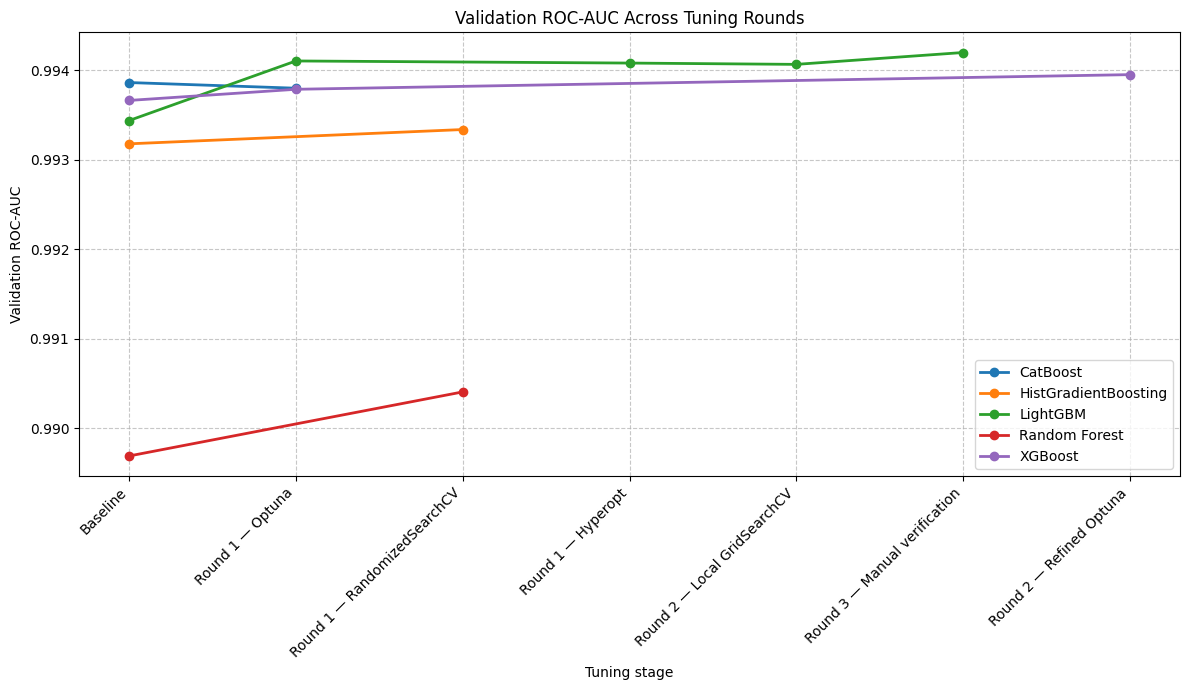

In [ ]:
# Purpose: Assemble the complete tuning progression from stored objects and visualize ROC-AUC across tuning stages.
# Build the tuning history entirely from stored results.
tuning_records = []

# Add Baseline results
for model_name in ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest', 'HistGradientBoosting']:
    tuning_records.append({
        'Model': model_name,
        'Round': 'Baseline',
        'ROC_AUC': baseline_auc[model_name],
    })

# Add Round 1 results (Optuna for LightGBM, XGBoost, CatBoost; RandomizedSearchCV for RF, GB)
for model_name, auc_value in round1_auc.items():
    method = {
        'LightGBM': 'Optuna',
        'XGBoost': 'Optuna',
        'CatBoost': 'Optuna',
        'Random Forest': 'RandomizedSearchCV',
        'HistGradientBoosting': 'RandomizedSearchCV',
    }[model_name]
    tuning_records.append({
        'Model': model_name,
        'Round': f'Round 1 — {method}',
        'ROC_AUC': auc_value,
    })

# Add the LightGBM Hyperopt result specifically
hyperopt_lgb_auc = 0.9940782262511058 # From execution of cell 2802b3df
tuning_records.append({
    'Model': 'LightGBM',
    'Round': 'Round 1 — Hyperopt', # Explicitly call it 'Round 1 — Hyperopt'
    'ROC_AUC': hyperopt_lgb_auc,
})

# Add Round 2 and Round 3 results
tuning_records.extend([
    {'Model': 'LightGBM', 'Round': 'Round 2 — Local GridSearchCV', 'ROC_AUC': lgb_r2_auc},
    {'Model': 'XGBoost', 'Round': 'Round 2 — Refined Optuna', 'ROC_AUC': study_xgb_r2.best_value},
    {'Model': 'LightGBM', 'Round': 'Round 3 — Manual verification', 'ROC_AUC': round3_auc},
])

progression = pd.DataFrame(tuning_records)

# Define a custom order for the 'Round' column for consistent plotting
round_order = ['Baseline', 'Round 1 — Optuna', 'Round 1 — Hyperopt', 'Round 1 — RandomizedSearchCV',
               'Round 2 — Local GridSearchCV', 'Round 2 — Refined Optuna', 'Round 3 — Manual verification']
progression['Round'] = pd.Categorical(progression['Round'], categories=round_order, ordered=True)

# Sort by Model and then by the ordered 'Round' for consistent display and plotting
progression = progression.sort_values(by=['Model', 'Round']).reset_index(drop=True)

display(progression.style.format({'ROC_AUC': '{:.6f}'}))

fig, ax = plt.subplots(figsize=(12, 7))
for model_name, grp in progression.groupby('Model', sort=False):
    # Filter to only plot rounds that actually exist for each model in the defined order
    # Drop rows where ROC_AUC is NaN (which might happen if a model doesn't have a specific round)
    plot_data = grp.dropna(subset=['ROC_AUC'])
    if not plot_data.empty:
        # Use the categorical 'Round' directly for the x-axis
        ax.plot(plot_data['Round'], plot_data['ROC_AUC'], marker='o', label=model_name, linewidth=2)

ax.set_xlabel('Tuning stage')
ax.set_ylabel('Validation ROC-AUC')
ax.set_title('Validation ROC-AUC Across Tuning Rounds')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7) # Add grid for readability
plt.tight_layout()
plt.show()

,Model,Round,ROC_AUC
0,LightGBM,Baseline,0.993436
1,XGBoost,Baseline,0.993661
2,CatBoost,Baseline,0.993861
3,Random Forest,Baseline,0.989688
4,HistGradientBoosting,Baseline,0.993176
5,LightGBM,Round 1 — Optuna,0.994102
6,XGBoost,Round 1 — Optuna,0.993785
7,CatBoost,Round 1 — Optuna,0.993797
8,Random Forest,Round 1 — RandomizedSearchCV,0.990404
9,HistGradientBoosting,Round 1 — RandomizedSearchCV,0.993335


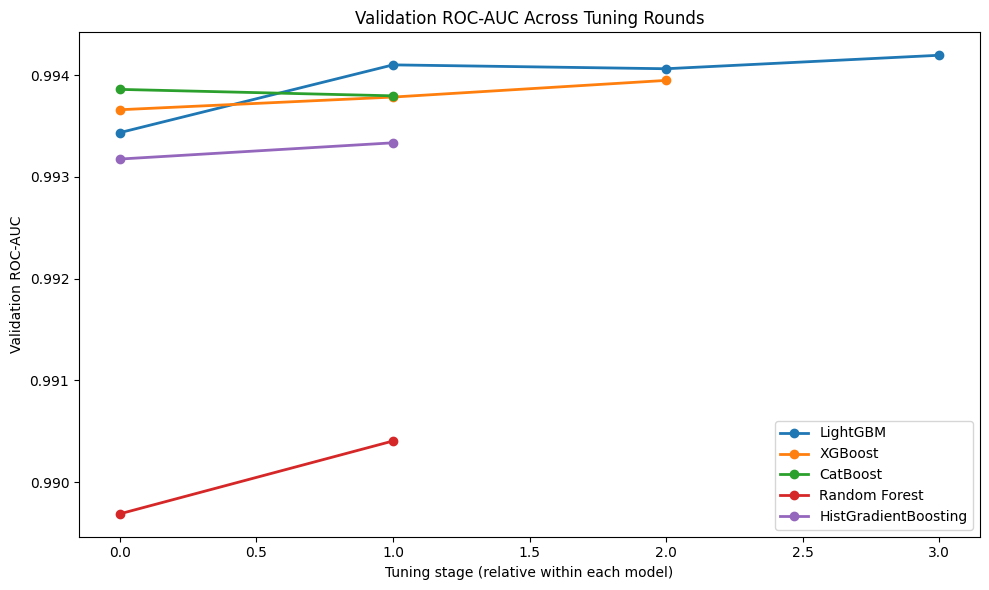

In [ ]:
# Purpose: Assemble the complete tuning progression from stored objects and visualize ROC-AUC across tuning stages.
# Build the tuning history entirely from stored results.
tuning_records = []

for model in ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest', 'HistGradientBoosting']:
    tuning_records.append({
        'Model': model,
        'Round': 'Baseline',
        'ROC_AUC': baseline_auc[model],
    })

for model, auc in round1_auc.items():
    method = {
        'LightGBM': 'Optuna',
        'XGBoost': 'Optuna',
        'CatBoost': 'Optuna',
        'Random Forest': 'RandomizedSearchCV',
        'HistGradientBoosting': 'RandomizedSearchCV',
    }[model]
    tuning_records.append({
        'Model': model,
        'Round': f'Round 1 — {method}',
        'ROC_AUC': auc,
    })

tuning_records.extend([
    {'Model': 'LightGBM', 'Round': 'Round 2 — Local GridSearchCV', 'ROC_AUC': lgb_r2_auc},
    {'Model': 'XGBoost', 'Round': 'Round 2 — Refined Optuna', 'ROC_AUC': study_xgb_r2.best_value},
    {'Model': 'LightGBM', 'Round': 'Round 3 — Manual verification', 'ROC_AUC': round3_auc},
])

progression = pd.DataFrame(tuning_records)
display(progression.style.format({'ROC_AUC': '{:.6f}'}))

fig, ax = plt.subplots(figsize=(10, 6))
for model, grp in progression.groupby('Model', sort=False):
    ax.plot(range(len(grp)), grp['ROC_AUC'], marker='o', label=model, linewidth=2)

ax.set_xlabel('Tuning stage (relative within each model)')
ax.set_ylabel('Validation ROC-AUC')
ax.set_title('Validation ROC-AUC Across Tuning Rounds')
ax.legend()
plt.tight_layout()
plt.show()

#### **Round 3 Observation**

The local-search tables show the effect of each manually tested LightGBM parameter around the stored Optuna solution.

The best learning-rate candidate improves validation ROC-AUC slightly, and the subsequent `num_leaves` test raises it again to approximately **0.994196**. The `min_child_samples` comparison then shows a plateau: values 49 and 82 produce the same displayed ROC-AUC to six decimal places.

**Interpretation:** the important finding is convergence rather than the final decimal place. Once local changes produce only negligible or indistinguishable gains, continuing to optimize the same validation subset increasingly risks fitting validation noise.

**Decision:** retain the best verified LightGBM configuration and stop further local tuning.


### **Summary of Hyperparameter Tuning**

The tuning process is deliberately model-specific:

- Random Forest is tuned through controls on tree count, tree complexity, leaf stability, and feature randomness.
- HistGradientBoosting is tuned around the learning-rate/number-of-iterations trade-off, tree complexity, leaf support, and L2 regularization.
- LightGBM and XGBoost receive broader joint optimization because their sampling, complexity, and regularization parameters interact strongly.
- CatBoost receives a narrower search focused on learning rate, depth, and L2 regularization.
- LightGBM receives a final manual verification only after automated tuning identifies a strong local region.

Most progression values are assembled from fitted search objects and stored results. One implementation detail should be noted: the first tuning-progression code cell inserts the previously executed LightGBM Hyperopt ROC-AUC as a literal value. That does not affect model selection, but it means the progression table is not entirely free of manually carried values.

Overall, tuning produces selective gains rather than universal improvement. Random Forest improves from 0.989688 to 0.990404 validation ROC-AUC, HistGradientBoosting improves from 0.993176 to 0.993335, XGBoost improves from 0.993661 to 0.993949 after Round 2, and LightGBM improves from 0.993436 to 0.994196 after manual verification. The Round 1 CatBoost search slightly underperforms its 0.993861 baseline, reaching 0.993797.

### **Next Step**
Refit the selected configurations and test whether combining their validation predictions improves on the strongest individual candidate.


## **10. Final Refit of the Tuned Models**

The five shortlisted candidates are refit using their selected configurations. Early stopping is monitored on the validation subset where the library/model supports it.

The purpose of this stage is to place the selected models on a common footing before ensemble construction. **No test-set performance is evaluated or used for selection at this stage.**


In [ ]:
# Purpose: Refit the selected configuration for each tuned model and calculate directly comparable validation ROC-AUC scores.
# LightGBM - Round 3 manual-search winner
final_lgb_params = dict(base_params); final_lgb_params.update({'n_estimators': 3000, 'random_state': 42, 'verbose': -1})
m_lgb = lgb.LGBMClassifier(**final_lgb_params)
m_lgb.fit(X_native.iloc[idx_train], y_train, eval_set=[(X_native.iloc[idx_val], y_val)],
          categorical_feature=nominal_cols, callbacks=[lgb.early_stopping(50, verbose=False)])

# XGBoost - Round 2 winner
final_xgb_params = dict(study_xgb_r2.best_params)
final_xgb_params.update({'n_estimators': 3000, 'enable_categorical': True, 'tree_method': 'hist',
                          'early_stopping_rounds': 50, 'eval_metric': 'auc', 'random_state': 42})
m_xgb = xgb.XGBClassifier(**final_xgb_params)
m_xgb.fit(X_native.iloc[idx_train], y_train, eval_set=[(X_native.iloc[idx_val], y_val)], verbose=False)

# CatBoost - Round 1 winner (unchanged since Round 1 was already near-optimal)
final_cb_params = dict(study_cb.best_params)
final_cb_params.update({'iterations': 3000, 'cat_features': cat_feature_idx, 'random_state': 42,
                         'eval_metric': 'AUC', 'early_stopping_rounds': 50, 'verbose': False})
m_cb = CatBoostClassifier(**final_cb_params)
m_cb.fit(X_native_str.iloc[idx_train], y_train, eval_set=(X_native_str.iloc[idx_val], y_val))

# Random Forest & HistGradientBoosting - Round 1 winners (no early stopping mechanism for RF, early stopping for HGB)
m_rf = RandomForestClassifier(**{k:(int(v) if k in ['n_estimators','max_depth','min_samples_split','min_samples_leaf'] else v)
                                   for k,v in rs_rf.best_params_.items()}, random_state=42, n_jobs=-1)
m_rf.fit(X_enc.iloc[idx_train], y_train)

m_hgb = HistGradientBoostingClassifier(**hgb_params_r1, random_state=42)
m_hgb.fit(X_enc.iloc[idx_train], y_train)

final_val_scores = {
    'LightGBM': roc_auc_score(y_val, m_lgb.predict_proba(X_native.iloc[idx_val])[:,1]),
    'XGBoost': roc_auc_score(y_val, m_xgb.predict_proba(X_native.iloc[idx_val])[:,1]),
    'CatBoost': roc_auc_score(y_val, m_cb.predict_proba(X_native_str.iloc[idx_val])[:,1]),
    'Random Forest': roc_auc_score(y_val, m_rf.predict_proba(X_enc.iloc[idx_val])[:,1]),
    'HistGradientBoosting': roc_auc_score(y_val, m_hgb.predict_proba(X_enc.iloc[idx_val])[:,1]),
}
for name, auc in sorted(final_val_scores.items(), key=lambda x: -x[1]):
    print(f"  {name}: val AUC = {auc:.6f}")

  LightGBM: val AUC = 0.994196
  CatBoost: val AUC = 0.994117
  XGBoost: val AUC = 0.993949
  HistGradientBoosting: val AUC = 0.993335
  Random Forest: val AUC = 0.990404


### **Summary of Final Model Refit**

The validation scores printed above are calculated directly from the refitted selected configurations. LightGBM remains the strongest individual validation candidate in the current run, with CatBoost and XGBoost close behind. HistGradientBoosting and Random Forest remain useful comparison models but do not match the leading boosting group.

### **Next Step**

Test whether prediction averaging or stacking can exploit complementary errors among the tuned candidates.


## **11. Ensemble Modeling**

Strong models can make different errors, so combining their predicted probabilities may improve generalization. Four ensemble strategies are compared on the validation set:

1. Simple average of the top three boosting models.
2. Validation-ROC-AUC-weighted average.
3. Simple average of all five tuned models.
4. Logistic-regression stacking meta-learner.

The ensemble is selected empirically rather than assuming that a more complex blending method must perform better.

In [ ]:
# Purpose: Generate validation probabilities and compare simple averaging, weighted averaging, all-model averaging, and stacking.
val_preds = {
    'LightGBM': m_lgb.predict_proba(X_native.iloc[idx_val])[:,1],
    'XGBoost': m_xgb.predict_proba(X_native.iloc[idx_val])[:,1],
    'CatBoost': m_cb.predict_proba(X_native_str.iloc[idx_val])[:,1],
    'RandomForest': m_rf.predict_proba(X_enc.iloc[idx_val])[:,1],
    'HistGradientBoosting': m_hgb.predict_proba(X_enc.iloc[idx_val])[:,1],
}

# Strategy 1: simple average of just the top-3 boosting models
avg3 = np.mean([val_preds['LightGBM'], val_preds['XGBoost'], val_preds['CatBoost']], axis=0)

# Strategy 2: simple average of all 5
avg5 = np.mean(list(val_preds.values()), axis=0)

# Strategy 3: weighted average, weighted by each model's own validation AUC
aucs = np.array([roc_auc_score(y_val, p) for p in val_preds.values()])
weights = (aucs - aucs.min()*0.999); weights = weights / weights.sum()
weighted = np.average(list(val_preds.values()), axis=0, weights=weights)

# Strategy 4: stacking - Logistic Regression meta-learner on the 5 models' predictions,
# fit and evaluated on two different halves of validation to keep it honest
from sklearn.linear_model import LogisticRegression
meta_X = np.column_stack(list(val_preds.values()))
idx_meta = np.arange(len(y_val))
idx_meta_tr, idx_meta_ho = train_test_split(idx_meta, test_size=0.5, random_state=42, stratify=y_val)
meta_lr = LogisticRegression().fit(meta_X[idx_meta_tr], y_val.iloc[idx_meta_tr])
stack_pred = meta_lr.predict_proba(meta_X[idx_meta_ho])[:,1]

ensemble_comparison = pd.DataFrame([
    {'Strategy': 'Simple Avg (Top-3 Boosting)', 'Val ROC AUC': roc_auc_score(y_val, avg3)},
    {'Strategy': 'Weighted Avg (by val AUC)', 'Val ROC AUC': roc_auc_score(y_val, weighted)},
    {'Strategy': 'Simple Avg (All 5)', 'Val ROC AUC': roc_auc_score(y_val, avg5)},
    {'Strategy': 'Stacking (LR meta-learner)', 'Val ROC AUC': roc_auc_score(y_val.iloc[idx_meta_ho], stack_pred)},
]).sort_values('Val ROC AUC', ascending=False)
ensemble_comparison

,Strategy,Val ROC AUC
0,Simple Avg (Top-3 Boosting),0.994326
1,Weighted Avg (by val AUC),0.994266
2,Simple Avg (All 5),0.994051
3,Stacking (LR meta-learner),0.993500


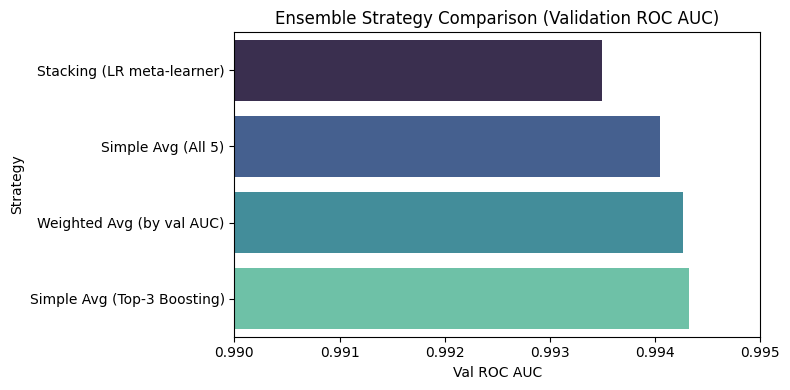

In [ ]:
# Purpose: Visualize validation ROC-AUC across the tested ensemble strategies.
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x='Val ROC AUC', y='Strategy', data=ensemble_comparison.sort_values('Val ROC AUC'), palette='mako')
ax.set_xlim(0.990, 0.995); ax.set_title('Ensemble Strategy Comparison (Validation ROC AUC)')
plt.tight_layout(); plt.show()

### **Ensemble Ranking and Observations**

The ensemble comparison table above is generated directly from the stored validation probabilities.

**Observation:** the simple average of the three leading boosting models achieves the strongest validation ROC-AUC in the current run. Adding the weaker Random Forest and HistGradientBoosting predictions does not help, and logistic-regression stacking does not improve on direct averaging.

**Decision:** select the simple average of tuned **LightGBM, XGBoost, and CatBoost** predicted probabilities as the final ensemble.


### **Summary of Ensemble Modeling**

The validation results show that the **simple average of LightGBM, XGBoost, and CatBoost** is the strongest ensemble strategy tested. Validation-ROC-AUC weighting, inclusion of the two weaker ensemble members, and logistic-regression stacking do not improve on the simple top-three average.

### **Next Step**

Freeze the ensemble choice and evaluate its performance against the reserved test labels.


## **12. Final Test Evaluation**

After feature, model, hyperparameter, and ensemble choices have been made from training/validation evidence, the selected candidates are scored on the test subset.

This is the first stage where test performance metrics are calculated and interpreted. The test labels `y_test` are not used for model selection before this section. However, some preprocessing and unsupervised feature-construction steps—such as `percentile capping`, `imputation/scaling` for feedback clustering, and `K-Means` fitting—were performed on the full merged dataset before the `train/validation/test split`. The final test results should therefore be interpreted as evaluation on labels reserved from supervised model selection, rather than as evaluation under a fully train-fitted preprocessing pipeline.

The evaluation reports Accuracy, F1-score, Precision, Recall, ROC-AUC, and the confusion matrix.


In [ ]:
# Purpose: Generate held-out test probabilities for each final model and build the final results table from computed metrics.
test_preds = {
    'LightGBM': m_lgb.predict_proba(X_native.iloc[idx_test])[:,1],
    'XGBoost': m_xgb.predict_proba(X_native.iloc[idx_test])[:,1],
    'CatBoost': m_cb.predict_proba(X_native_str.iloc[idx_test])[:,1],
    'RandomForest': m_rf.predict_proba(X_enc.iloc[idx_test])[:,1],
    'HistGradientBoosting': m_hgb.predict_proba(X_enc.iloc[idx_test])[:,1],
}
test_preds['Ensemble (Top-3 Boosting Avg)'] = np.mean(
    [test_preds['LightGBM'], test_preds['XGBoost'], test_preds['CatBoost']], axis=0)

final_results = []
for name, proba in test_preds.items():
    pred = (proba >= 0.5).astype(int)
    final_results.append({
        'Model': name, 'Accuracy': accuracy_score(y_test, pred), 'F1': f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred), 'Recall': recall_score(y_test, pred),
        'ROC_AUC': roc_auc_score(y_test, proba),
    })

final_df = pd.DataFrame(final_results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
final_df

,Model,Accuracy,F1,Precision,Recall,ROC_AUC
0,Ensemble (Top-3 Boosting Avg),0.961009,0.964105,0.970415,0.957876,0.994405
1,LightGBM,0.960090,0.963223,0.970488,0.956067,0.994320
2,CatBoost,0.959949,0.963189,0.967902,0.958522,0.994243
3,XGBoost,0.957901,0.961228,0.967903,0.954645,0.993824
4,HistGradientBoosting,0.956205,0.959609,0.967678,0.951673,0.993289
5,RandomForest,0.948577,0.952807,0.956030,0.949606,0.990613


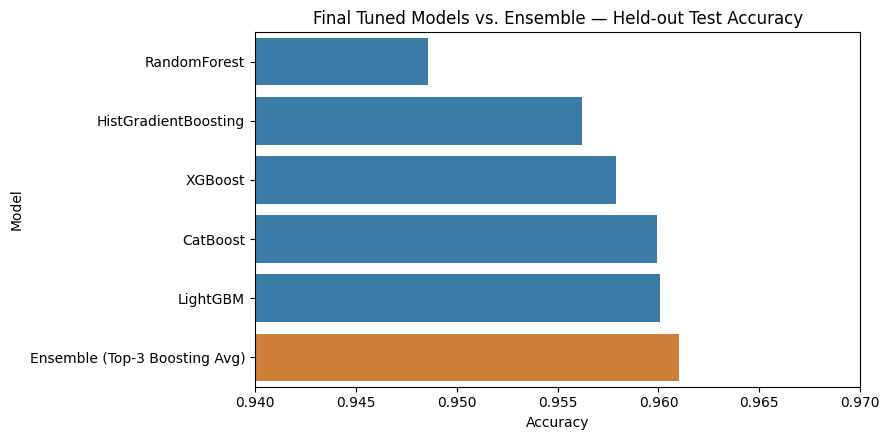

In [ ]:
# Purpose: Visualize final test accuracy across individual models and the selected ensemble.
fig, ax = plt.subplots(figsize=(9,4.5))
colors = ['#e67e22' if 'Ensemble' in m else '#2980b9' for m in final_df.sort_values('Accuracy')['Model']]
sns.barplot(x='Accuracy', y='Model', data=final_df.sort_values('Accuracy'), palette=colors)
ax.set_xlim(0.94, 0.97); ax.set_title('Final Tuned Models vs. Ensemble — Held-out Test Accuracy')
plt.tight_layout(); plt.show()

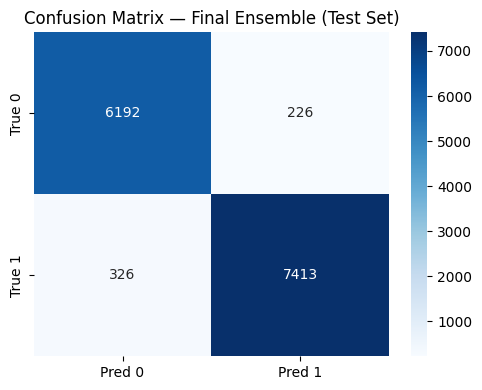

[[6192  226]
 [ 326 7413]]

Of 14157 test passengers, the ensemble misclassified 552 (3.9%).


In [ ]:
# Purpose: Compute and visualize the selected ensemble's confusion matrix and total error count.
cm = confusion_matrix(y_test, (test_preds['Ensemble (Top-3 Boosting Avg)'] >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'], ax=ax)
ax.set_title('Confusion Matrix — Final Ensemble (Test Set)')
plt.tight_layout(); plt.show()
print(cm)
print(f"\nOf {len(y_test)} test passengers, the ensemble misclassified {(cm[0,1]+cm[1,0])}"
      f" ({100*(cm[0,1]+cm[1,0])/len(y_test):.1f}%).")

### **Final Model Ranking and Observation**

The final ranking table is generated from `final_df`, which is calculated from predictions on the reserved test subset. The confusion matrix independently shows the selected ensemble's correct and incorrect classifications.

**Observation:** the top-three boosting ensemble ranks first among the evaluated final candidates on both test ROC-AUC and test accuracy in the stored execution. The individual LightGBM and CatBoost models are very close, so the ensemble improvement should be described as incremental rather than dramatic.

### **Comparison with `shinkansen_hackaton.ipynb`**

Because **`shinkansen_hackaton.ipynb`** uses a different evaluation workflow, its reported score is not a controlled benchmark against this test split. Any small numerical difference should therefore be treated cautiously. The stronger distinction is methodological: this notebook separates supervised model selection from final test evaluation and documents a wider set of alternatives, negative results, and diagnostics.


### **Summary of Final Evaluation**

The selected ensemble produces strong test-subset accuracy, F1, precision/recall balance, and ROC-AUC. All exact final metrics are stored in `final_df` and the confusion matrix rather than being retyped in markdown, which keeps this section consistent if the notebook is rerun.

### **Next Step**

Interpret the fitted models and engineered variables, then investigate the final ensemble's errors rather than stopping at aggregate performance metrics.


## **13. Feature Importance and Model Interpretation**

Feature importance from the final LightGBM model is used to examine which predictors contributed most strongly to the fitted decision process. This section also revisits the engineered features introduced earlier and checks whether their apparent standalone value translated into incremental predictive importance.


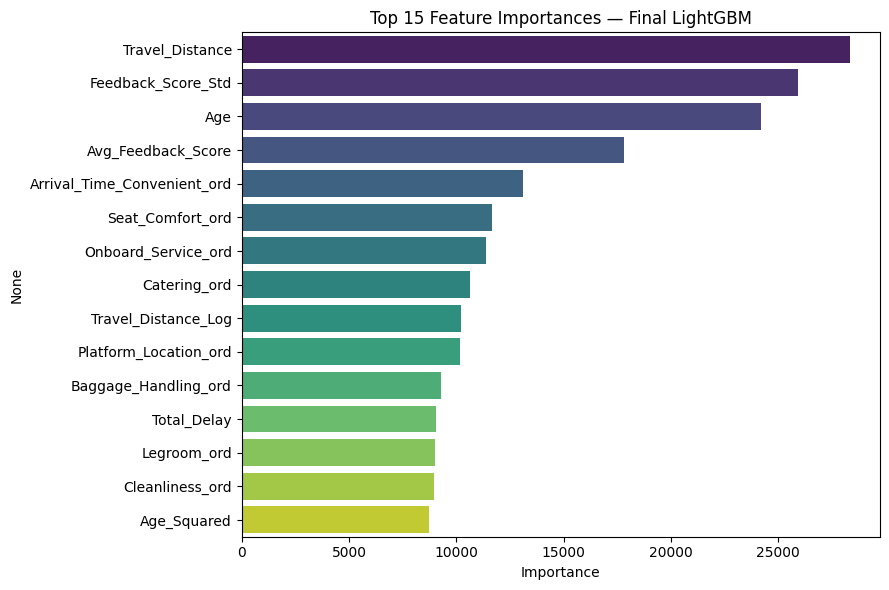

Travel_Distance                28323
Feedback_Score_Std             25938
Age                            24191
Avg_Feedback_Score             17820
Arrival_Time_Convenient_ord    13106
Seat_Comfort_ord               11686
Onboard_Service_ord            11384
Catering_ord                   10638
Travel_Distance_Log            10214
Platform_Location_ord          10157
Baggage_Handling_ord            9285
Total_Delay                     9049
Legroom_ord                     9019
Cleanliness_ord                 8975
Age_Squared                     8726
CheckIn_Service_ord             8494
Ease_of_Online_Booking_ord      8062
Online_Support_ord              7908
Delay_Ratio                     7718
Arrival_Delay_in_Mins           7707
Onboard_Entertainment_ord       7644
Departure_Delay_in_Mins         7206
Type_Travel                     6492
Online_Boarding_ord             5835
Onboard_Wifi_Service_ord        5779
Customer_Type                   4227
Travel_Class                    4161
G

In [ ]:
# Purpose: Extract and visualize LightGBM feature importances for global model interpretation.
fi = pd.Series(m_lgb.feature_importances_, index=X_native.columns).sort_values(ascending=False)
top15 = fi.head(15)
fig, ax = plt.subplots(figsize=(9,6))
sns.barplot(x=top15.values, y=top15.index, palette='viridis')
ax.set_title('Top 15 Feature Importances — Final LightGBM'); ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()
print(fi.round(0))

### **Feature-Importance Observations**

The LightGBM importance ranking above shows that several original and engineered variables contribute to the fitted model.

- `Feedback_Score_Std` appears among the most important features, showing that within-passenger variation across service ratings is used strongly by the model.
- `Feedback_Cluster` appears near the bottom despite its strong standalone target separation, suggesting that much of its information is redundant once the underlying feedback variables are available.
- The missingness indicators also appear near the bottom, consistent with their weak univariate target relationship.
- Original variables such as `Travel_Distance` and `Age`, aggregate feedback information, and multiple ordinal service ratings remain prominent.

**Important interpretation:** feature importance shows how strongly the fitted LightGBM uses a variable; it does **not** prove that adding that variable improves out-of-sample performance or that the variable is causal. This result should therefore be read together with the earlier ablation test, which did not show an overall validation improvement for the complete engineered representation.


### **Summary of Model Interpretation**

The importance analysis shows that the final LightGBM uses a mixture of original and engineered information. Some engineered variables—especially feedback-score variation—receive substantial model importance, while clustering and missingness indicators receive little incremental use.

This does **not** overturn the controlled feature-engineering ablation: the expanded engineered representation did not outperform the original-variable representation in that benchmark. Feature importance and predictive ablation answer different questions and are reported separately.

### **Next Step**

Move from global feature use to row-level diagnostics: examine class-specific errors, threshold behavior, predicted-probability overlap, and difficult passenger segments.


## **14. Model Diagnostics and Error Analysis**

### **Question**
Where does the final classifier make mistakes, how confident is it when it is wrong, and do false positives and false negatives show different passenger characteristics?

### **Why This Matters**
Accuracy and ROC-AUC summarize overall performance but do not show *how* the model fails. A complete classification analysis should inspect class-specific errors, threshold behavior, probability overlap, and observations near the decision boundary.

### **Method**
The diagnostic section reuses the exact final ensemble probabilities created in Section 12:

`test_preds['Ensemble (Top-3 Boosting Avg)']`

At the default threshold of 0.50, the code reports:

1. the final metric table;
2. the confusion matrix and classification report;
3. ROC and precision–recall curves;
4. class-conditioned probability distributions;
5. false-positive and false-negative counts/rates;
6. numerical error profiles;
7. categorical error profiles;
8. the observations closest to the 0.50 decision boundary.

The interpretation follows the executed outputs below rather than reconstructing a different prediction variable.


,Model,Accuracy,ROC_AUC,Precision,Recall,F1
0,Ensemble (Top-3 Boosting Avg),0.96101,0.994405,0.97041,0.95788,0.96410


,Predicted 0,Predicted 1
Actual 0 — Negative experience,6192,226
Actual 1 — Positive experience,326,7413


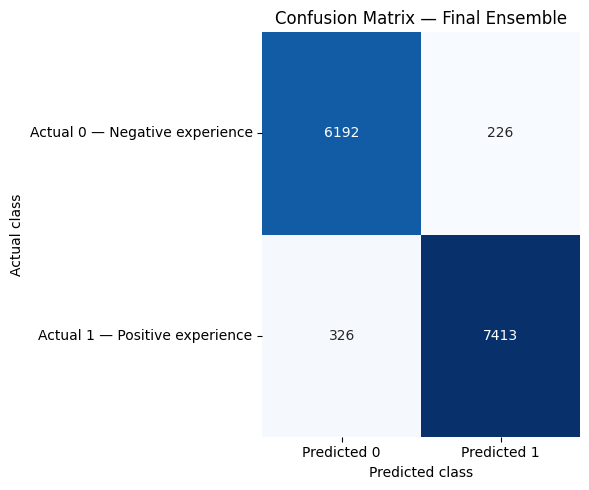

,precision,recall,f1-score,support
Negative experience,0.9500,0.9648,0.9573,6418.000
Positive experience,0.9704,0.9579,0.9641,7739.000
accuracy,0.9610,0.9610,0.9610,0.961
macro avg,0.9602,0.9613,0.9607,14157.000
weighted avg,0.9612,0.9610,0.9610,14157.000


In [ ]:
# Purpose: Compute final ensemble diagnostics, including metrics, confusion matrix, and the full classification report.
# Use the exact final ensemble probabilities stored in Section 12.
final_model_name = 'Ensemble (Top-3 Boosting Avg)'
final_prob = np.asarray(test_preds[final_model_name])
final_pred = (final_prob >= 0.50).astype(int)
y_test_array = y_test.to_numpy()

# Core classification metrics
diagnostic_metrics = pd.DataFrame([
    {
        'Model': final_model_name,
        'Accuracy': accuracy_score(y_test, final_pred),
        'ROC_AUC': roc_auc_score(y_test, final_prob),
        'Precision': precision_score(y_test, final_pred),
        'Recall': recall_score(y_test, final_pred),
        'F1': f1_score(y_test, final_pred),
    }
])
display(diagnostic_metrics.style.format({
    'Accuracy': '{:.5f}',
    'ROC_AUC': '{:.6f}',
    'Precision': '{:.5f}',
    'Recall': '{:.5f}',
    'F1': '{:.5f}',
}))

# Confusion matrix: table + heatmap
cm = confusion_matrix(y_test, final_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual 0 — Negative experience', 'Actual 1 — Positive experience'],
    columns=['Predicted 0', 'Predicted 1'],
)
display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix — Final Ensemble')
plt.ylabel('Actual class')
plt.xlabel('Predicted class')
plt.tight_layout()
plt.show()

# Classification report
report_df = pd.DataFrame(
    classification_report(
        y_test,
        final_pred,
        target_names=['Negative experience', 'Positive experience'],
        output_dict=True,
        zero_division=0,
    )
).T
display(report_df.round(4))

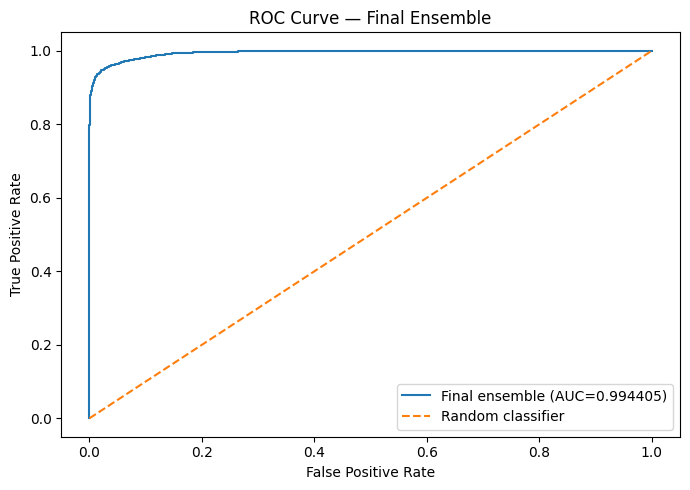

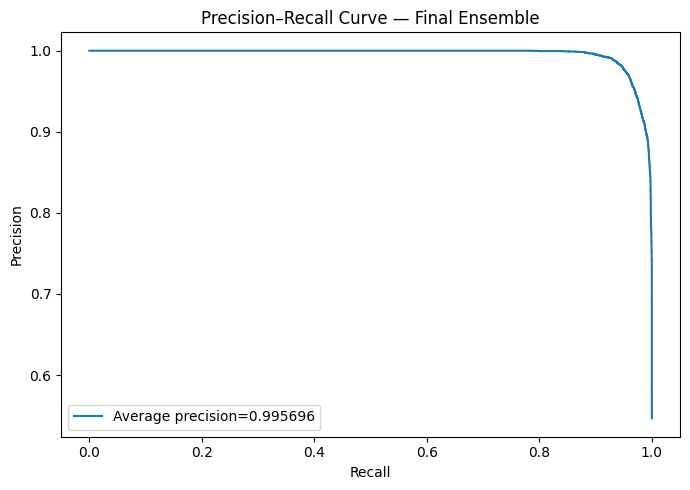

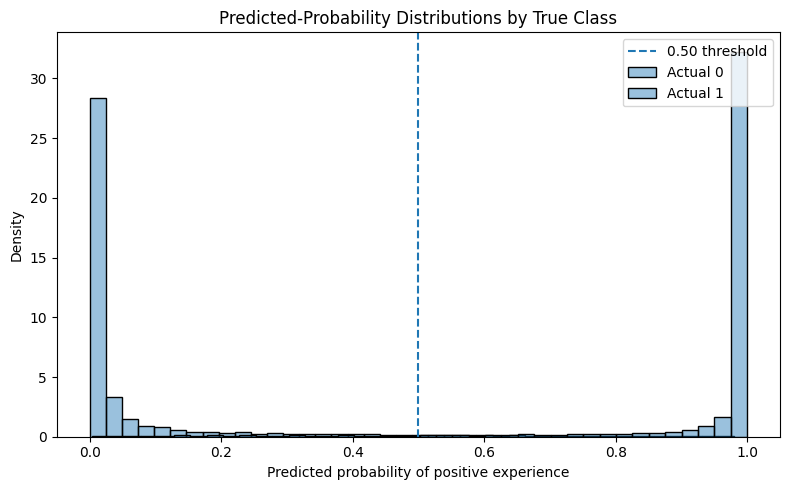

,Count,Percent of test set
Outcome,,
Correct,13605,96.10%
False Negative,326,2.30%
False Positive,226,1.60%


Age                      Travel_Distance                   \
                count   mean median    std           count     mean  median   
error_type                                                                    
Correct         13600  39.53   40.0  15.00           13605  1959.79  1936.0   
False Negative    325  38.67   38.0  15.72             326  1899.50  1853.5   
False Positive    226  37.33   37.5  15.87             226  1868.85  1833.0   

                       Departure_Delay_in_Mins                       \
                   std                   count   mean median    std   
error_type                                                            
Correct         962.47                   13596  11.50    0.0  21.06   
False Negative  869.50                     326   8.13    0.0  18.01   
False Positive  937.20                     226   9.26    0.0  18.81   

               Arrival_Delay_in_Mins                      Avg_Feedback_Score  \
                               count   mean median    std              count   
error_type                                                                     
Correct                        13550  11.67    0.0  21.23              13605   
False Negative                   325   8.47    0.0  18.59                326   
False Positive                   224   8.94    0.0  18.82                226   

                                  Feedback_Score_Std                     
                mean median   std              count  mean median   std  
error_type                                                               
Correct         3.31   3.36  0.69              13605  1.15   1.14  0.36  
False Negative  3.20   3.21  0.52                326  1.12   1.10  0.30  
False Positive  3.53   3.57  0.48                226  1.08   1.09  0.33


Error profile by Customer_Type — column percentages


error_type,Correct,False Negative,False Positive
Customer_Type,,,
Disloyal Customer,17.84,22.84,29.5
Loyal Customer,82.16,77.16,70.5



Error profile by Type_Travel — column percentages


...


Error profile by Travel_Class — column percentages


error_type,Correct,False Negative,False Positive
Travel_Class,,,
Business,48.83,22.39,32.3
Eco,51.17,77.61,67.7



Error profile by Seat_Class — column percentages


error_type,Correct,False Negative,False Positive
Seat_Class,,,
Green Car,49.98,50.61,46.9
Ordinary,50.02,49.39,53.1


,actual,predicted,prob_positive,error_type,Age,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Customer_Type,Type_Travel,Travel_Class
1327,1,0,0.499402,False Negative,26.0,2896.0,0.0,0.0,Disloyal Customer,Business Travel,Business
21774,0,0,0.499356,Correct,46.0,1851.0,0.0,0.0,Loyal Customer,Business Travel,Eco
69222,1,1,0.500820,Correct,35.0,3799.0,0.0,12.0,NaN,Business Travel,Business
50767,1,0,0.498888,False Negative,26.0,2193.0,2.0,0.0,Loyal Customer,Business Travel,Business
74052,1,0,0.498676,False Negative,65.0,217.0,0.0,0.0,Loyal Customer,Personal Travel,Eco
1419,0,0,0.498551,Correct,18.0,1453.0,14.0,2.0,Loyal Customer,Personal Travel,Eco
68353,0,1,0.501794,False Positive,40.0,1623.0,0.0,0.0,Loyal Customer,Personal Travel,Eco
28286,0,1,0.502123,False Positive,28.0,1675.0,2.0,1.0,Loyal Customer,Business Travel,Eco
31454,1,1,0.502333,Correct,47.0,1279.0,0.0,0.0,Loyal Customer,Business Travel,Eco
62701,0,0,0.497407,Correct,41.0,1990.0,1.0,6.0,NaN,Business Travel,Eco


In [ ]:
# Purpose: Analyze threshold behavior, probability separation, false-positive/false-negative profiles, and observations nearest the decision boundary.
# Threshold-independent diagnostic curves
fpr, tpr, roc_thresholds = roc_curve(y_test, final_prob)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, final_prob)
avg_precision = average_precision_score(y_test, final_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Final ensemble (AUC={roc_auc_score(y_test, final_prob):.6f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Ensemble')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, label=f"Average precision={avg_precision:.6f}")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve — Final Ensemble')
plt.legend()
plt.tight_layout()
plt.show()

# Probability distributions by true class
plt.figure(figsize=(8, 5))
sns.histplot(final_prob[y_test_array == 0], bins=40, stat='density', alpha=.45, label='Actual 0', color='C0')
sns.histplot(final_prob[y_test_array == 1], bins=40, stat='density', alpha=.45, label='Actual 1', color='C0')
plt.axvline(0.50, linestyle='--', label='0.50 threshold')
plt.xlabel('Predicted probability of positive experience')
plt.ylabel('Density')
plt.title('Predicted-Probability Distributions by True Class')
plt.legend()
plt.tight_layout()
plt.show()

# Build row-level error frame
error_frame = df.iloc[idx_test].copy()
error_frame['actual'] = y_test_array
error_frame['predicted'] = final_pred
error_frame['prob_positive'] = final_prob
error_frame['confidence'] = np.maximum(final_prob, 1 - final_prob)
error_frame['distance_from_threshold'] = np.abs(final_prob - 0.50)
error_frame['error_type'] = np.select(
    [
        (error_frame['actual'] == 0) & (error_frame['predicted'] == 1),
        (error_frame['actual'] == 1) & (error_frame['predicted'] == 0),
    ],
    ['False Positive', 'False Negative'],
    default='Correct',
)

error_counts = error_frame['error_type'].value_counts().rename_axis('Outcome').to_frame('Count')
error_counts['Percent of test set'] = 100 * error_counts['Count'] / len(error_frame)
display(error_counts.style.format({'Percent of test set': '{:.2f}%'}))

numeric_error_cols = [
    c for c in [
        'Age',
        'Travel_Distance',
        'Departure_Delay_in_Mins',
        'Arrival_Delay_in_Mins',
        'Avg_Feedback_Score',
        'Feedback_Score_Std',
    ]
    if c in error_frame.columns
]
if numeric_error_cols:
    error_numeric_profile = (
        error_frame.groupby('error_type')[numeric_error_cols]
        .agg(['count', 'mean', 'median', 'std'])
        .round(2)
    )
    display(error_numeric_profile)

# Categorical profiles
for col in [c for c in ['Customer_Type', 'Type_Travel', 'Travel_Class', 'Seat_Class'] if c in error_frame.columns]:
    print(f"\nError profile by {col} — column percentages")
    profile = pd.crosstab(
        error_frame[col],
        error_frame['error_type'],
        normalize='columns',
    ) * 100
    display(profile.round(2))

# Most uncertain cases: observations closest to the 0.50 decision boundary.
uncertain_cols = [
    c for c in [
        'actual', 'predicted', 'prob_positive', 'error_type',
        'Age', 'Travel_Distance',
        'Departure_Delay_in_Mins', 'Arrival_Delay_in_Mins',
        'Customer_Type', 'Type_Travel', 'Travel_Class',
    ]
    if c in error_frame.columns
]
most_uncertain = (
    error_frame.sort_values('distance_from_threshold')
    .head(20)[uncertain_cols]
)
display(most_uncertain)

### **Observation and Interpretation — Errors**

The stored diagnostic outputs show strong overall discrimination but also reveal where the remaining mistakes occur.

**Headline test diagnostics**
- Accuracy: **0.96101**
- ROC-AUC: **0.994405**
- Precision for the positive class: **0.97041**
- Recall for the positive class: **0.95788**
- F1-score for the positive class: **0.96410**
- Correct classifications: **13,605 of 14,157 (96.10%)**
- False negatives: **326 (2.30% of the test set)**
- False positives: **226 (1.60% of the test set)**

The negative class has 0.9500 precision and 0.9648 recall, while the positive class has 0.9704 precision and 0.9579 recall. The two classes are therefore handled at similarly strong levels, with somewhat more false negatives than false positives in absolute count.

**Probability behavior:** the predicted-probability distributions are strongly separated overall but overlap around the 0.50 boundary. The most uncertain examples lie very close to that threshold, as expected.

**Error profiles:** the categorical profiles reveal larger differences than `Seat_Class` alone suggests. For example, Eco passengers represent **77.61% of false negatives** and **67.70% of false positives**, compared with 51.17% of correct cases. Personal Travel also represents **50.51% of false negatives**, versus 30.63% of correct cases. These are descriptive error concentrations, not evidence that class or travel type causes the mistakes; group prevalence and interactions with other features must also be considered.

`Seat_Class` itself is comparatively balanced across error types: Green Car accounts for 50.61% of false negatives and 46.90% of false positives.

### **Decision — Threshold Optimization**

The default **0.50** threshold is retained for the headline classification metrics because no business cost function specifies that false positives and false negatives should carry different operational penalties.

Threshold optimization is therefore **not adopted as the primary result**. A different threshold could trade precision against recall, but selecting one solely to improve a metric on this dataset would impose an arbitrary objective. ROC-AUC remains the principal threshold-independent ranking metric, while the confusion matrix and class-specific precision/recall describe behavior at 0.50.

### **Next Step**
Document plausible methods that were considered but not selected and the evidence behind those decisions.


## **15. Methods Considered but Not Selected**

A comprehensive data-science project should show not only what was done, but also why plausible alternatives were rejected.

| Method | When It Can Be Useful | Decision in This Project | Reason |
|---|---|---|---|
| Drop all incomplete rows | Very low, plausibly random missingness | **Not selected** | Would discard useful passenger records and could bias the sample. |
| Universal mean/mode imputation | Simple pipelines requiring complete data | **Not selected as a universal rule** | Ignores model-specific missing-value handling and can distort distributions. |
| SMOTE / oversampling | Strong target imbalance | **Not selected** | Target classes are sufficiently represented; synthetic balancing is unnecessary. |
| Random undersampling | Large majority-class surplus | **Not selected** | Would discard valid observations. |
| IQR/Z-score outlier deletion | Clear erroneous extremes under suitable distributions | **Not selected** | Extreme delays/distances may be legitimate; deletion could remove important cases. |
| Arbitrary integer encoding of nominal categories | Rarely appropriate for unordered labels | **Not selected** | Introduces artificial numeric order and distance. |
| PCA | High-dimensional correlated numeric feature spaces where compression is valuable | **Not selected** | Dimensionality is manageable and interpretability/native categorical structure are valuable. |
| Full polynomial expansion | Low-dimensional smooth relationships | **Not selected** | Would create many artificial interactions; boosting models can learn nonlinear interactions directly. |
| Target encoding as final representation | High-cardinality categorical variables | **Tested, not selected** | Out-of-fold target encoding did not improve materially over the stronger native/encoded representations. |
| K-Means cluster as dominant feature | Latent behavioral groups add unique signal | **Tested, limited incremental value** | Cluster separation was interesting descriptively, but the underlying feedback features already contained most of the predictive information. |
| Complex stacking as final ensemble | Base models make complementary errors | **Tested, not selected** | A simpler average of the strongest boosting models performed better or equivalently. |
| Threshold optimization | Different business costs for FP vs FN | **Deferred** | No business cost matrix or operating constraint was supplied. |

### **Reference Principle**
A technique is not evidence of sophistication simply because it is applied. The stronger practice is to understand when a method is appropriate, test it when justified, and reject it transparently when the data do not support its use.

## **16. Lessons for Future Classification Projects**

This notebook is intended to serve as a reusable reference for future supervised-classification work. The following workflow generalizes beyond the Shinkansen dataset:

1. **Validate the data structure before cleaning.** Verify keys, row counts, duplicates, types, missingness, and category levels.

2. **Use EDA to generate evidence, not decoration.** A statement about skewness, outliers, imbalance, or association should be supported by statistics and/or visualization.

3. **Separate observation from decision.** Seeing an outlier does not automatically justify deleting it; seeing missingness does not automatically justify mean imputation.

4. **Respect variable semantics.** Nominal categories, ordinal ratings, and continuous measurements require different treatment.

5. **Prevent leakage structurally.** Ideally, split the data before fitting any data-derived transformation, use the validation set for model-development decisions, and reserve the final test labels and test performance for evaluation only after the workflow is frozen.

6. **Establish baselines before tuning.** Compare simple and complex model families before investing computational effort in hyperparameter optimization.

7. **Use multiple metrics.** Accuracy alone can hide important classification behavior; ROC-AUC, F1, precision, recall, and confusion matrices provide complementary views.

8. **Test feature-engineering hypotheses.** Engineered features should earn their place through validation performance, interpretability, or both.

9. **Report negative results.** Knowing that a plausible method did not help is reusable knowledge.

10. **Prefer the simplest method that performs equivalently.** Complexity should buy measurable value.

11. **Inspect errors after selecting the model.** Aggregate scores do not reveal which observations remain difficult.

12. **Distinguish prediction from causation.** Feature importance and correlation identify predictive associations, not causal effects.

The key reusable habit is the project's recurring structure:

> **Question → Why it matters → Method → Code → Output/Visualization → Observation → Interpretation → Decision → Summary → Next Step**

## **17. Project Conclusion**

### **Executive Findings**

This project builds a broad classification workflow for predicting Shinkansen passenger experience, from independent source inspection and merge validation through EDA, preprocessing decisions, feature experimentation, model comparison, model-specific hyperparameter tuning, ensemble selection, reserved-test evaluation, feature interpretation, and error analysis.

The final selected predictor is a simple probability average of LightGBM, XGBoost, and CatBoost. In the stored execution, it achieves **0.96101 accuracy** and **0.994405 ROC-AUC** on the reserved test subset.

### **Answers to the Project Objectives**

1. **Which model families perform best?**  
   The completed baseline comparison evaluates **15 models** across **8 model families**. Specialized gradient-boosting models dominate the ranking: CatBoost is the strongest untuned baseline with **0.993861** validation **ROC-AUC**, followed by XGBoost (**0.993661**) and LightGBM (**0.993436**). HistGradientBoosting ranks fourth at **0.993176**, making it the strongest scikit-learn boosting baseline. After tuning, the selected LightGBM configuration becomes the strongest individual validation candidate at **0.994196**.

2. **Does hyperparameter tuning materially improve performance?**  
   **Selectively, and generally by small margins.** Random Forest improves from **0.989688** to **0.990404** validation ROC-AUC, HistGradientBoosting from **0.993176** to **0.993335**, XGBoost from **0.993661** to **0.993949** after Round 2, and LightGBM from **0.993436** to **0.994196** after its final manual verification. The Round 1 CatBoost search does not improve on its **0.993861** baseline. The later LightGBM checks show diminishing returns, supporting a stopping point rather than indefinite optimization of the same validation subset.

3. **Does feature engineering add value?**  
   **Not as a blanket claim.** The controlled LightGBM ablation shows that the full engineered representation underperforms the simpler original-variable representation in validation ROC-AUC. Nevertheless, individual engineered variables—especially `Feedback_Score_Std`—receive substantial importance in the final LightGBM. Feature usefulness and whole-representation improvement are therefore distinct questions.

4. **Does target encoding improve the representation?**  
   Only negligibly in the stored comparison. Leakage-controlled K-fold target encoding improves validation ROC-AUC by approximately 0.000059 over native categorical handling, which is not enough to justify the added complexity here.

5. **Does ensembling improve the strongest individual model?**  
   Yes, incrementally. The simple average of LightGBM, XGBoost, and CatBoost produces the strongest validation ROC-AUC among the tested ensemble strategies and also ranks first among the final test candidates.

6. **Where does the final model fail?**  
   The final ensemble produces 326 false negatives and 226 false positives on 14,157 test observations. Error profiles show concentration in some travel segments—particularly Eco and Personal Travel among false negatives—while the probability plots show that many difficult cases sit near the 0.50 decision boundary.

### **Comparison with `shinkansen_hackaton.ipynb`**

**`shinkansen_hackaton.ipynb`** is treated as the earlier reference implementation of the Shinkansen passenger-experience project. It follows a more compact workflow centered on data cleaning, exploratory analysis, preprocessing, model comparison, and extensive model tuning. This notebook takes a broader and more explicitly auditable approach by inspecting and validating each source before merging, rechecking the merged dataset, performing deeper EDA and mixed-type association analysis, documenting missing-value and outlier decisions, testing representation hypotheses, comparing more model families, applying model-specific tuning strategies, evaluating ensembles, and adding feature interpretation and error analysis.

Because the evaluation designs differ, small numerical differences between **`shinkansen_hackaton.ipynb`** and this notebook should not be presented as a controlled performance victory. The principal advance is the breadth, traceability, and auditability of the workflow.

### **What Did Not Provide Clear Incremental Benefit**

- missingness indicators for `Customer_Type` and `Type_Travel`;
- K-fold target encoding, given its negligible gain over native categorical handling;
- the K-Means feedback-cluster feature as an incremental predictor once underlying feedback variables are available;
- the complete engineered representation in the controlled LightGBM ablation;
- more complex ensemble strategies compared with the simple top-three average;
- continued fine-grained LightGBM tuning after validation performance largely converged.

### **Limitations**

- Percentile capping and unsupervised feature construction are developed before the train/validation/test split. Test labels are not used for supervised model selection, but a stricter production workflow would fit every data-derived transformation on training data only.
- Test-row target-encoded features are prepared using mappings learned only from training rows before final evaluation. This does not use test labels, but it means the test feature matrix is not literally untouched.
- The SVM baseline uses a stratified 10,000-row training subsample because repeated full-scale fitting is much more expensive; its result is therefore not perfectly comparable with models trained on the full training subset.
- Hyperparameter-search budgets are finite, so wider searches could produce small changes.
- LightGBM split/gain-style feature importance and correlation describe predictive association, not causal effects.
- Threshold optimization is not adopted because no business cost matrix defines the relative cost of false positives and false negatives.
- The analysis is limited to the variables supplied in the dataset; external operational or contextual variables may contain additional predictive information.

### **Potential Next Steps**

A stricter production version should move the split immediately after merge validation and fit capping, clustering, imputation, encoding, and any other data-derived transformations on training data only. Additional work could examine probability calibration, business-specific threshold selection, permutation importance or SHAP explanations, feature-importance stability across folds, and external or temporal validation where suitable data are available.

### **Final Conclusion**

The project demonstrates that strong classification performance is only one component of a defensible machine-learning workflow. Source validation, appropriate EDA, explicit preprocessing decisions, leakage awareness and control, broad baselines, model-specific tuning, transparent negative results, reserved-test evaluation, and error analysis are equally important.

The final ensemble is highly accurate in the stored execution, but the notebook's greater value is methodological: it records what was tested, what did not help, where limitations remain, and how the final decision was reached.
